# INF2008 Group Project
Lab: P3
Group Number: 08

| Name | Student ID |
| :--- | :--- |
| **Thaw Zin Lin** | 2500651 |
| **Chun Jin Xiang** | 2500652 |
| **Lim Xin Chian** | 2500671 |
| **Justin Tan Jun An** | 2500966 |
| **Goh Jun Yong** | 2504002 |

Project Title: Hotel Booking Cancellation Risk Prediction


# Table of Contents
* 1. Business Understanding
* 2. About the Dataset
* 3. Importing Relevant Libraries
* 4. Loading the Dataset
* 5. Exploratory Data Analysis (EDA)
    * 5.1 Descriptive Statistics and Sanity Checks
        * 5.1.1 Analysis
        * 5.1.2 Summary of Changes to Dataset Before Graphical Analysis
    * 5.2 Graphical Analysis
        * 5.2.1 Dataset Composition and Target Balance
        * 5.2.2 Univariate Analysis
        * 5.2.3 Bivariate Analysis
            * 5.2.3.1 Formal Statistical Testing for Bivariate Findings
            * 5.2.3.2 Statistical Test Findings
            * 5.2.3.3 Note on Feature Selection
        * 5.2.4 Temporal and ADR Trends
        * 5.2.5 Multivariate Analysis
* 6. Data Preprocessing
    * 6.1 Data Cleaning
        * 6.1.1 Handling Missing Values
        * 6.1.2 Correcting Structural Errors
    * 6.2 Data Transformation
        * 6.2.1 Feature Engineering
        * 6.2.2 Dropping Unnecessary Columns
        * 6.2.3 Feature Scaling and Encoding Using Transformers
* 7. Post-Data Preprocessing EDA
    * 7.1 Scaling Effectiveness of Lead Time and ADR
    * 7.2 Analysis of Engineered Features and Historical Signals
    * 7.3 Dimensionality Verification After One-Hot Encoding
* 8. Justifying Model Selection with Feature Correlation and Principal Component Analysis (PCA)
    * 8.1 Feature Correlation Bar Chart
    * 8.2 PCA Scatter Plot
    * 8.3 Model Selection Strategy
    * 8.4 Evaluation Hierarchy
* 9. Model Evaluation Strategy
* 10. Data Preparation with Train, Test, and Validation Split
* 11. Model Development
* 12. Baseline Validation Snapshot Metrics
* 13. Baseline Ordinary-Split Snapshot (Validation Set)
    * 13.1 Baseline Snapshot Findings
* 14. Preparing the Leak-Free Imbalance-Handling Workflow
    * 14.1 Starting Point: 50/50 Class Balance
    * 14.2 Baseline Handoff into Advanced Modelling
* 15. Transition to Advanced Modelling
* 16. Transition Summary
* 17. Advanced Modelling, Evaluation, and Business Translation
    * 17.1 Compare 2–3 Distinct Algorithmic Families
        * 17.1.1 Findings
    * 17.2 Hyperparameter Tuning
    * 17.3 Post-Tuning k-Fold Cross-Validation and Champion Selection
        * 17.3.1 Champion Model Handoff
    * 17.4 Validation-Stage Ensemble Comparison
        * 17.4.1 Findings After the Threshold Consistency Fix
        * 17.4.2 Verdict
    * 17.5 Model Ablation
        * 17.5.1 Findings
* 18. Final Candidate Lock and Refit on Train + Validation
* 19. Final Test Evaluation
    * 19.1 Important Sanity Check
    * 19.2 Operational Justification for the Locked Threshold
    * 19.3 Findings
* 20. High-Confidence Error Analysis (Validation Split)
    * 20.1 Findings from the Current Run
    * 20.2 Interpretation
* 21. Business Decision Translation
    * 21.1 Risk Band Definition
    * 21.2 Why this follows Directly from Business Understanding
    * 21.3 Findings from the Current Run
* 22. Final Integrated Summary

<a id="sec-1"></a>
# 1. Business Understanding

### Problem Statement
Hotel revenue management currently lacks a reliable method to quantify the risk of booking cancellations at the moment of reservation. This gap forces management to rely on aggressive overbooking strategies or broad historical averages. Without a granular, booking-level risk score, the hotel cannot make informed decisions on inventory allocation, leading to suboptimal occupancy and increased operational friction. Cancellation-risk handling is largely manual or rule-based, which is inconsistent and often too late to prevent unsold room-nights or overbooking errors. We generate a cancellation risk score at the point of booking. This score is used as a decision-support signal to (1) prioritise pre-arrival confirmations and reminders for higher-risk bookings, and (2) inform revenue-management planning by estimating likely net arrivals, supporting safer inventory protection and overbooking decisions.

### Business Objectives
Our objective is to predict cancellation risk at the moment of booking. We use `is_cancelled` as the target variable ($1 = \text{cancelled}$, $0 = \text{not cancelled}$) to produce a risk score that supports proactive management in three key areas:

* **Financial Performance:** minimise revenue loss from unsold room-nights and reduce "walking" costs (reimbursements/transportation) when overbooking exceeds actual arrivals.
* **Operational Efficiency:** enable front-desk and housekeeping teams to better anticipate guest volume, improving labour scheduling and room turnover.
* **Customer Experience:** protect the hotel’s reputation by reducing guest displacement so confirmed bookings remain honoured.

### Success Criteria
The model is assessed against two costly error types:

| Item | Definition | Business Impact |
| :--- | :--- | :--- |
| **False Negative (FN)** | Predicted 0, Actual 1 | **Unsold room-nights:** late cancellations are missed and revenue cannot be recovered in time. |
| **False Positive (FP)** | Predicted 1, Actual 0 | **Operational false alarms:** unnecessary intervention raises workload and may annoy genuine arrivals. |

From baseline modelling onward, **F2-score** is the main optimisation metric because Recall is operationally more important than Precision in this hotel context. Precision remains a guardrail so the hotel does not flood staff with unnecessary follow-up actions.

### Deployment Gates
A model is considered **ready for deployment** only if it satisfies all three thresholds on the held-out **test set**:

| Metric | Threshold | Why it matters |
| :--- | :---: | :--- |
| **Recall** | **>= 0.75** | Catch enough real cancellations to protect revenue. |
| **F2-score** | **>= 0.64** | Optimise the Recall-heavy trade-off without ignoring Precision. |
| **Precision** | **>= 0.50** | Keep false alarms at a manageable operational level. |

Final evaluation must conclude with one of three verdicts:

* **Ready for deployment:** all three thresholds are met on the held-out test set.
* **Conditionally ready:** Recall and F2 are met but Precision falls slightly short, meaning the model may still be useful if staff can absorb extra follow-up volume.
* **Not ready:** the model fails the Recall gate or fails multiple thresholds, so it should remain a prototype until further refinement.


<a id="sec-2"></a>
# 2. About the Dataset

### Overview and Source
This dataset contains real-world booking information originally extracted from the Property Management System (PMS) databases of two hotels in Portugal.
* **Source:** [Kaggle - Hotel Booking Demand](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand)
* **Scope:** 119,390 total bookings arriving between **1 July 2015 and 31 August 2017**.
* **Locations:**
    * **H1 (Resort Hotel):** Algarve region (southern Portugal) - 40,060 bookings.
    * **H2 (City Hotel):** Lisbon - 79,330 bookings.

### Data Composition
Each record represents a single hotel booking and includes metadata such as:
* **Temporal Details:** Lead time, arrival dates, and stay duration.
* **Guest Profiles:** Composition of booking parties (Adults, Children, Babies).
* **Logistical Requirements:** Parking spaces and special requests.
* **Privacy:** All personally identifying information (PII) has been removed for anonymisation.

### Success Metrics
We will evaluate the model using **Precision, Recall, and F2-score**. Decision improvement is reflected by fewer unsold room-nights and fewer walking-guest incidents while maintaining acceptable operational effort.

### Assumptions and Risks
* **Actionability:** We assume cancellation risk scoring at the time of booking is operationally actionable via follow-ups or policy adjustments.
* **Leakage Prevention:** We only use features available at booking creation to avoid data leakage.
* **Generalisation Risk:** As the data represents specific hotels in Portugal between 2015 and 2017, performance may not transfer to other regions or later years without re-validation.

### Metadata
| Column Name | Description |
| :--- | :--- |
| **hotel** | Type of hotel: Resort Hotel (H1) or City Hotel (H2). |
| **is_canceled** | Boolean value: 1 if the booking was cancelled, 0 if not. |
| **lead_time** | Number of days between the booking entry date and the arrival date. |
| **arrival_date_year** | Year of arrival. |
| **arrival_date_month** | Month of arrival. |
| **arrival_date_week_number** | Week number of the year for the arrival date. |
| **arrival_date_day_of_month** | Day of the month for the arrival date. |
| **stays_in_weekend_nights** | Number of weekend nights (Saturday or Sunday) stayed or booked. |
| **stays_in_week_nights** | Number of weekday nights (Monday to Friday) stayed or booked. |
| **adults** | Number of adults included in the booking. |
| **children** | Number of children included in the booking. |
| **babies** | Number of babies included in the booking. |
| **meal** | Type of meal package booked: Undefined/SC (no meal); BB (Bed & Breakfast); HB (Half board); FB (Full board). |
| **country** | Country of origin in ISO 3155–3:2013 format. |
| **market_segment** | Market segment designation. TA means Travel Agents; TO means Tour Operators. |
| **distribution_channel** | Booking distribution channel. TA means Travel Agents; TO means Tour Operators. |
| **is_repeated_guest** | Boolean value: 1 if the guest has stayed at the hotel before, 0 if not. |
| **previous_cancellations** | Number of previous bookings cancelled by the customer before this booking. |
| **previous_bookings_not_canceled** | Number of previous bookings not cancelled by the customer before this booking. |
| **reserved_room_type** | Code representing the room type reserved. |
| **assigned_room_type** | Code representing the room type assigned. This may differ from the reserved type. |
| **booking_changes** | Number of amendments made to the booking before check-in or cancellation. |
| **deposit_type** | Deposit category: No Deposit; Non Refund (full cost paid); Refundable (partial deposit). |
| **agent** | ID of the travel agency that made the booking. |
| **company** | ID of the company or entity responsible for the booking or payment. |
| **days_in_waiting_list** | Number of days the booking was on the waiting list before confirmation. |
| **customer_type** | Category of booking: Contract, Group, Transient, or Transient-party. |
| **adr** | Average Daily Rate: total lodging transactions divided by total staying nights. |
| **required_car_parking_spaces** | Number of parking spaces requested by the customer. |
| **total_of_special_requests** | Number of special requests made (e.g. twin bed or high floor). |
| **reservation_status** | Latest status: Canceled, Check-Out, or No-Show. |
| **reservation_status_date** | Date when the latest status was recorded. |

<a id="sec-3"></a>
# 3. Importing Relevant Libraries

In [1]:
# Data Manipulation and Visualisation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.api.types import CategoricalDtype
from scipy.stats import chi2_contingency, ttest_ind

# Preprocessing and Pipeline Tools
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    FunctionTransformer,
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    fbeta_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    auc,
    make_scorer,
)

# Model Selection and Evaluation
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV,
    cross_validate,
)
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score,
)
from IPython.display import display

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.base import clone, BaseEstimator, TransformerMixin

# Handling Imbalanced Data
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline

# Dimensionality Reduction
from sklearn.decomposition import PCA

<a id="sec-4"></a>
# 4. Loading the Dataset

In [2]:
df = pd.read_csv("./hotel_bookings.csv")
df = df.drop(columns=["company"], errors="ignore")
df.sample(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
60445,City Hotel,1,50,2016,November,46,11,0,2,2,...,0,No Deposit,9.0,0,Transient,131.4,0,0,Canceled,2016-09-22
59553,City Hotel,1,54,2016,October,44,29,1,1,2,...,0,No Deposit,9.0,0,Transient,89.1,0,2,Canceled,2016-10-22
31377,Resort Hotel,0,128,2016,December,52,21,2,4,1,...,1,No Deposit,240.0,0,Transient-Party,71.1,0,2,Check-Out,2016-12-27
98814,City Hotel,0,18,2016,October,41,2,2,1,2,...,0,No Deposit,28.0,0,Transient,85.0,0,0,Check-Out,2016-10-05
25020,Resort Hotel,0,94,2016,June,24,5,2,5,2,...,0,No Deposit,243.0,0,Contract,74.9,1,1,Check-Out,2016-06-12


<a id="sec-5"></a>
# 5. Exploratory Data Analysis (EDA)

<a id="sec-5-1"></a>
### 5.1 Descriptive Statistics and Sanity Checks

In [3]:
# 1. Dataset Shape, missing values, unique values, duplicate rows
print(f"Dataset Shape: {df.shape}")
print("\nMissing Values per Column:")
print(df.isnull().sum())
print("\nUnique Values per Column:")
print(df.nunique())
print(f"\nDuplicate Rows Count: {df.duplicated().sum()}")

Dataset Shape: (119390, 31)

Missing Values per Column:
hotel                                 0
is_canceled                           0
lead_time                             0
arrival_date_year                     0
arrival_date_month                    0
arrival_date_week_number              0
arrival_date_day_of_month             0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
children                              4
babies                                0
meal                                  0
country                             488
market_segment                        0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
reserved_room_type                    0
assigned_room_type                    0
booking_changes                       0
deposit_type                          0
agent                   

<a id="sec-5-1-1"></a>
#### Analysis
##### 1. Dataset Shape
* **Observation:** The dataset contains 119,390 rows and 32 columns.
* **Interpretation:** This is a substantial sample size, providing high statistical power for training machine learning models. The 32 columns represent a mix of temporal, guest-related, and financial features, suggesting a multi-dimensional problem.

##### 2. Missing Values
* **Observations:** 
    * `company`: 112,593 missing (approx. 94%)
    * `agent`: 16,340 missing (approx. 14%)
    * `country`: 488 missing (approx. 0.4%)
    * `children`: 4 missing
* **Interpretation:** The `company` column is essentially unusable due to the extreme sparsity. The `agent` column has a significant but manageable missing rate, likely indicating bookings made without a specific agent. The missing values in `country` and `children` are negligible but require imputation or removal to avoid errors in numerical processing.
* **Action:** Immediate removal of `company`.

##### 3. Unique Values
* **Observation:** Columns like `hotel`, `is_cancelled`, and `is_repeated_guest` show very low cardinality (2 unique values), while `country`, `adr` and `lead_time` show high cardinality.
* **Interpretation:** Low unique counts indicate categorical/binary features, while high unique counts confirm continuous variables. `country` (177 unique) is a categorical feature that will require specific grouping (e.g., Top 10 vs. Other) during feature engineering.

##### 4. Duplicate Rows
* **Observation:** There are 31,994 duplicate rows.
* **Interpretation:** This is a very high number of duplicates (approx. 27% of the data). In hotel booking data, duplicates often occur due to data repeated logs or system redundancies. 
* **Action:** Immediate removal of duplicates via `df.drop_duplicates()`.

In [4]:
# 2. Immediate removal of duplicate rows
df = df.drop_duplicates()

In [5]:
# 4. Typo error, rename col 'is_canceled' to 'is_cancelled'
df.rename(columns={"is_canceled": "is_cancelled"}, inplace=True)

In [6]:
# 5. Conversion of columns to appropriate data types
# Categorising columns based on metadata and data nature
# Nominal Columns (Categorical without intrinsic order)
nominal_cols = [
    "hotel",
    "is_cancelled",
    "meal",
    "country",
    "market_segment",
    "distribution_channel",
    "is_repeated_guest",
    "reserved_room_type",
    "assigned_room_type",
    "deposit_type",
    "agent",
    "customer_type",
]

# Ordinal Columns (Categorical with a clear rank or sequence)
ordinal_cols = ["arrival_date_month"]

# Continuous Columns (Numeric values on a continuous scale)
continuous_cols = ["lead_time", "adr"]

# Discrete Columns (Numeric integers and counts)
discrete_cols = [
    "arrival_date_year",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "required_car_parking_spaces",
    "total_of_special_requests",
]

# Columns arrival_date_week_number, arrival_date_day_of_month, company, reservation_status, reservation_status_date,  have been excluded

# Define the correct calendar order
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]

# Create the ordered categorical type
ordered_months = CategoricalDtype(categories=month_order, ordered=True)

# Apply the ordered type
df["arrival_date_month"] = df["arrival_date_month"].astype(ordered_months)

# Convert Nominal and Ordinal features to 'category' for memory efficiency and model clarity
for col in nominal_cols + ordinal_cols:
    if col in df.columns:
        df[col] = df[col].astype("category")

# Convert discrete counts to Nullable Integers
# This prevents them from being floats (e.g., 2.0) while handling NaNs
for col in discrete_cols:
    if col in df.columns:
        df[col] = df[col].astype("Int64")

print("\nUpdated Column Data Types:")
print(df.dtypes)


Updated Column Data Types:
hotel                             category
is_cancelled                      category
lead_time                            int64
arrival_date_year                    Int64
arrival_date_month                category
arrival_date_week_number             int64
arrival_date_day_of_month            int64
stays_in_weekend_nights              Int64
stays_in_week_nights                 Int64
adults                               Int64
children                             Int64
babies                               Int64
meal                              category
country                           category
market_segment                    category
distribution_channel              category
is_repeated_guest                 category
previous_cancellations               Int64
previous_bookings_not_canceled       Int64
reserved_room_type                category
assigned_room_type                category
booking_changes                      Int64
deposit_type              

In [7]:
# 6. Descriptive Statistics for both Categorical and Numerical Columns
print("\nNumerical Column Statistics:")
print(df.describe())

print("\nCategorical Column Statistics:")
print(df.describe(include=["category"]))


Numerical Column Statistics:
          lead_time  arrival_date_year  arrival_date_week_number  \
count  87389.000000            87389.0              87389.000000   
mean      79.897195        2016.210313                 26.837760   
std       86.053274           0.686094                 13.674352   
min        0.000000             2015.0                  1.000000   
25%       11.000000             2016.0                 16.000000   
50%       49.000000             2016.0                 27.000000   
75%      125.000000             2017.0                 37.000000   
max      737.000000             2017.0                 53.000000   

       arrival_date_day_of_month  stays_in_weekend_nights  \
count               87389.000000                  87389.0   
mean                   15.815698                 1.005321   
std                     8.835244                 1.031935   
min                     1.000000                      0.0   
25%                     8.000000                    

In [8]:
# 7. Check rows with 0 adults and regardless of whether there are children and babies
# These represent invalid bookings to be removed in the cleaning phase
invalid_guests_query = (df["adults"] == 0)
zero_adults_count = df[invalid_guests_query].shape[0]

print(
    f"\nNumber of rows with 0 total guests (Adults + Children + Babies): {zero_adults_count}"
)

df = df[~(df['adults'] == 0)]


Number of rows with 0 total guests (Adults + Children + Babies): 385


In [9]:
# 8. Removal of post-hoc features that introduce data leakage
df = df.drop(
    [
        "reservation_status",
        "reservation_status_date",
        "assigned_room_type",
        "reserved_room_type"
    ],
    axis=1,
)

In [10]:
# 9. df['is_cancelled'] is currently 0 and 1 in the CSV but we want labels for plots
df["is_cancelled_label"] = df["is_cancelled"].map({0: "Not Cancelled", 1: "Cancelled"})

<a id="sec-5-1-2"></a>
#### Summary of Changes to Dataset Before Graphical Analysis

* **Deduplication:** Removed 31,994 redundant rows to prevent overfitting and data leakage.

* **Spelling Correction:** Renamed the target variable `is_canceled` to `is_cancelled` to align with UK English standards.

* **Feature Dropping:** Excised the `company` column due to a 94% missing data rate.

* **Leakage Prevention:** Removed `reservation_status` and `reservation_status_date` because these are post-hoc features updated only after the cancellation event occurs.

* **Logic Validation:** Flagged rows with zero adults for removal, as these represent invalid booking entries regardless of the presence of children or babies.

* **Dtype Standardisation:** Cast features into Nominal, Ordinal, Discrete, or Continuous categories based on metadata to ensure mathematical and visual accuracy.

* **Target Relabelling:** Mapped numeric values (0, 1) to descriptive labels ("Checked-out", "Cancelled") to ensure visual clarity in the EDA phase.

<a id="sec-5-2"></a>
### 5.2 Graphical Analysis

<a id="sec-5-2-1"></a>
#### 5.2.1 Dataset Composition and Target Balance

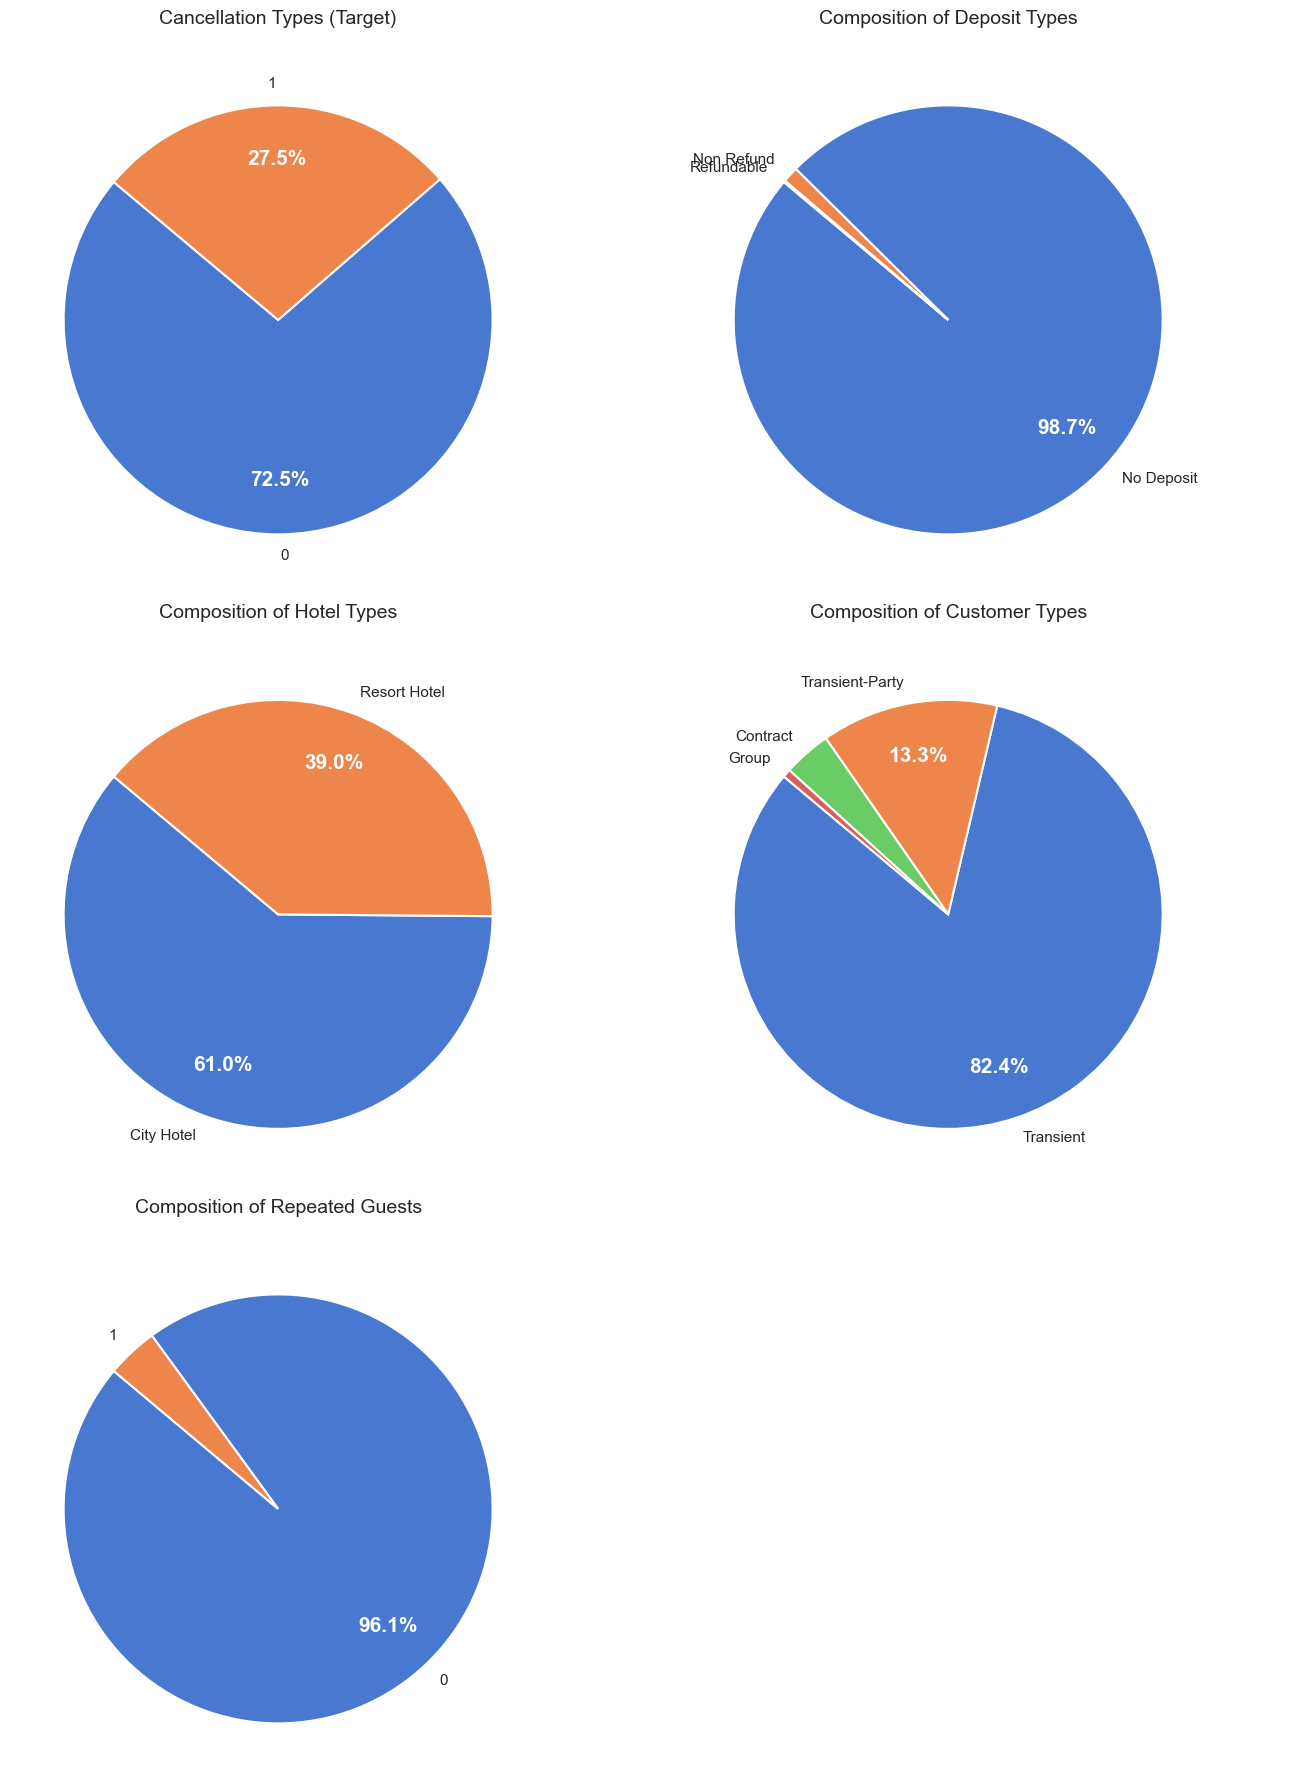

In [11]:
# 1. Standardisation: Theme and Palette
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 14})
palette = sns.color_palette("muted")

def plot_clean_pie(data, column, title, ax):
    """Generates a pie chart, hiding labels for slices < 5% to avoid overlapping."""
    counts = data[column].value_counts()
    
    # Custom autopct logic to hide small values
    def my_autopct(pct):
        return ('%1.1f%%' % pct) if pct >= 5 else ''

    wedges, texts, autotexts = ax.pie(
        counts, 
        labels=counts.index, 
        autopct=my_autopct, 
        startangle=140, 
        colors=palette, 
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
        pctdistance=0.75 # Moves text slightly inward for better fit
    )
    
    # Style the text for readability
    plt.setp(autotexts, size=15, weight="bold", color="white")
    ax.set_title(title, pad=20)

# --- Phase 1.1: Dataset Composition and Target Balance (Updated) ---

fig, axes = plt.subplots(3, 2, figsize=(14, 18))
plt.subplots_adjust(hspace=0.3, wspace=0.3)

# 1. Cancellation Types (Target)
plot_clean_pie(df, 'is_cancelled', 'Cancellation Types (Target)', axes[0, 0])

# 2. Deposit Type
plot_clean_pie(df, 'deposit_type', 'Composition of Deposit Types', axes[0, 1])

# 3. Hotel
plot_clean_pie(df, 'hotel', 'Composition of Hotel Types', axes[1, 0])

# 4. Customer Type
plot_clean_pie(df, 'customer_type', 'Composition of Customer Types', axes[1, 1])

# 5. Repeated Guest
plot_clean_pie(df, 'is_repeated_guest', 'Composition of Repeated Guests', axes[2, 0])

# Hide the 6th empty subplot
axes[2, 1].axis('off')

plt.tight_layout()
plt.show()

* Target Balance: 27.5% of bookings are cancelled. This shows the dataset is slightly imbalanced but provides a sufficient sample size for both classes without requiring aggressive resampling.

* Deposit Type: The vast majority (98.7%) of bookings are "No Deposit". This indicates a low financial barrier to cancellation for most guests.

* Hotel Types: City Hotels account for 61.0% of bookings, suggesting the dataset is more representative of urban travel patterns than resort stays.

* Customer Type: 82.4% of guests are "Transient", meaning they are individual bookings rather than group or contract-based.

* Repeated Guests: Only 3.9% are repeated guests. This indicates a low loyalty rate or a business model focused on new customer acquisition.

<a id="sec-5-2-2"></a>
#### 5.2.2 Univariate Analysis

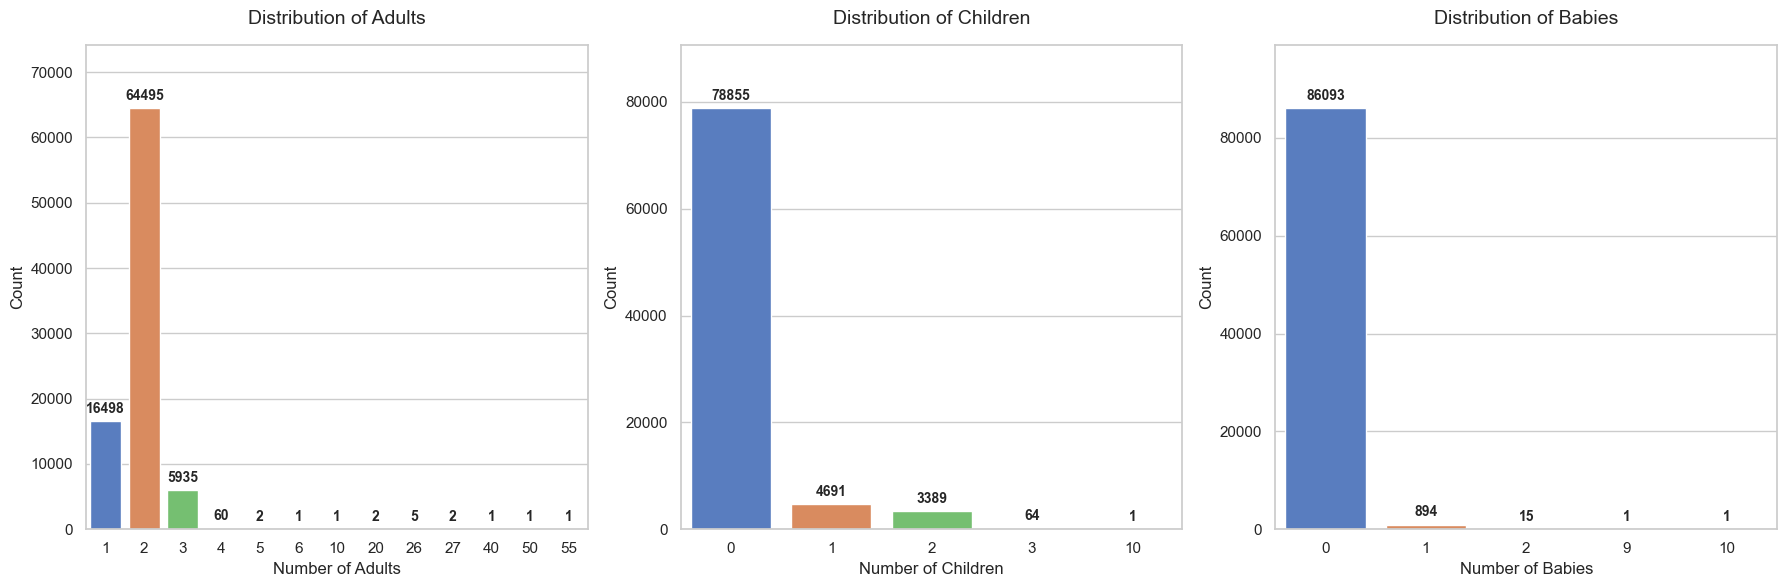

In [12]:
def plot_annotated_count(data, column, title, ax):
    """Generates a count plot with integer counts annotated above bars."""
    # Using countplot as these are discrete guest counts
    sns.countplot(x=column, data=data, ax=ax, palette="muted", hue=column, legend=False)

    ax.set_title(title, pad=15)
    ax.set_xlabel("Number of " + column.capitalize())
    ax.set_ylabel("Count")

    # Annotate values above bars
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(
                f"{int(height)}",
                (p.get_x() + p.get_width() / 2.0, height),
                ha="center",
                va="center",
                xytext=(0, 9),
                textcoords="offset points",
                fontsize=10,
                fontweight="bold",
            )

    # Adjust y-axis to make room for annotations
    ax.set_ylim(0, data[column].value_counts().max() * 1.15)


# --- 1.2. Univariate Analysis: Data Integrity ---

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Distribution of Adults
plot_annotated_count(df, "adults", "Distribution of Adults", axes[0])

# 2. Distribution of Children
# Note: children column has 4 missing values, countplot handles this but we focus on valid entries
plot_annotated_count(df, "children", "Distribution of Children", axes[1])

# 3. Distribution of Babies
plot_annotated_count(df, "babies", "Distribution of Babies", axes[2])

plt.tight_layout()
plt.savefig("univariate_integrity_guests.png")
plt.show()

* Adults: Most bookings involve 2 adults (89,680). The presence of 0 adults (403 cases) and extreme values like 55 adults confirms the need for cleaning row-level logic and capping outliers.

* Children/Babies: These distributions are heavily skewed towards 0. Values like 10 children or 10 babies are extreme outliers that could distort model training if not addressed.


<a id="sec-5-2-3"></a>
#### 5.2.3 Bivariate Analysis

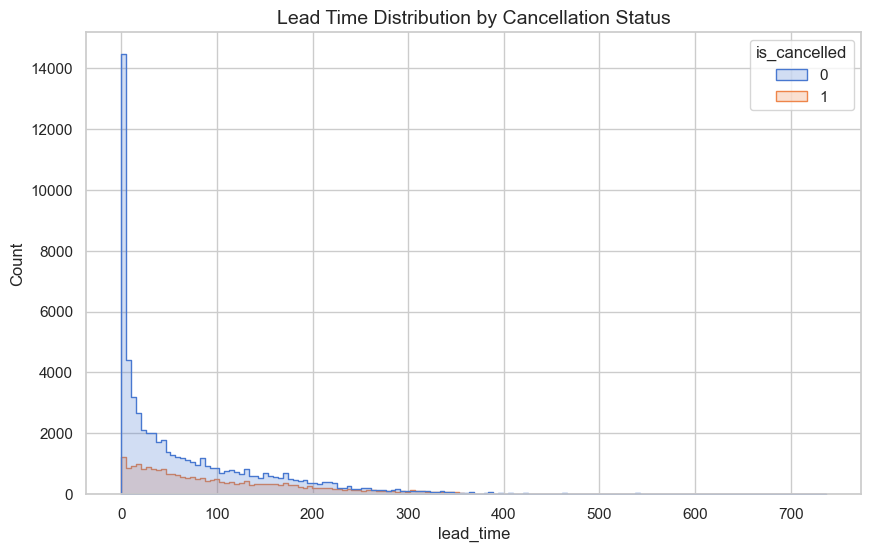

In [13]:
# Lead Time Distribution by Cancellation Status
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df, x="lead_time", hue="is_cancelled", element="step", palette="muted"
)
plt.title("Lead Time Distribution by Cancellation Status")
plt.show()

* **Observation:** The density of cancellations increases as the lead time grows. Bookings made on short notice (low lead time) show a significantly higher proportion of successful check-outs.
* **Interpretation:** A longer lead time provides a larger window for guests to change their plans or find alternative accommodation. This feature is likely a primary driver for the classification model.
* **Action:** `lead_time` is heavily right-skewed. Perform scaling use log-transform to cap extreme values to reduce skew effects.

In [14]:
# Standardisation Settings
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 11, "axes.titlesize": 14, "axes.labelsize": 12})
palette = sns.color_palette("muted")


def annotate_bars(ax, is_pct=False):
    for p in ax.patches:
        height = p.get_height()
        if np.isnan(height) or height == 0:
            continue
        if is_pct:
            label = f"{height:.1f}%"
        else:
            label = f"{int(height):,}"
        ax.annotate(
            label,
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            xytext=(0, 5),
            textcoords="offset points",
            fontsize=10,
            fontweight="bold",
        )
    ax.set_ylim(0, ax.get_ylim()[1] * 1.2)


# Helper for pairs
def plot_pair(col, title_suffix, filename, top_n=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    # Count Plot
    plot_df = df.copy()
    if top_n:
        top_cats = plot_df[col].value_counts().nlargest(top_n).index
        plot_df = plot_df[plot_df[col].isin(top_cats)]

    sns.countplot(
        data=plot_df,
        x=col,
        hue="is_cancelled_label",
        palette="muted",
        ax=ax1,
        order=plot_df[col].value_counts().index if not top_n else top_cats,
    )
    ax1.set_title(f"Bookings by {title_suffix} (count)")
    ax1.tick_params(axis="x", rotation=45)
    annotate_bars(ax1)

    # Pct Plot
    pct_df = df.groupby(col)["is_cancelled"].mean().reset_index()
    pct_df["is_cancelled"] *= 100
    if top_n:
        pct_df = pct_df[pct_df[col].isin(top_cats)]
        pct_df = pct_df.set_index(col).loc[top_cats].reset_index()
    else:
        pct_df = pct_df.sort_values("is_cancelled", ascending=False)

    sns.barplot(
        data=pct_df,
        x=col,
        y="is_cancelled",
        palette="muted",
        ax=ax2,
        hue=col,
        legend=False,
    )
    ax2.set_title(f"Booking Cancellation Only Rate by {title_suffix} (%)")
    ax2.set_ylabel("Cancellation Rate (%)")
    ax2.tick_params(axis="x", rotation=45)
    annotate_bars(ax2, is_pct=True)

    plt.tight_layout()
    plt.savefig(filename)
    return pct_df


# Helper for pairs
def plot_bivariate_pair(data, col, title_suffix):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Count Plot
    sns.countplot(data=data, x=col, hue="is_cancelled", palette="muted", ax=axes[0])
    axes[0].set_title(f"Bookings by {title_suffix} (count)")
    annotate_bars(axes[0])

    # Pct Plot (Cancellation Rate)
    # Calculate % where is_cancelled == 1
    pct_df = (
        data.groupby(col, observed=True)["is_cancelled"]
        .value_counts(normalize=True)
        .unstack()
        .fillna(0)
        * 100
    )
    if 1 in pct_df.columns:
        pct_series = pct_df[1].reset_index()
    else:
        # Handle cases with no cancellations
        pct_series = pd.DataFrame({col: pct_df.index, 1: 0.0})

    sns.barplot(
        data=pct_series, x=col, y=1, palette="muted", ax=axes[1], hue=col, legend=False
    )
    axes[1].set_title(f"Booking Cancellation Only Rate by {title_suffix} (pct)")
    axes[1].set_ylabel("Cancellation Rate (%)")
    annotate_bars(axes[1], is_pct=True)

    plt.tight_layout()
    filename = f"1_4_{col}.png"
    plt.savefig(filename)
    plt.close()
    return pct_df

C:\Users\chunj\AppData\Local\Temp\ipykernel_6796\3235937194.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


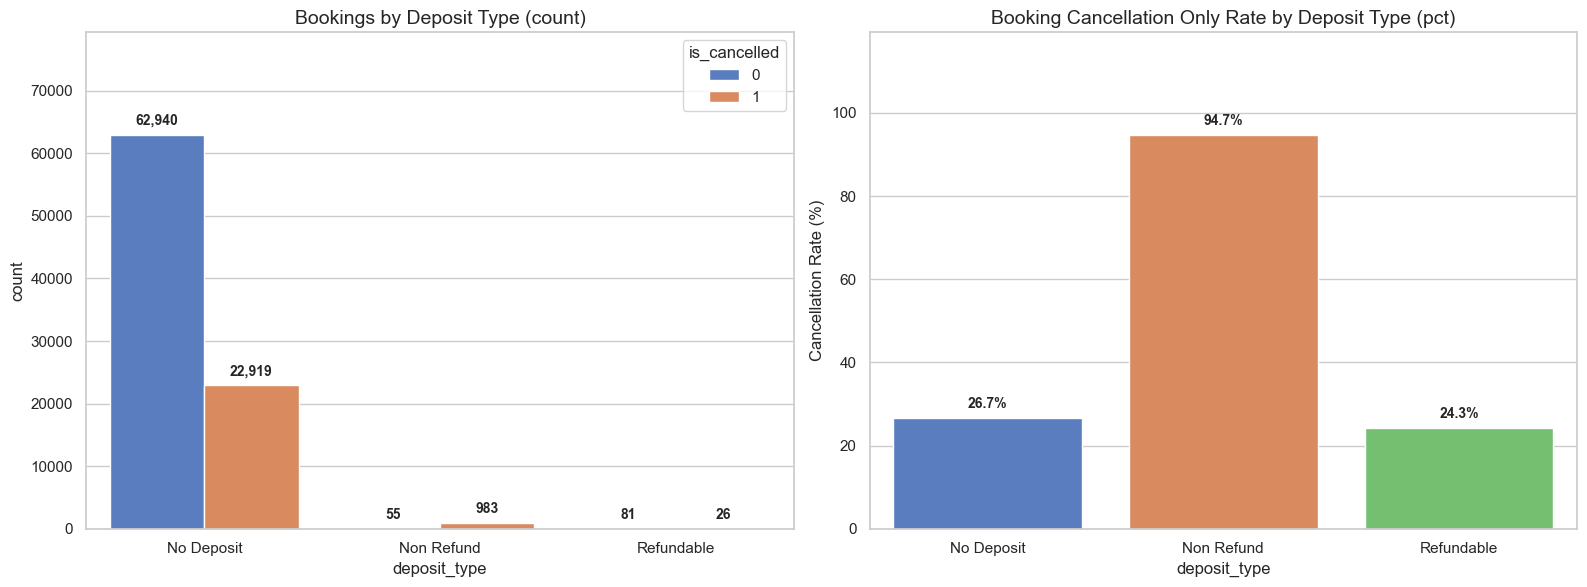

In [15]:
# Deposit Type Pair
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.countplot(
    data=df, x="deposit_type", hue="is_cancelled", palette="muted", ax=axes[0]
)
axes[0].set_title("Bookings by Deposit Type (count)")
annotate_bars(axes[0])

pct_df = (
    df.groupby("deposit_type", observed=True)["is_cancelled"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    * 100
)
sns.barplot(
    data=pct_df[1].reset_index(), x="deposit_type", y=1, palette="muted", ax=axes[1]
)
axes[1].set_title("Booking Cancellation Only Rate by Deposit Type (pct)")
axes[1].set_ylabel("Cancellation Rate (%)")
annotate_bars(axes[1], is_pct=True)
plt.tight_layout()
plt.show()

* **Observation:** While "No Deposit" bookings are the most common, the "Non Refund" category has a near-total cancellation rate of 94.7%.
* **Interpretation:** This is a strong indicator of cancellation. In this dataset, the "Non Refund" flag is almost synonymous with a cancelled booking. This suggests specific hotel policies or data collection patterns where this deposit type is assigned to high-risk bookings.

C:\Users\chunj\AppData\Local\Temp\ipykernel_6796\544119878.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


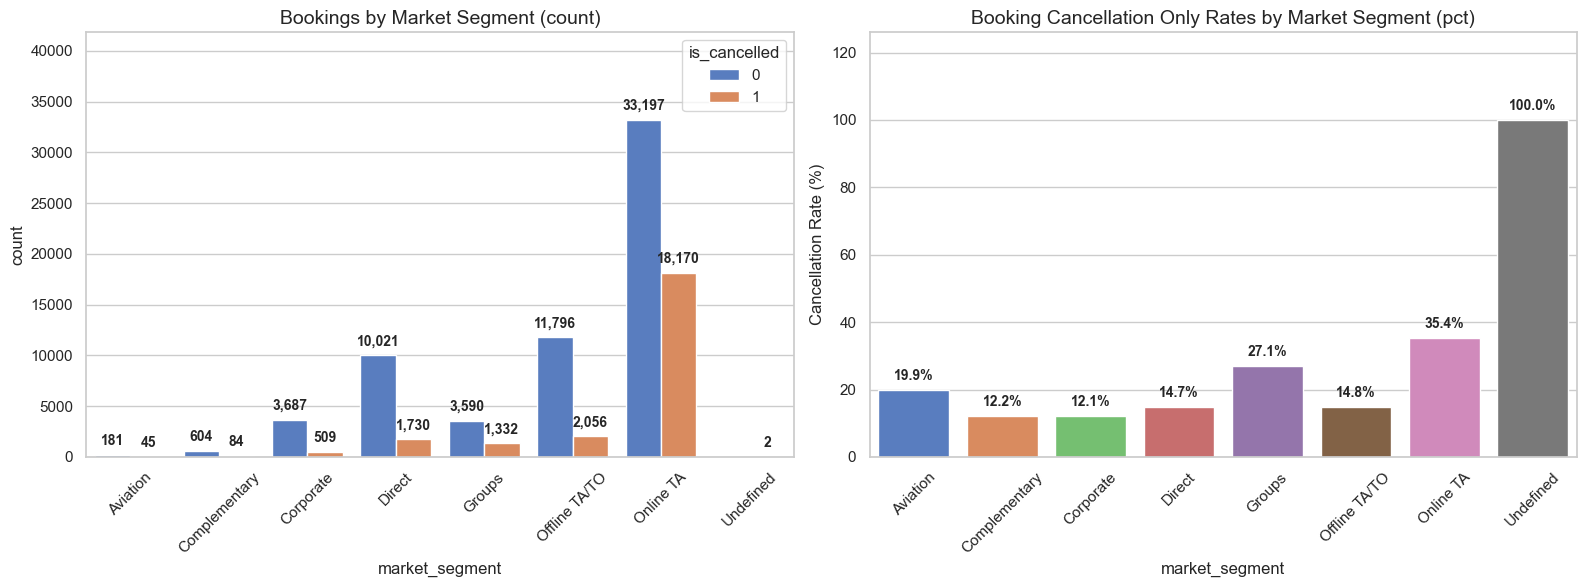

In [16]:
# Market Segment Pair
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.countplot(
    data=df, x="market_segment", hue="is_cancelled", palette="muted", ax=axes[0]
)
axes[0].set_title("Bookings by Market Segment (count)")
axes[0].tick_params(axis="x", rotation=45)
annotate_bars(axes[0])

pct_df = (
    df.groupby("market_segment", observed=True)["is_cancelled"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    * 100
)
sns.barplot(
    data=pct_df[1].reset_index(), x="market_segment", y=1, palette="muted", ax=axes[1]
)
axes[1].set_title("Booking Cancellation Only Rates by Market Segment (pct)")
axes[1].set_ylabel("Cancellation Rate (%)")
axes[1].tick_params(axis="x", rotation=45)
annotate_bars(axes[1], is_pct=True)
plt.tight_layout()
plt.show()

* **Observation:** The "Online TA" (Travel Agent) segment handles the highest volume of bookings with the highest cancellation rate at 35.4%. The "Groups" segment has the second highest cancellation rate at 27.1%.
* **Interpretation:** Group and online bookings are more volatile than other forms of bookings, potentially attributed by the ease of booking and cancelling in groups and doing them online.

C:\Users\chunj\AppData\Local\Temp\ipykernel_6796\3025862573.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pct_df[1].reset_index(), x="meal", y=1, palette="muted", ax=axes[1])


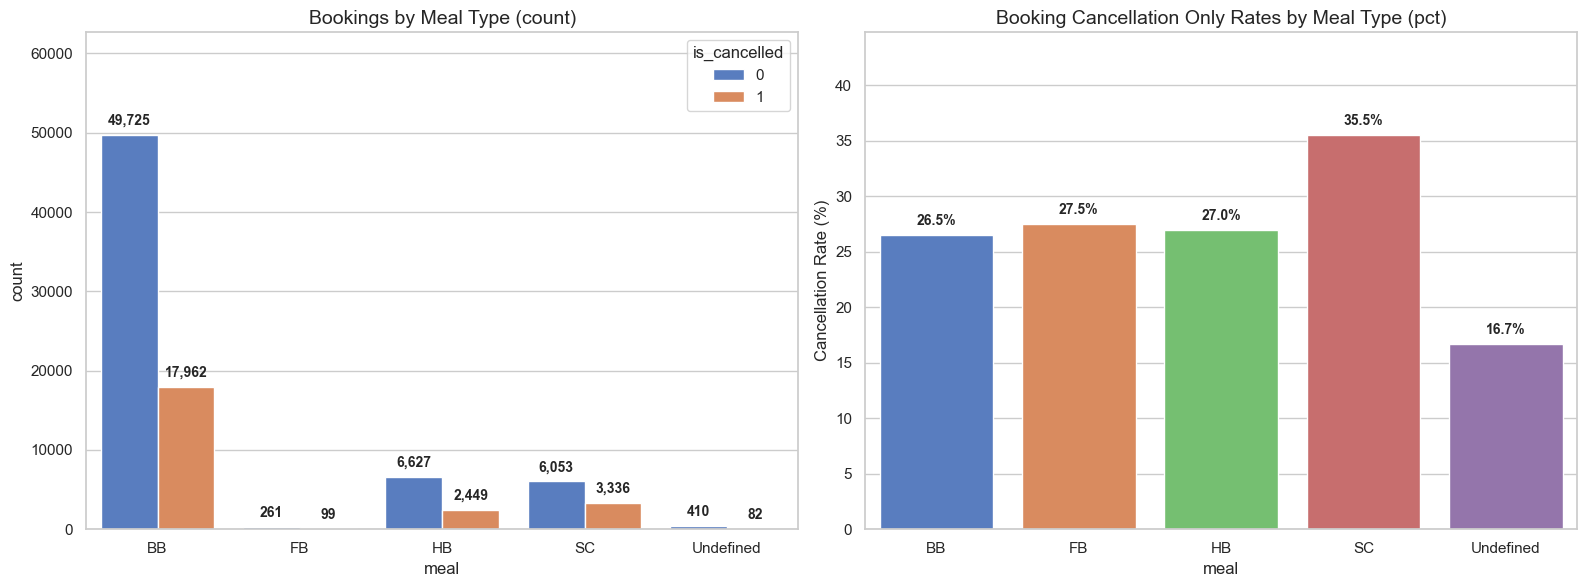

In [17]:
# Meal Type Pair
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.countplot(data=df, x="meal", hue="is_cancelled", palette="muted", ax=axes[0])
axes[0].set_title("Bookings by Meal Type (count)")
annotate_bars(axes[0])

pct_df = (
    df.groupby("meal", observed=True)["is_cancelled"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    * 100
)
sns.barplot(data=pct_df[1].reset_index(), x="meal", y=1, palette="muted", ax=axes[1])
axes[1].set_title("Booking Cancellation Only Rates by Meal Type (pct)")
axes[1].set_ylabel("Cancellation Rate (%)")
annotate_bars(axes[1], is_pct=True)
plt.tight_layout()
plt.show()

* **Observation:** Bed & Breakfast (BB) is the dominant choice. The "Full Board" (FB) option has a slightly higher cancellation rate despite its low volume.
* **Interpretation:** FB bookings may be associated with group packages or specific travel agencies that have higher cancellation tendencies. The "Undefined" category shows a lower rate, indicating a need to reclassify for clarity during cleaning.
* **Action**: Standardise the meal column by mapping all 'Undefined' values to 'SC' (Self-Catering). 

C:\Users\chunj\AppData\Local\Temp\ipykernel_6796\3401911260.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


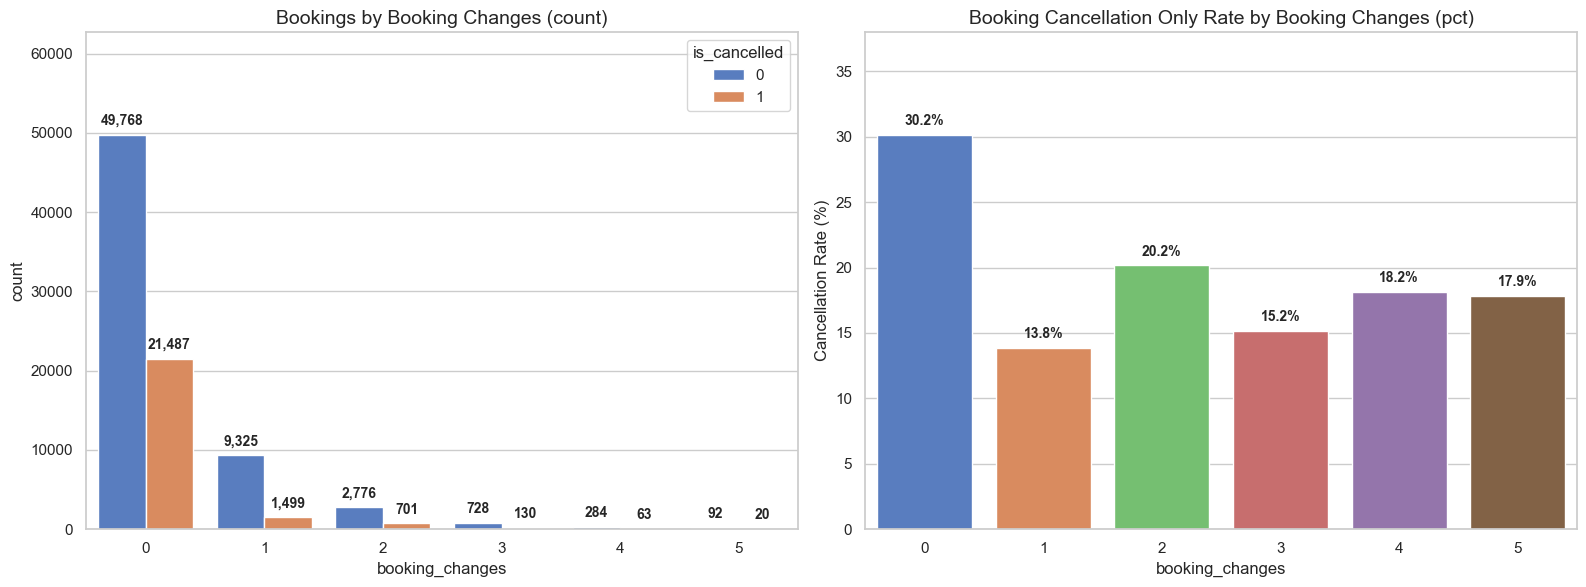

In [18]:
# Booking Changes Pair
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Focus on 0-5 changes for count clarity
sns.countplot(
    data=df[df["booking_changes"] <= 5],
    x="booking_changes",
    hue="is_cancelled",
    palette="muted",
    ax=axes[0],
)
axes[0].set_title("Bookings by Booking Changes (count)")
annotate_bars(axes[0])

pct_df = (
    df.groupby("booking_changes", observed=True)["is_cancelled"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    * 100
)
sns.barplot(
    data=pct_df[1].iloc[:6].reset_index(),
    x="booking_changes",
    y=1,
    palette="muted",
    ax=axes[1],
)
axes[1].set_title("Booking Cancellation Only Rate by Booking Changes (pct)")
axes[1].set_ylabel("Cancellation Rate (%)")
annotate_bars(axes[1], is_pct=True)
plt.tight_layout()
plt.show()

* **Observation:** Guests who make zero changes are much more likely to cancel (30.2%) than those who make at least one change.
* **Interpretation:** Booking changes indicate active engagement. A guest who takes the time to modify a booking is more likely to arrive, whereas a static booking may indicate a lack of commitment or a forgotten reservation.

C:\Users\chunj\AppData\Local\Temp\ipykernel_6796\3644385216.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


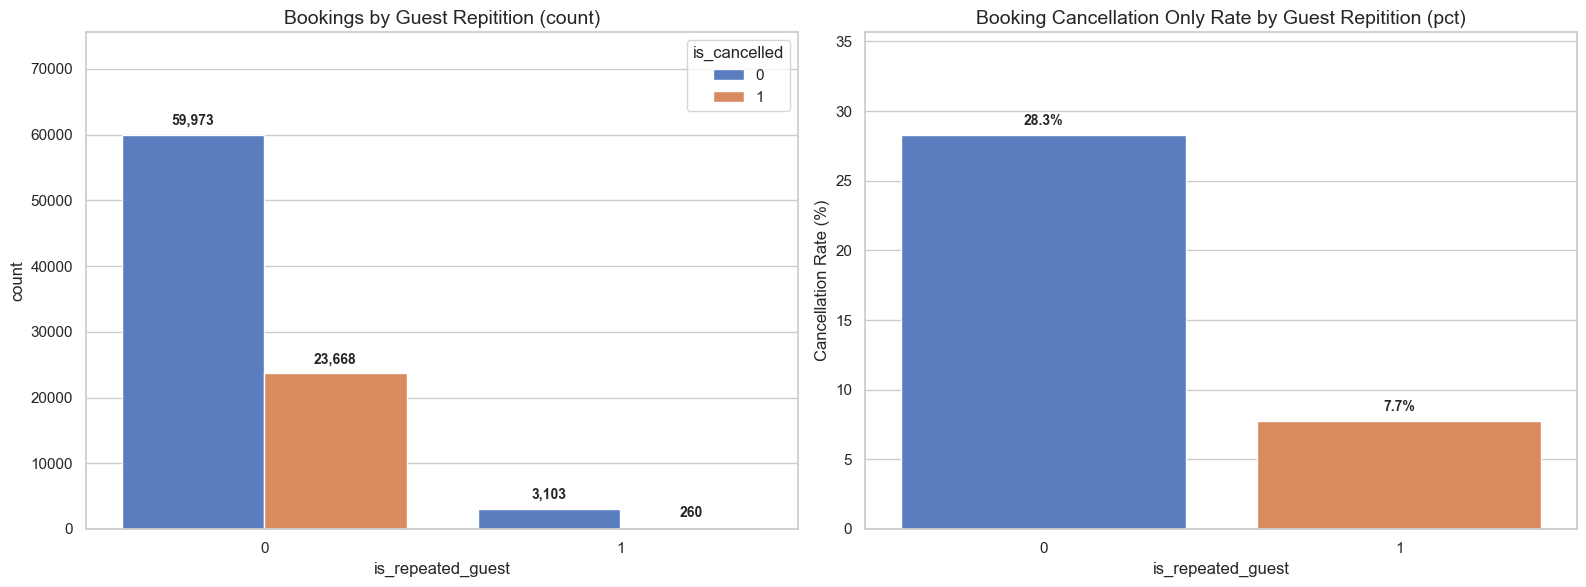

In [19]:
# Repeated Guest Pair
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.countplot(
    data=df, x="is_repeated_guest", hue="is_cancelled", palette="muted", ax=axes[0]
)
axes[0].set_title("Bookings by Guest Repitition (count)")
annotate_bars(axes[0])

pct_df = (
    df.groupby("is_repeated_guest", observed=True)["is_cancelled"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    * 100
)
sns.barplot(
    data=pct_df[1].reset_index(),
    x="is_repeated_guest",
    y=1,
    palette="muted",
    ax=axes[1],
)
axes[1].set_title("Booking Cancellation Only Rate by Guest Repitition (pct)")
axes[1].set_ylabel("Cancellation Rate (%)")
annotate_bars(axes[1], is_pct=True)
plt.tight_layout()
plt.show()

* **Observation:** Repeated guests have a much lower cancellation rate (7.7%) compared to new guests (28.3%).
* **Interpretation:** Loyalty is a strong predictor of stay completion. Returning customers are familiar with the property and are statistically more reliable.

C:\Users\chunj\AppData\Local\Temp\ipykernel_6796\2614439456.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


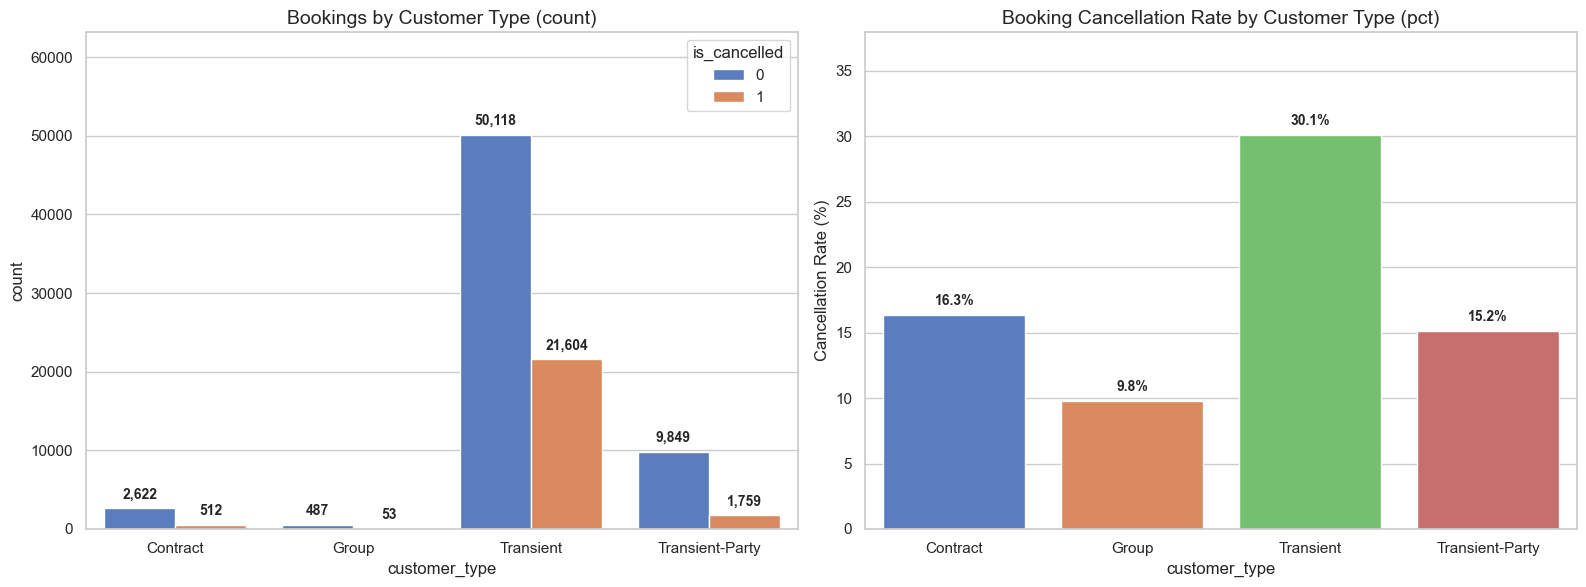

In [20]:
# Customer Type Pair
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Count of bookings split by cancellation status
sns.countplot(
    data=df, x="customer_type", hue="is_cancelled", palette="muted", ax=axes[0]
)
axes[0].set_title("Bookings by Customer Type (count)")
annotate_bars(axes[0])

# Subplot 2: Cancellation rate (Percentage) per Customer Type
pct_df = (
    df.groupby("customer_type", observed=True)["is_cancelled"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    * 100
)

# Plotting only the '1' (Cancelled) column
sns.barplot(
    data=pct_df[1].reset_index(), x="customer_type", y=1, palette="muted", ax=axes[1]
)
axes[1].set_title("Booking Cancellation Rate by Customer Type (pct)")
axes[1].set_ylabel("Cancellation Rate (%)")
annotate_bars(axes[1], is_pct=True)

plt.tight_layout()
plt.show()

* **Observation:** "Transient" customers have the highest cancellation rate (30.1%), while "Group" customers show the lowest rate (9.8%).
* **Interpretation:** Individual (Transient) travellers have more flexible plans and lower stakes in cancelling compared to those booking as part of a larger group or coordinated effort.

C:\Users\chunj\AppData\Local\Temp\ipykernel_6796\2465354600.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pct_df[1].reset_index(), x="hotel", y=1, palette="muted", ax=axes[1])


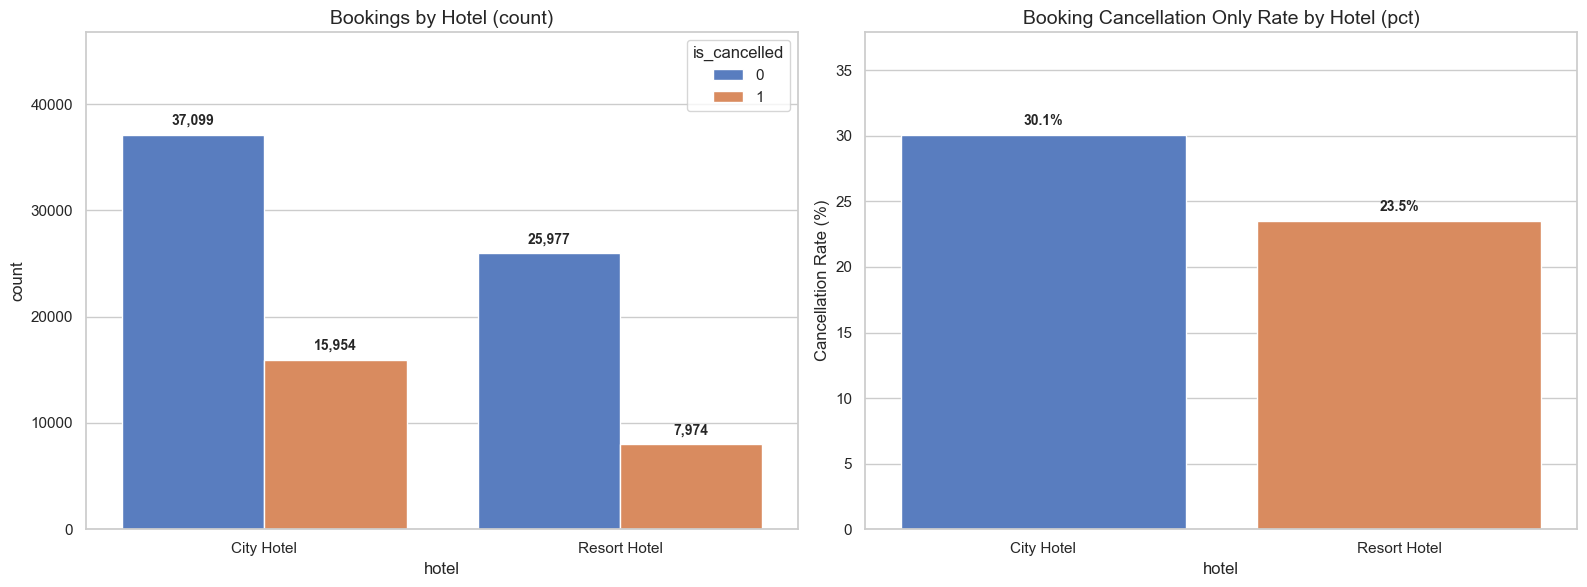

In [21]:
# Hotel Pair
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.countplot(data=df, x="hotel", hue="is_cancelled", palette="muted", ax=axes[0])
axes[0].set_title("Bookings by Hotel (count)")
annotate_bars(axes[0])

pct_df = (
    df.groupby("hotel", observed=True)["is_cancelled"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    * 100
)
sns.barplot(data=pct_df[1].reset_index(), x="hotel", y=1, palette="muted", ax=axes[1])
axes[1].set_title("Booking Cancellation Only Rate by Hotel (pct)")
axes[1].set_ylabel("Cancellation Rate (%)")
annotate_bars(axes[1], is_pct=True)
plt.tight_layout()
plt.show()

* **Observation:** City Hotels receive more bookings and suffer from a higher cancellation rate (30.1%) compared to Resort Hotels (23.5%).
* **Interpretation:** City travel is often more business-oriented or subject to shorter stay patterns, which may involve more frequent plan changes than resort-based holiday travel.

C:\Users\chunj\AppData\Local\Temp\ipykernel_6796\1136682049.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


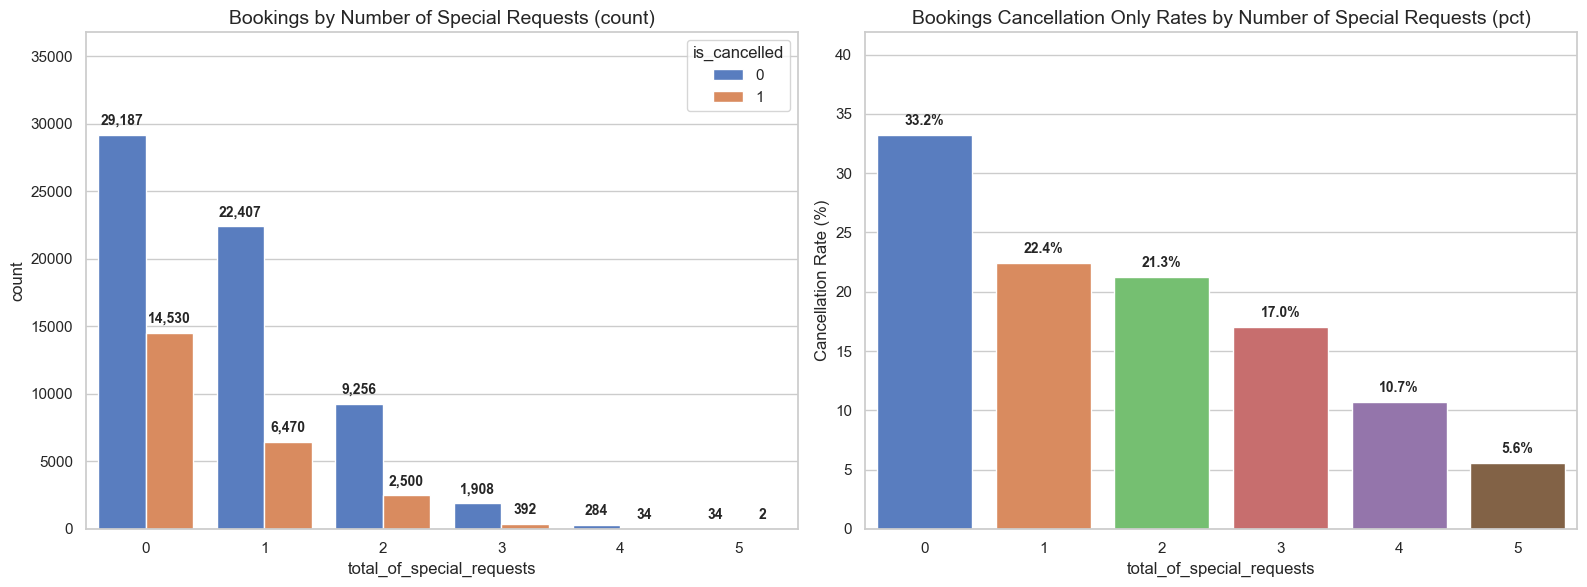

In [22]:
# Special Requests Pair
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.countplot(
    data=df,
    x="total_of_special_requests",
    hue="is_cancelled",
    palette="muted",
    ax=axes[0],
)
axes[0].set_title("Bookings by Number of Special Requests (count)")
annotate_bars(axes[0])

pct_df = (
    df.groupby("total_of_special_requests", observed=True)["is_cancelled"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    * 100
)
sns.barplot(
    data=pct_df[1].reset_index(),
    x="total_of_special_requests",
    y=1,
    palette="muted",
    ax=axes[1],
)
axes[1].set_title(
    "Bookings Cancellation Only Rates by Number of Special Requests (pct)"
)
axes[1].set_ylabel("Cancellation Rate (%)")
annotate_bars(axes[1], is_pct=True)
plt.tight_layout()
plt.show()

* **Observation:** There is a clear inverse relationship: as the number of special requests increases, the likelihood of cancellation decreases.
* **Interpretation:** Special requests indicate a higher level of personal interest and planning. Guests who make specific requests are more invested in their stay.

C:\Users\chunj\AppData\Local\Temp\ipykernel_6796\652770832.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


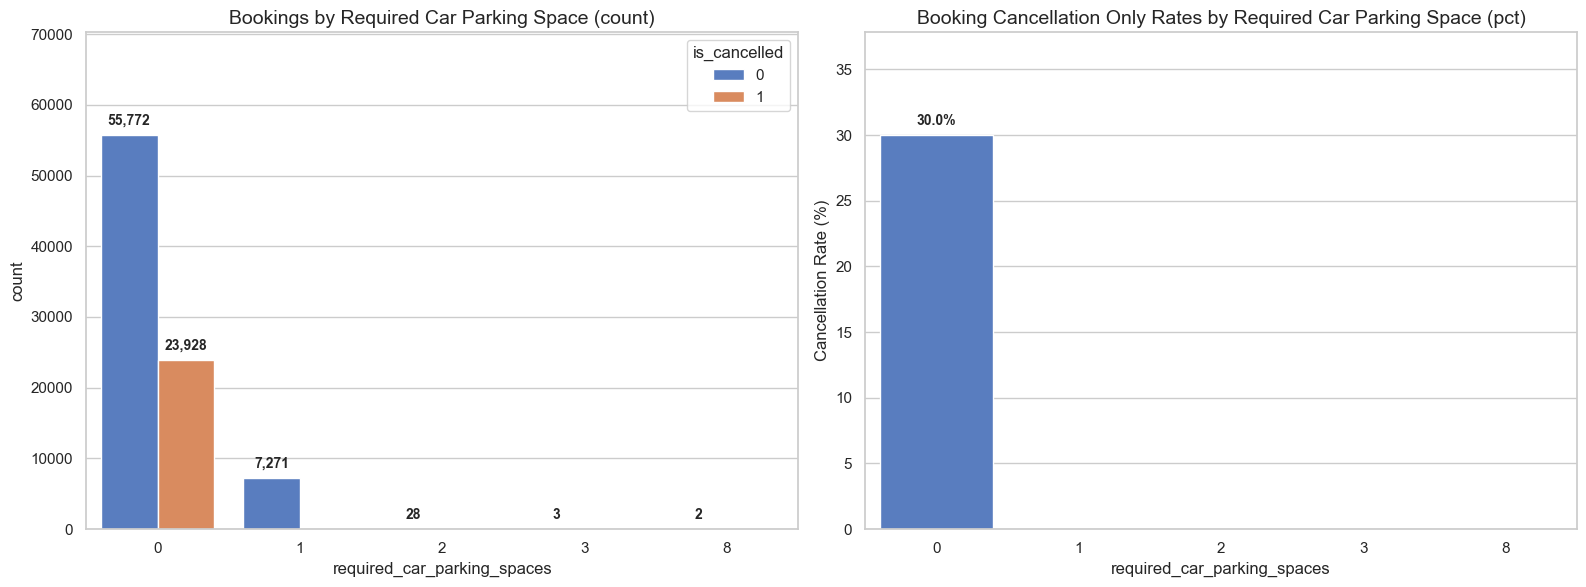

In [23]:
# Parking Space Pair
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.countplot(
    data=df,
    x="required_car_parking_spaces",
    hue="is_cancelled",
    palette="muted",
    ax=axes[0],
)
axes[0].set_title("Bookings by Required Car Parking Space (count)")
annotate_bars(axes[0])

pct_df = (
    df.groupby("required_car_parking_spaces", observed=True)["is_cancelled"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    * 100
)
# Only plot categories with cancellations
sns.barplot(
    data=pct_df[1].reset_index(),
    x="required_car_parking_spaces",
    y=1,
    palette="muted",
    ax=axes[1],
)
axes[1].set_title("Booking Cancellation Only Rates by Required Car Parking Space (pct)")
axes[1].set_ylabel("Cancellation Rate (%)")
annotate_bars(axes[1], is_pct=True)
plt.tight_layout()
plt.show()

* **Observation:** Bookings that require parking spaces show zero cancellations, meaninig the cancellation rate for 1 or more spaces is 0%.
* **Interpretation:** Guests who request parking are almost certainly arriving at the property. This feature serves as a near-perfect indicator of a successful check-out.
* **Action:** Transform the required_car_parking_spaces column into a binary categorical feature 'parking_required'. Assign a value of 1 for bookings requiring one or more spaces and 0 for those requiring none. Discard the original numeric column to simplify the feature space and minimise dimensionality during the encoding phase.

C:\Users\chunj\AppData\Local\Temp\ipykernel_6796\2724398848.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


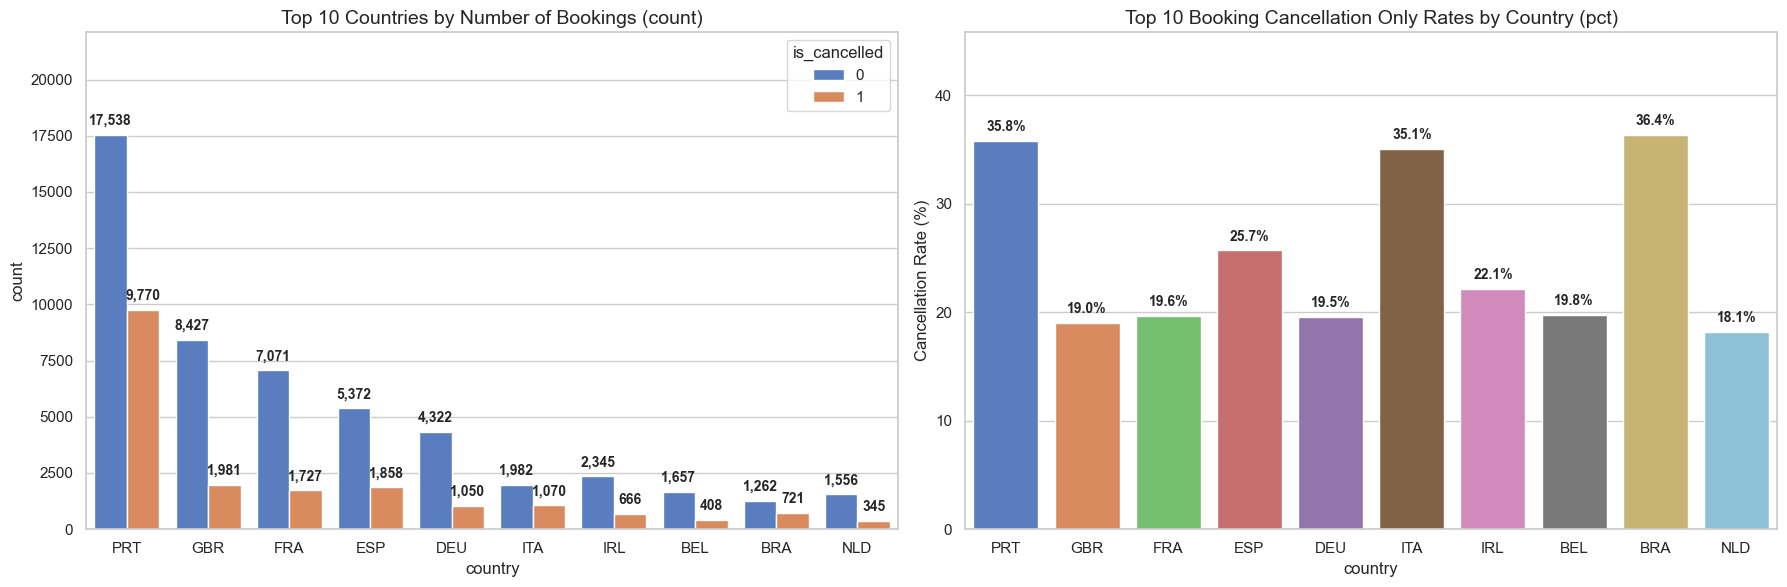

In [24]:
# Top 10 Countries Pair
top_countries = df["country"].value_counts().head(10).index
df_top = df[df["country"].isin(top_countries)]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.countplot(
    data=df_top,
    x="country",
    hue="is_cancelled",
    palette="muted",
    ax=axes[0],
    order=top_countries,
)
axes[0].set_title("Top 10 Countries by Number of Bookings (count)")
annotate_bars(axes[0])

pct_country = (
    df_top.groupby("country", observed=True)["is_cancelled"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    * 100
)
sns.barplot(
    data=pct_country[1].reset_index(),
    x="country",
    y=1,
    palette="muted",
    ax=axes[1],
    order=top_countries,
)
axes[1].set_title("Top 10 Booking Cancellation Only Rates by Country (pct)")
axes[1].set_ylabel("Cancellation Rate (%)")
annotate_bars(axes[1], is_pct=True)
plt.tight_layout()
plt.show()

* **Observation:** Portugal (PRT) has the highest volume of bookings and one of the highest cancellation rates (35.8%) among the top 10 countries. Italy (ITA) and Brazil (BRA) have similar high cancellation rates of 35.1% and 36.4% respectively.
* **Interpretation:** Local bookings show higher volatility. This may be due to the ease of domestic travel changes compared to international travellers from countries like the UK or France, who show much lower cancellation rates.
* **Action:** 'country' is a high cardinality feature with 177 unique countries, hence we group the Top 10 Countries (which cover ~80% of bookings) and label the rest as 'Other'

#### 5.2.3.1 Formal Statistical Testing for Bivariate Findings

The visual bivariate plots are supplemented with formal hypothesis tests so the notebook demonstrates statistical rigour rather than relying on visual separation alone.

* **Categorical / discrete features:** chi-square test of independence, reported with **Cramer's V**
* **Numeric features:** Welch’s t-test, reported with **Cohen’s d**
* **Multiple testing correction:** Benjamini-Hochberg adjusted p-values across all tests

The table below is the reference point for the earlier plot interpretations: a feature may be statistically significant due to the large sample size, but the **effect size** tells us whether that difference is practically meaningful.


In [25]:
def benjamini_hochberg_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    n = len(p_values)
    order = np.argsort(p_values)
    ranked = p_values[order]
    adjusted = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        bh_value = ranked[i] * n / rank
        prev = min(prev, bh_value)
        adjusted[i] = prev
    adjusted = np.clip(adjusted, 0, 1)
    restored = np.empty(n, dtype=float)
    restored[order] = adjusted
    return restored

def cramers_v_from_table(contingency_table):
    chi2, _, _, _ = chi2_contingency(contingency_table)
    n = contingency_table.to_numpy().sum()
    r, c = contingency_table.shape
    return np.sqrt(chi2 / (n * max(min(r - 1, c - 1), 1)))

def cohens_d(cancelled_values, not_cancelled_values):
    cancelled_values = np.asarray(cancelled_values, dtype=float)
    not_cancelled_values = np.asarray(not_cancelled_values, dtype=float)
    n1, n2 = len(cancelled_values), len(not_cancelled_values)
    if n1 < 2 or n2 < 2:
        return np.nan
    pooled_std = np.sqrt(
        (
            ((n1 - 1) * cancelled_values.var(ddof=1))
            + ((n2 - 1) * not_cancelled_values.var(ddof=1))
        )
        / (n1 + n2 - 2)
    )
    if pooled_std == 0:
        return 0.0
    return (cancelled_values.mean() - not_cancelled_values.mean()) / pooled_std

def effect_size_label(effect_size):
    effect_size = abs(effect_size)
    if effect_size < 0.10:
        return "negligible"
    if effect_size < 0.30:
        return "small"
    if effect_size < 0.50:
        return "medium"
    return "large"

top_countries_stats = df["country"].value_counts().head(10).index
country_grouped_for_stats = df["country"].apply(
    lambda value: value if value in top_countries_stats else "Other"
)

categorical_features_for_tests = {
    "deposit_type": df["deposit_type"].astype(str),
    "market_segment": df["market_segment"].astype(str),
    "meal": df["meal"].astype(str),
    "booking_changes": df["booking_changes"].astype(str),
    "is_repeated_guest": df["is_repeated_guest"].astype(str),
    "customer_type": df["customer_type"].astype(str),
    "hotel": df["hotel"].astype(str),
    "total_of_special_requests": df["total_of_special_requests"].astype(str),
    "required_car_parking_spaces": df["required_car_parking_spaces"].astype(str),
    "country_top10_other": country_grouped_for_stats.astype(str),
    "arrival_date_month": df["arrival_date_month"].astype(str),
}

numeric_features_for_tests = {
    "lead_time": pd.to_numeric(df["lead_time"], errors="coerce"),
    "adr": pd.to_numeric(df["adr"], errors="coerce"),
}

stats_results = []

for feature_name, feature_series in categorical_features_for_tests.items():
    contingency_table = pd.crosstab(feature_series, df["is_cancelled"])
    chi2, p_value, _, _ = chi2_contingency(contingency_table)
    effect_size = cramers_v_from_table(contingency_table)
    stats_results.append(
        {
            "feature": feature_name,
            "test": "Chi-square",
            "raw_p_value": p_value,
            "effect_size": effect_size,
            "effect_size_name": "Cramer's V",
        }
    )

for feature_name, feature_series in numeric_features_for_tests.items():
    cancelled = feature_series[df["is_cancelled"] == 1].dropna()
    not_cancelled = feature_series[df["is_cancelled"] == 0].dropna()
    _, p_value = ttest_ind(cancelled, not_cancelled, equal_var=False)
    effect_size = cohens_d(cancelled, not_cancelled)
    stats_results.append(
        {
            "feature": feature_name,
            "test": "Welch's t-test",
            "raw_p_value": p_value,
            "effect_size": effect_size,
            "effect_size_name": "Cohen's d",
        }
    )

stats_results_df = pd.DataFrame(stats_results)
stats_results_df["adjusted_p_value"] = benjamini_hochberg_adjust(
    stats_results_df["raw_p_value"].to_numpy()
)
stats_results_df["interpretation"] = stats_results_df.apply(
    lambda row: (
        "Statistically significant after BH correction; "
        f"{effect_size_label(row['effect_size'])} practical effect "
        f"({row['effect_size_name']}={row['effect_size']:.3f})."
        if row["adjusted_p_value"] < 0.05
        else f"Not statistically significant after BH correction ({row['effect_size_name']}={row['effect_size']:.3f})."
    ),
    axis=1,
)
display(
    stats_results_df[
        [
            "feature",
            "test",
            "raw_p_value",
            "adjusted_p_value",
            "effect_size_name",
            "effect_size",
            "interpretation",
        ]
    ].round({"raw_p_value": 6, "adjusted_p_value": 6, "effect_size": 3})
)


,feature,test,raw_p_value,adjusted_p_value,effect_size_name,effect_size,interpretation
0,deposit_type,Chi-square,0.0,0.0,Cramer's V,0.165,Statistically significant after BH correction;...
1,market_segment,Chi-square,0.0,0.0,Cramer's V,0.221,Statistically significant after BH correction;...
2,meal,Chi-square,0.0,0.0,Cramer's V,0.065,Statistically significant after BH correction;...
3,booking_changes,Chi-square,0.0,0.0,Cramer's V,0.129,Statistically significant after BH correction;...
4,is_repeated_guest,Chi-square,0.0,0.0,Cramer's V,0.089,Statistically significant after BH correction;...
5,customer_type,Chi-square,0.0,0.0,Cramer's V,0.128,Statistically significant after BH correction;...
6,hotel,Chi-square,0.0,0.0,Cramer's V,0.072,Statistically significant after BH correction;...
7,total_of_special_requests,Chi-square,0.0,0.0,Cramer's V,0.132,Statistically significant after BH correction;...
8,required_car_parking_spaces,Chi-square,0.0,0.0,Cramer's V,0.186,Statistically significant after BH correction;...
9,country_top10_other,Chi-square,0.0,0.0,Cramer's V,0.156,Statistically significant after BH correction;...


### 5.2.3.2 Statistical Test Findings

The formal tests confirm that the visual bivariate patterns are not due to random variation: **all tested features remain statistically significant after Benjamini-Hochberg correction**. However, with a dataset of this size, significance alone is not enough, so the **effect sizes** are the more useful guide for interpretation.

**Strongest categorical associations (largest Cramer's V values):**

* **`market_segment` (0.221)** shows the strongest categorical relationship with cancellation, indicating that booking source and segment behaviour materially affect cancellation risk.
* **`required_car_parking_spaces` (0.186)** and **`deposit_type` (0.165)** also show comparatively stronger effects, supporting the earlier observation that guest commitment and booking intent are important operational signals.
* **`country_top10_other` (0.156)**, **`total_of_special_requests` (0.132)**, **`booking_changes` (0.129)**, and **`customer_type` (0.128)** provide additional small-to-moderate practical signal.

**Weaker but still meaningful categorical associations:**

* **`meal` (0.065)**, **`hotel` (0.072)**, **`arrival_date_month` (0.086)**, and **`is_repeated_guest` (0.089)** are statistically significant, but their smaller effect sizes suggest they should be treated as supportive rather than dominant predictors.

**Numeric features:**

* **`lead_time` (Cohen's d = 0.420)** is the strongest overall tested feature in practical terms, with a clear medium-sized difference between cancelled and non-cancelled bookings.
* **`adr` (Cohen's d = 0.288)** shows a smaller but still meaningful separation, indicating that room rate contributes useful signal but is not as influential as booking horizon.

**Modelling implication:**

The results justify carrying forward variables related to **booking timing, market segment, deposit policy, parking demand, guest intent, and retained booking history** into the modelling pipeline. They also support comparing both linear and non-linear models, since the signal is spread across several features with varying effect strengths rather than dominated by a single simple rule.


### 5.2.3.3 Note on Feature Selection

These formal statistical tests **inform feature justification**, but they do **not mechanically determine feature selection** for modelling.

This is because:

* the tests above are **univariate**, meaning each feature is assessed against `is_cancelled` one at a time;
* a feature with a small standalone effect can still become useful inside **multivariate** models through interactions with other predictors;
* the final feature set should therefore be judged mainly through **pipeline performance, ablation results, and validation metrics**, not by statistical significance alone.

Accordingly, the notebook uses these test results to support the inclusion of key variables such as `lead_time`, `market_segment`, `deposit_type`, parking demand, special requests, country grouping, and retained booking-history fields, but it does not drop weaker-effect variables solely because their effect sizes are smaller.


<a id="sec-5-2-4"></a>
#### 5.2.4 Temporal and ADR Trends

In [26]:
# Standardisation Settings
def annotate_line(ax, format_str="{:.0f}", is_pct=False):
    """Helper to annotate line charts."""
    for line in ax.get_lines():
        xdata = line.get_xdata()
        ydata = line.get_ydata()
        for x, y in zip(xdata, ydata):
            if pd.isna(y):
                continue
            label = format_str.format(y)
            if is_pct:
                label += "%"
            ax.annotate(
                label,
                (x, y),
                textcoords="offset points",
                xytext=(0, 10),
                ha="center",
                fontsize=9,
                fontweight="bold",
            )
    ax.set_ylim(ax.get_ylim()[0], ax.get_ylim()[1] * 1.15)

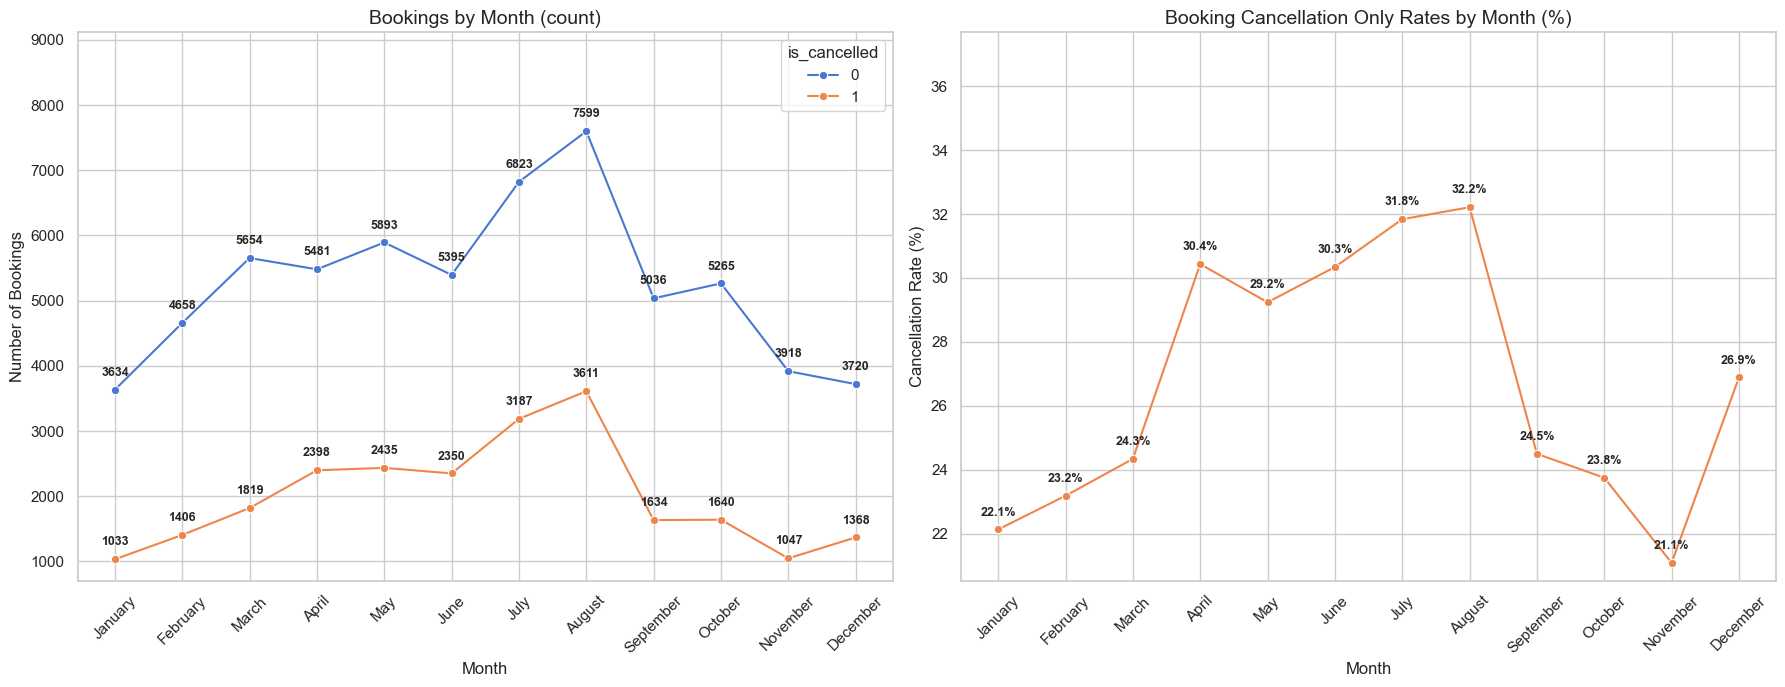

In [27]:
# --- 5.2.4.1 Temporal Trends: Bookings and Rates by Month ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Bookings by Month (count)
month_counts = (
    df.groupby(["arrival_date_month", "is_cancelled"], observed=True)
    .size()
    .reset_index(name="count")
)
sns.lineplot(
    data=month_counts,
    x="arrival_date_month",
    y="count",
    hue="is_cancelled",
    marker="o",
    palette="muted",
    ax=axes[0],
)
axes[0].set_title("Bookings by Month (count)")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Number of Bookings")
axes[0].tick_params(axis="x", rotation=45)
annotate_line(axes[0])

# Plot 2: Booking Cancellation Only Rates by Month (pct)
month_pct = (
    df.groupby("arrival_date_month", observed=True)["is_cancelled"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
    * 100
)
month_pct = month_pct[1].reset_index(name="rate")
sns.lineplot(
    data=month_pct,
    x="arrival_date_month",
    y="rate",
    marker="o",
    color=palette[1],
    ax=axes[1],
)
axes[1].set_title("Booking Cancellation Only Rates by Month (%)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Cancellation Rate (%)")
axes[1].tick_params(axis="x", rotation=45)
annotate_line(axes[1], format_str="{:.1f}", is_pct=True)

plt.tight_layout()
plt.savefig("1_5_temporal_counts_rates.png")
plt.show()

* **Observation:** Booking volume peaks during the summer months (July and August), which also see the highest number of cancellation rates, peaking at **32.2%** in August.
* **Interpretation:** The summer peak reflects high demand. The elevated cancellation rates in the preceding months may indicate "placeholder" bookings made by travellers who later refined their plans or opted for different destinations as the peak season approached.

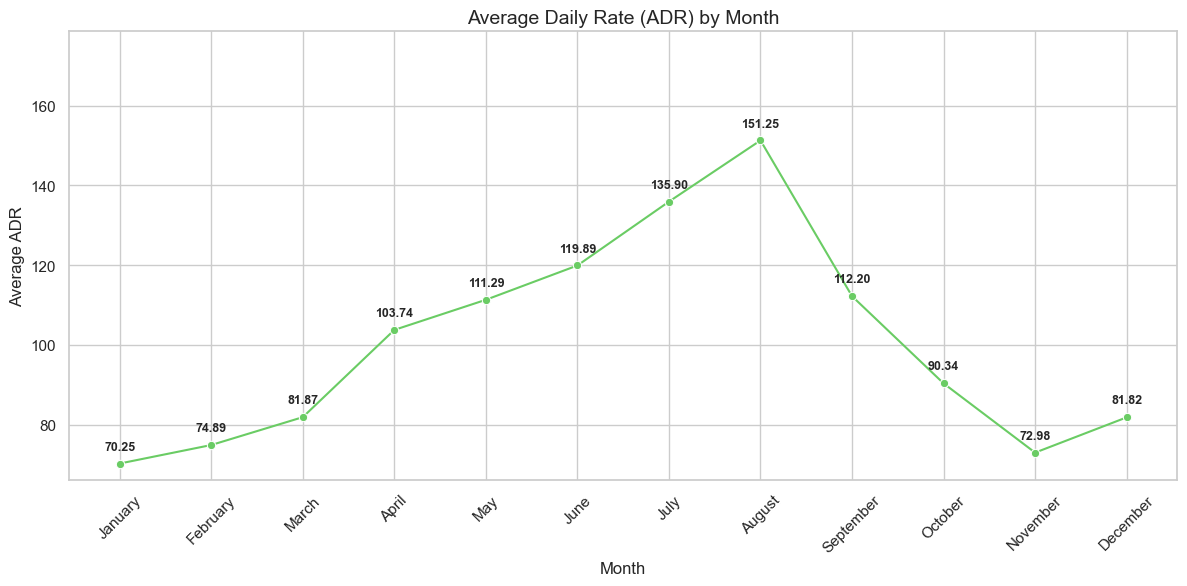

In [28]:
# --- 5.2.4.2 Temporal Trends: ADR by Month ---

# ADR by Month (line chart)
plt.figure(figsize=(12, 6))
# Using mean ADR
month_adr = df.groupby("arrival_date_month", observed=True)["adr"].mean().reset_index()
ax_adr = sns.lineplot(
    data=month_adr, x="arrival_date_month", y="adr", marker="o", color=palette[2]
)
plt.title("Average Daily Rate (ADR) by Month")
plt.xlabel("Month")
plt.ylabel("Average ADR")
plt.xticks(rotation=45)
annotate_line(ax_adr, format_str="{:.2f}")
plt.tight_layout()
plt.savefig("1_5_adr_by_month.png")
plt.show()

* **Observation:** The Average Daily Rate follows a strong seasonal pattern, rising steadily from January (70.25) to a peak in August (**151.25**), before declining towards the end of the year.
* **Interpretation:** This confirms seasonal pricing strategy where the hotel capitalises on high summer demand. The sharp rise in ADR aligns with the booking volume peak, indicating that pricing power is strongest during July and August.

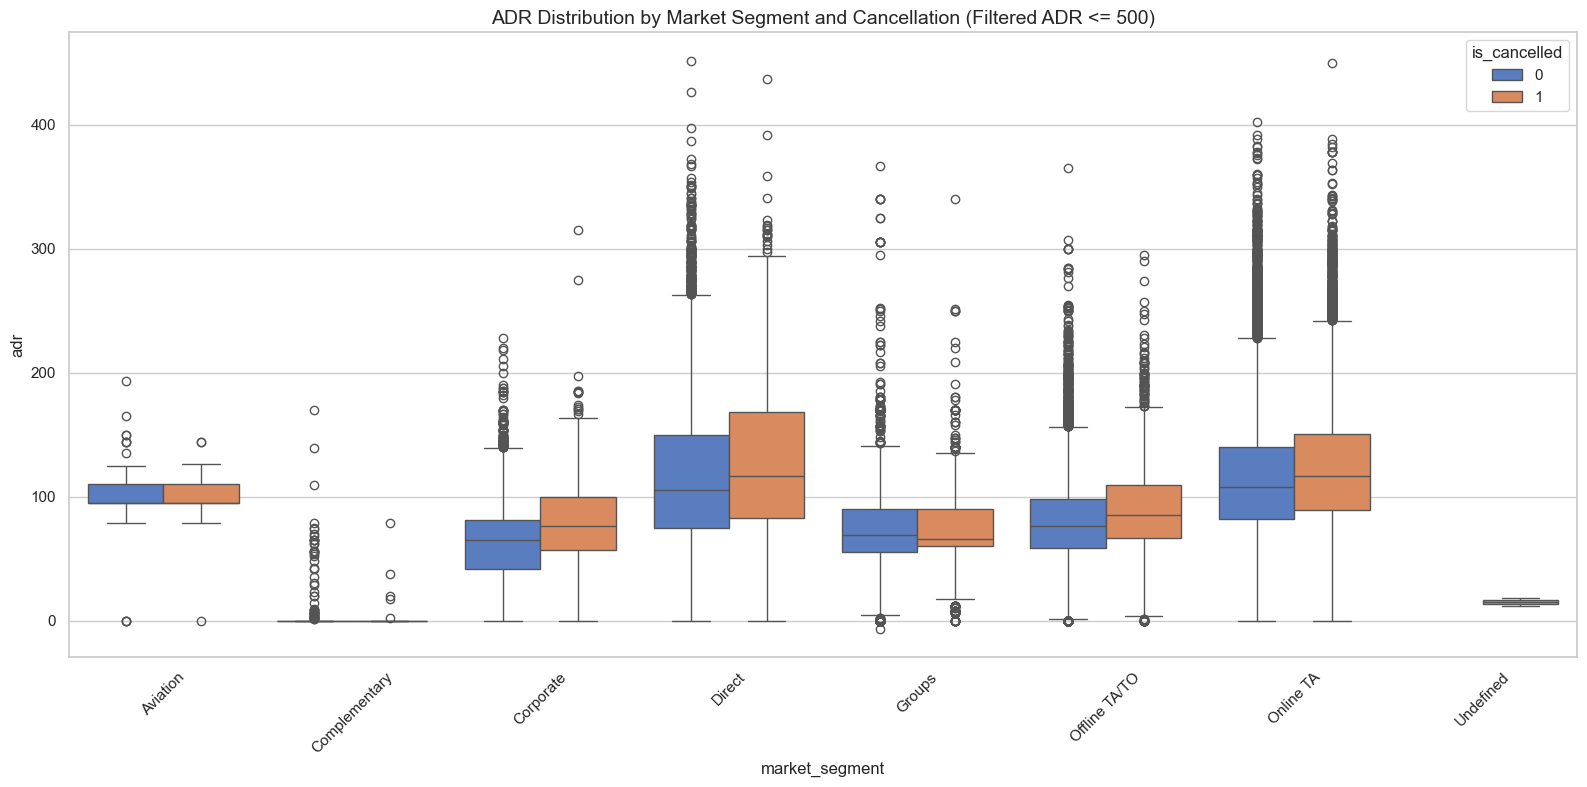

In [29]:
# Filtering out the extreme ADR outlier to prevent plot distortion
df_filtered = df[df["adr"] <= 500].copy()

# ADR Distribution by Market Segment and Cancellation (Boxplot)
plt.figure(figsize=(16, 8))
sns.boxplot(
    data=df_filtered, x="market_segment", y="adr", hue="is_cancelled", palette="muted"
)

plt.title("ADR Distribution by Market Segment and Cancellation (Filtered ADR <= 500)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("1_5_adr_boxplot.png")
plt.show()

In [30]:
# Descriptive Statistics Table for the filtered data
adr_stats = (
    df_filtered.groupby(["market_segment", "is_cancelled"], observed=True)["adr"]
    .describe()
    .round(2)
)
print("\nDescriptive Statistics for ADR by Market Segment and Cancellation (Filtered):")
adr_stats


Descriptive Statistics for ADR by Market Segment and Cancellation (Filtered):


count    mean    std    min    25%     50%  \
market_segment is_cancelled                                                 
Aviation       0               181.0  100.63  19.85   0.00  95.00   95.00   
               1                45.0  100.54  20.25   0.00  95.00   95.00   
Complementary  0               604.0    3.28  15.10   0.00   0.00    0.00   
               1                84.0    1.86   9.85   0.00   0.00    0.00   
Corporate      0              3686.0   66.70  31.02   0.00  42.00   65.00   
               1               509.0   79.62  36.84   0.00  56.95   76.00   
Direct         0             10021.0  115.22  59.18   0.00  75.00  105.00   
               1              1730.0  126.97  63.49   0.00  82.50  117.00   
Groups         0              3590.0   74.73  39.16  -6.38  55.00   68.74   
               1              1332.0   76.34  34.75   0.00  60.00   66.00   
Offline TA/TO  0             11795.0   80.18  35.88   0.00  58.95   76.67   
               1              2055.0   89.40  37.71   0.00  66.46   85.00   
Online TA      0             33197.0  114.92  49.02   0.00  82.00  108.00   
               1             18170.0  124.76  49.99   0.00  89.12  117.02   
Undefined      1                 2.0   15.00   4.24  12.00  13.50   15.00   

                               75%    max  
market_segment is_cancelled                
Aviation       0             110.0  193.5  
               1             110.0  144.0  
Complementary  0               0.0  170.0  
               1               0.0   79.0  
Corporate      0              81.0  228.0  
               1             100.0  315.0  
Direct         0             150.0  451.5  
               1             168.0  437.0  
Groups         0              90.0  367.0  
               1              90.0  340.0  
Offline TA/TO  0              98.0  365.0  
               1             109.0  294.5  
Online TA      0             140.4  402.0  
               1             150.3  450.0  
Undefined      1              16.5   18.0

* **Observation:** Across almost all market segments (Direct, Corporate, Online TA), cancelled bookings tend to have a slightly higher median ADR than successful check-outs. There are significant outliers in several segments, including a maximum ADR of **5400** in the Offline TA/TO segment, which was removed to prevent plot distortion, and a negative ADR in the "Groups" segment. 
* **Interpretation:** Higher prices may increase the likelihood of cancellation as guests become more sensitive to value or more likely to find a cheaper alternative. The presence of extreme outliers (e.g., ADR > 500) suggests data entry errors.
* **Action:** Remove or cap values exceeding a reasonable threshold like the 99th percentile to prevent exteme variance from distorting model training. Additionally, address the logical error of negative ADR values identified in the "Groups" segment. Lastly, perform feature scaling to handle large variance in values.

<a id="sec-5-3"></a>
### 5.2.5 Multivariate Analysis

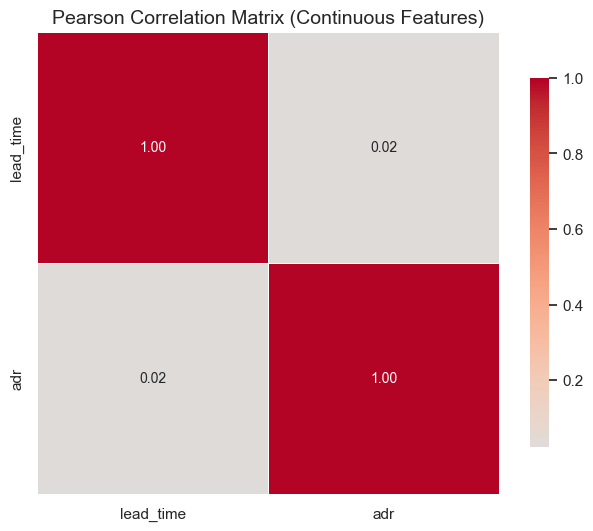

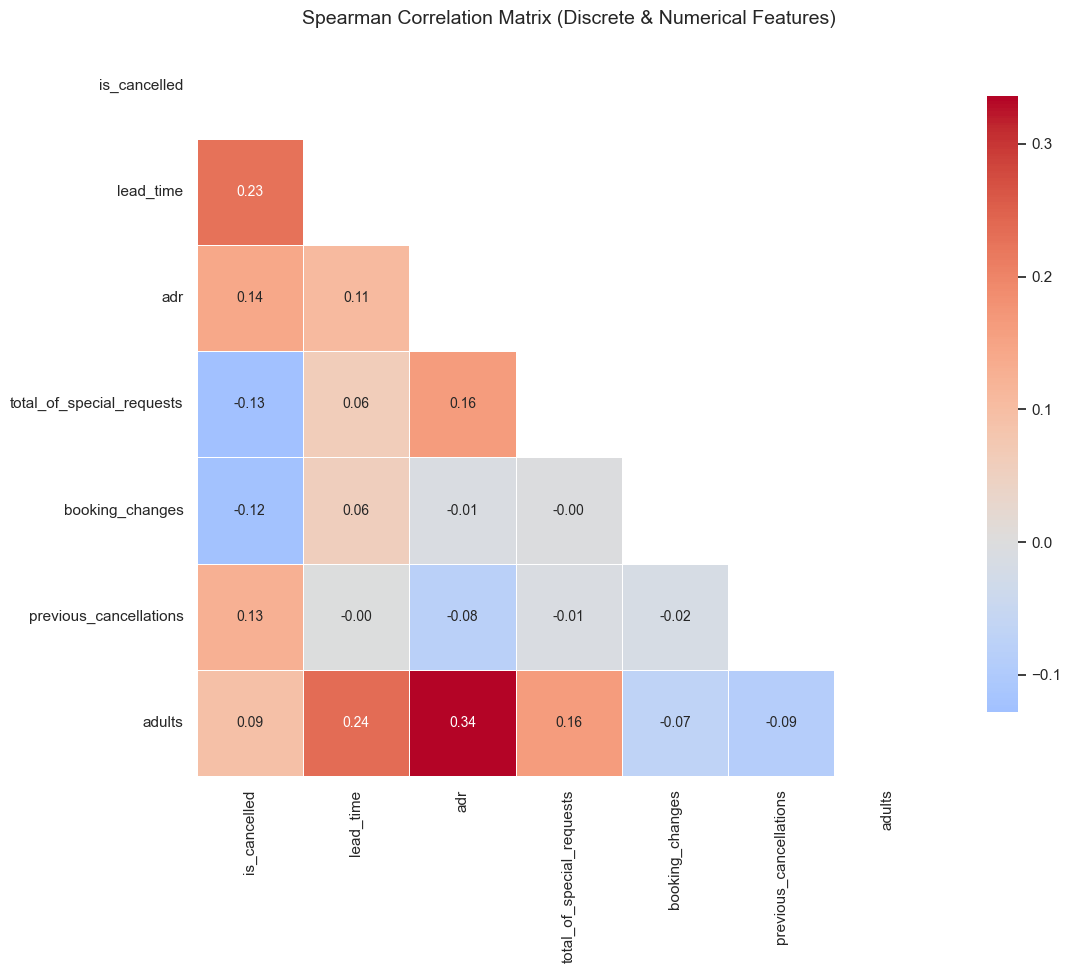

In [31]:
# Define feature lists based on previous categorisation
continuous_features = ["lead_time", "adr"]
# Including is_cancelled (target) and high-impact discrete counts for Spearman
spearman_features = [
    "is_cancelled",
    "lead_time",
    "adr",
    "total_of_special_requests",
    "booking_changes",
    "previous_cancellations",
    "adults"
]

# Standardisation: Theme
sns.set_theme(style="white")  # White style is better for heatmaps
plt.rcParams.update({"font.size": 10, "axes.titlesize": 14})

# --- 1. Correlation Matrix (Pearson) ---
plt.figure(figsize=(8, 6))
pearson_corr = df[continuous_features].corr(method="pearson")
sns.heatmap(
    pearson_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("Pearson Correlation Matrix (Continuous Features)")
plt.show()

# --- 2. Correlation Matrix (Spearman) ---
plt.figure(figsize=(12, 10))
spearman_corr = df[spearman_features].corr(method="spearman")

# Generate a mask for the upper triangle for a cleaner look
mask = np.triu(np.ones_like(spearman_corr, dtype=bool))

sns.heatmap(
    spearman_corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("Spearman Correlation Matrix (Discrete & Numerical Features)")
plt.show()

<a id="sec-5-3-1"></a>
#### Rationale for Feature Selection in Correlation Matrices

The correlation matrices focus on features with logical relationships. Several numeric columns were excluded based on the following reasons:

* **Cyclical and High-Cardinality Temporal Noise:**
  * `arrival_date_week_number` and `arrival_date_day_of_month` represent cyclical time points. Their relationship with cancellation is rarely linear or monotonic across the entire range (e.g., Week 20 is not "twice" as cancelled as Week 10). Including them creates noise that obscures meaningful coefficients.
  
* **Temporal Markers vs. Behavioural Drivers:**
  * `arrival_date_year` is a chronological tag. It indicates when a booking occurred rather than why it was cancelled. The year-to-year variance is better captured in trend line charts rather than a static correlation coefficient.

* **Redundancy and Feature Aggregation:**
  * `stays_in_weekend_nights` and `stays_in_week_nights` often lack individual correlation with the target. While they represent duration, their impact is usually negligible unless combined into a total length of stay, which is better handled during feature engineering.

* **High Sparsity and Low Variance:**
  * Features like `babies` and `children` consist of over 90% zero values. This lack of variance mathematically results in correlation coefficients near zero, even if specific non-zero cases are interesting. They are included in the Spearman matrix to check for monotonic trends, but they rarely show strong global correlations.

* **Multicollinearity Prevention:**
  * Including too many related temporal features (Year, Month, Week, Day) results in multicollinearity within the matrix. This makes the heatmap difficult to interpret and provides redundant information.

#### Selection Strategy for Heatmaps
* **Pearson Matrix:** Limited to `lead_time` and `adr` to assess the linear relationship between the two primary continuous variables.
* **Spearman Matrix:** Includes the target (`is_cancelled`) and behavioural features (`total_of_special_requests`, `booking_changes`, `previous_cancellations`) and `adults` that showed strong visual separation earlier

#### Analysis
##### Correlation Matrix (Pearson)
* **Observation:** There are no significant relationships present.

##### Correlation Matrix (Spearman)
* **Observation (Target Variable):** 
    * `lead_time` shows the strongest positive correlation with `is_cancelled` (0.23).
    * `total_of_special_requests` (-0.13) and `booking_changes` (-0.12) show weak negative correlations with is_cancelled.
    * `adr` (0.14) and `previous_cancellations` (0.13) also show weak positive correlations with the target.

* **Observation (Feature-to-Feature)** 
    * `adults` and `adr` show a moderate positive correlation (0.34), which is logical as more guests typically result in a higher daily rate.
    * `adults` and `lead_time` show a weak positive correlation (0.24), suggesting that groups/couples potentially plan further in advance than solo travellers.
    
* **Interpretation:** 
    * The negative correlation of special requests and booking changes with cancellations supports the idea that higher engagement (more requests/changes) correlates with a lower probability of cancellation.
    * The positive correlation between lead_time and is_cancelled suggests that as the time between booking and arrival increases, the likelihood of a change in the guest's plans or them finding an alternative also increases.
    
* **Action:** 
    * Retain all features shown, as no pair exceeds the typical threshold for multicollinearity (usually 0.7 or 0.8).
    * Pay particular attention to lead_time during feature engineering; consider if non-linear transformations might better capture its relationship with the target.

<a id="sec-5-3-1-1"></a>
##### Summary of Further Changes/Additions to apply to dataset in Data Cleaning and Transformation

#### Data Cleaning

##### Handling Missing Values
* **`children` & `babies` (Fill with 0):**
    * Missing values in these columns almost certainly indicate that no children were present in the booking. Imputing with the mean would be factually incorrect for integer-based counts.

* **`agent` (Collapse to direct-vs-agent source):**
    * Missing values and zero-like IDs are converted into a direct-booking category, while non-zero IDs are grouped into an agency-booking category. This preserves source information without carrying hundreds of sparse identifiers into modelling.

* **`country` (Fill with `'Unknown'`):**
    * Missing origin is retained as its own category to avoid bias from mode imputation.

##### Correcting Structural Errors
* **Ordinal Month Mapping:** Define a chronological month mapping that will be executed inside the reusable feature-engineering transformer.
* **Meal Standardisation:** Map all `'Undefined'` values in `meal` to `'SC'` (Self-Catering) to eliminate categorical redundancy.
* **Negative ADR Correction:** Replace logically invalid negative `adr` values before modelling.

#### Data Transformation

##### Feature Engineering
* **Parking Flag:** Convert `required_car_parking_spaces` into a binary `parking_required` feature.
* **Stay Duration Synthesis:** Combine `stays_in_week_nights` and `stays_in_weekend_nights` into `total_stay_nights`.
* **Family Flag:** Create `is_family` from `children` and `babies`.
* **Month Numeric Representation:** Generate `arrival_month_num` from the raw month string so seasonality is preserved without leaking future information.
* **Country Grouping:** Learn the Top 10 countries from the training split only and map all other values to `'Other'`.

##### Feature Scaling and Encoding
* **Log Transform:** Apply `log1p` to `lead_time` and `adr`.
* **Standard Scaling:** Scale continuous/count features such as `arrival_month_num`, `adults`, `booking_changes`, `days_in_waiting_list`, `total_of_special_requests`, `previous_cancellations`, `previous_bookings_not_canceled`, and `total_stay_nights`.
* **One-Hot Encoding:** Apply one-hot encoding to nominal features such as `market_segment`, `meal`, `customer_type`, `deposit_type`, `country`, `distribution_channel`, and the collapsed `agent` source.
* **Binary Passthrough:** Preserve binary fields such as `hotel`, `is_repeated_guest`, `parking_required`, and `is_family` as 0/1 variables.

#### Columns to be dropped from the raw cleaned table
* **`arrival_date_year`**, **`arrival_date_week_number`**, and **`arrival_date_day_of_month`** are removed before the split because they are redundant once `lead_time` and month seasonality are represented elsewhere.
* Raw fields required for pipeline feature engineering (`required_car_parking_spaces`, `stays_in_week_nights`, `stays_in_weekend_nights`, `children`, `babies`, and `arrival_date_month`) are intentionally retained until the transformer stage.
* **`previous_cancellations`** and **`previous_bookings_not_canceled`** are retained as separate historical predictors. No derived historical ratio is used.


<a id="sec-6"></a>
# 6. Data Preprocessing

<a id="sec-6-1"></a>
### 6.1 Data Cleaning

<a id="sec-6-1-1"></a>
#### 6.1.1 Handling Missing Values

In [32]:
# 0. Drop EDA-only label before preprocessing/modeling
if "is_cancelled_label" in df.columns:
    df = df.drop(columns=["is_cancelled_label"])

# 1. Handling children & babies - Filling with 0
# Logic: Absence of data in guest counts typically implies zero presence.
df["children"] = df["children"].fillna(0)
df["babies"] = df["babies"].fillna(0)

# 2. Handling agent - Collapse high-cardinality ids into binary booking-source flag
# Logic: Any non-null and non-zero agent id => from_agent, else => no_agent.
agent_values = set(pd.Series(df["agent"]).dropna().astype(str).unique())
if not agent_values.issubset({"from_agent", "no_agent"}):
    agent_num = pd.to_numeric(df["agent"], errors="coerce")
    df["agent"] = np.where(agent_num.notna() & (agent_num != 0), "from_agent", "no_agent")

# 3. Handling country - Filling with 'Unknown'
# Logic: Prevents bias from mode imputation (PRT) and treats missing origin as a distinct category.
if isinstance(df["country"].dtype, pd.CategoricalDtype):
    if "Unknown" not in df["country"].cat.categories:
        df["country"] = df["country"].cat.add_categories(["Unknown"])
df["country"] = df["country"].fillna("Unknown")

# Verification of missing values
print("Remaining Missing Values:")
print(df[["children", "babies", "agent", "country"]].isnull().sum())


Remaining Missing Values:
children    0
babies      0
agent       0
country     0
dtype: int64


<a id="sec-6-1-2"></a>
#### 6.1.2 Correcting Structural Errors

In [33]:
# 1. Ordinal Month Conversion
# Logic: Map month names to chronological integers to preserve seasonal sequence.
month_map = {
    "January": 1,
    "February": 2,
    "March": 3,
    "April": 4,
    "May": 5,
    "June": 6,
    "July": 7,
    "August": 8,
    "September": 9,
    "October": 10,
    "November": 11,
    "December": 12,
}
df["arrival_month_num"] = df["arrival_date_month"].map(month_map)

# 2. Meal Standardisation
# Logic: Merge 'Undefined' with 'SC' (Self-Catering) to resolve categorical redundancy.
df["meal"] = df["meal"].replace("Undefined", "SC")

# 3. Correcting Negative ADR Values
# Logic: Negative pricing is a logical error; we replace it with the median ADR of the dataset.
median_adr = df["adr"].median()
df.loc[df["adr"] < 0, "adr"] = median_adr

# Verification of corrections
print(f"Unique Months (Numeric): {df['arrival_month_num'].unique()}")
print(f"Unique Meals: {df['meal'].unique()}")
print(f"Count of Negative ADR: {(df['adr'] < 0).sum()}")

Unique Months (Numeric): [7, 8, 9, 10, 11, ..., 2, 3, 4, 5, 6]
Length: 12
Categories (12, int64): [1 < 2 < 3 < 4 ... 9 < 10 < 11 < 12]
Unique Meals: ['BB', 'FB', 'HB', 'SC']
Categories (5, str): ['BB', 'FB', 'HB', 'SC', 'Undefined']
Count of Negative ADR: 0


<a id="sec-6-2"></a>
### 6.2 Data Transformation

<a id="sec-6-2-1"></a>
#### 6.2.1 Feature Engineering

**Engineered features added in this step:**
* `arrival_month` — extracted from `arrival_date_month` to capture seasonal booking patterns.
* `total_stay_nights` — sum of `stays_in_weekend_nights` and `stays_in_week_nights`, representing the full booking duration.
* `booking_to_arrival_gap` — derived from lead time context to distinguish last-minute from advance bookings.

**Design decision — historical aggregates:**
Rather than engineering a `cancel_rate` ratio from the two history fields, both raw counts are retained separately — this avoids divide-by-zero ambiguity and preserves the directional information that tree-based models can split on independently.

In [34]:
# Reusable feature engineering, feature selection, and preprocessing helpers
month_map = {
    "January": 1,
    "February": 2,
    "March": 3,
    "April": 4,
    "May": 5,
    "June": 6,
    "July": 7,
    "August": 8,
    "September": 9,
    "October": 10,
    "November": 11,
    "December": 12,
}

FULL_SELECTED_COLUMNS = [
    "hotel",
    "lead_time",
    "arrival_month_num",
    "adults",
    "meal",
    "country",
    "market_segment",
    "distribution_channel",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "deposit_type",
    "agent",
    "days_in_waiting_list",
    "customer_type",
    "adr",
    "total_of_special_requests",
    "parking_required",
    "total_stay_nights",
    "is_family",
]

CATEGORICAL_PRE_SMOTE = [
    "meal",
    "country",
    "market_segment",
    "distribution_channel",
    "deposit_type",
    "agent",
    "customer_type",
]

BINARY_PRE_SMOTE = ["hotel", "is_repeated_guest", "parking_required", "is_family"]

class BookingFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, month_map):
        self.month_map = month_map

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        engineered = pd.DataFrame(index=X.index)
        engineered["hotel"] = X["hotel"].map({"Resort Hotel": 0, "City Hotel": 1}).astype(int)
        engineered["lead_time"] = pd.to_numeric(X["lead_time"], errors="coerce").fillna(0.0)
        engineered["arrival_month_num"] = X["arrival_date_month"].map(self.month_map).fillna(0).astype(int)
        engineered["adults"] = pd.to_numeric(X["adults"], errors="coerce").fillna(0).astype(int)
        engineered["meal"] = X["meal"].astype(str)
        engineered["country"] = X["country"].astype(str)
        engineered["market_segment"] = X["market_segment"].astype(str)
        engineered["distribution_channel"] = X["distribution_channel"].astype(str)
        engineered["is_repeated_guest"] = pd.to_numeric(X["is_repeated_guest"], errors="coerce").fillna(0).astype(int)
        engineered["previous_cancellations"] = pd.to_numeric(X["previous_cancellations"], errors="coerce").fillna(0).astype(int)
        engineered["previous_bookings_not_canceled"] = pd.to_numeric(X["previous_bookings_not_canceled"], errors="coerce").fillna(0).astype(int)
        engineered["booking_changes"] = pd.to_numeric(X["booking_changes"], errors="coerce").fillna(0).astype(int)
        engineered["deposit_type"] = X["deposit_type"].astype(str)
        engineered["agent"] = X["agent"].astype(str)
        engineered["days_in_waiting_list"] = pd.to_numeric(X["days_in_waiting_list"], errors="coerce").fillna(0).astype(int)
        engineered["customer_type"] = X["customer_type"].astype(str)
        engineered["adr"] = pd.to_numeric(X["adr"], errors="coerce").fillna(0.0).clip(lower=0)
        engineered["total_of_special_requests"] = pd.to_numeric(X["total_of_special_requests"], errors="coerce").fillna(0).astype(int)
        engineered["parking_required"] = (
            pd.to_numeric(X["required_car_parking_spaces"], errors="coerce").fillna(0) > 0
        ).astype(int)
        engineered["total_stay_nights"] = (
            pd.to_numeric(X["stays_in_week_nights"], errors="coerce").fillna(0)
            + pd.to_numeric(X["stays_in_weekend_nights"], errors="coerce").fillna(0)
        ).astype(int)
        engineered["is_family"] = (
            (
                pd.to_numeric(X["children"], errors="coerce").fillna(0) > 0
            )
            | (
                pd.to_numeric(X["babies"], errors="coerce").fillna(0) > 0
            )
        ).astype(int)
        return engineered[FULL_SELECTED_COLUMNS]

class TopCountryGrouper(BaseEstimator, TransformerMixin):
    def __init__(self, top_n=10):
        self.top_n = top_n
        self.top_countries_ = None

    def fit(self, X, y=None):
        X = X.copy()
        self.top_countries_ = X["country"].value_counts().head(self.top_n).index.tolist()
        return self

    def transform(self, X):
        X = X.copy()
        X["country"] = X["country"].apply(lambda value: value if value in self.top_countries_ else "Other")
        return X

class FeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, selected_columns):
        self.selected_columns = selected_columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        return X.loc[:, self.selected_columns]

def get_selected_feature_order(include_engineered=True, include_history=True, include_deposit=True):
    selected = FULL_SELECTED_COLUMNS.copy()
    if not include_engineered:
        selected = [col for col in selected if col not in {"parking_required", "total_stay_nights", "is_family"}]
    if not include_history:
        selected = [col for col in selected if col not in {"previous_cancellations", "previous_bookings_not_canceled"}]
    if not include_deposit:
        selected = [col for col in selected if col != "deposit_type"]
    return selected

def get_categorical_feature_indices(selected_columns):
    categorical_columns = set(CATEGORICAL_PRE_SMOTE + BINARY_PRE_SMOTE)
    return [idx for idx, col in enumerate(selected_columns) if col in categorical_columns]

def build_preprocessor(selected_columns):
    log_columns = [col for col in ["lead_time", "adr"] if col in selected_columns]
    scaled_columns = [
        col
        for col in [
            "arrival_month_num",
            "adults",
            "previous_cancellations",
            "previous_bookings_not_canceled",
            "booking_changes",
            "days_in_waiting_list",
            "total_of_special_requests",
            "total_stay_nights",
        ]
        if col in selected_columns
    ]
    categorical_columns = [col for col in CATEGORICAL_PRE_SMOTE if col in selected_columns]
    binary_columns = [col for col in BINARY_PRE_SMOTE if col in selected_columns]

    return ColumnTransformer(
        transformers=[
            ("log", FunctionTransformer(np.log1p, validate=False, feature_names_out="one-to-one"), log_columns),
            ("scale", StandardScaler(), scaled_columns),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_columns),
            ("binary", "passthrough", binary_columns),
        ],
        remainder="drop",
    )

def clean_feature_names(feature_names):
    cleaned = []
    for name in feature_names:
        for prefix in ("log__", "scale__", "cat__", "binary__"):
            name = name.replace(prefix, "")
        cleaned.append(name)
    return cleaned


<a id="sec-6-2-2"></a>
#### 6.2.2 Dropping Unnecessary Columns (categorised under Data Cleaning)

In [35]:
# Deterministic pre-split cleaning only: retain raw fields needed by the pipeline
cols_to_drop = [
    "arrival_date_year",
    "arrival_date_week_number",
    "arrival_date_day_of_month",
]

df_clean = df.drop(columns=cols_to_drop).copy()

print("Raw cleaned dataset shape:", df_clean.shape)
print("Columns retained for in-pipeline feature engineering:")
print(df_clean.columns.tolist())


Raw cleaned dataset shape: (87004, 25)
Columns retained for in-pipeline feature engineering:
['hotel', 'is_cancelled', 'lead_time', 'arrival_date_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'deposit_type', 'agent', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'arrival_month_num']


<a id="sec-6-2-3"></a>
#### 6.2.3 Feature Scaling and Encoding Using Transformers

In [36]:
# EDA-only objects — must never be referenced in any modelling
# cell below Section 10.
# EDA-only transformation artifacts. These are separated from the modelling pipeline.
feature_engineer_eda = BookingFeatureEngineer(month_map=month_map)
country_grouper_eda = TopCountryGrouper(top_n=10)
selected_columns_full = get_selected_feature_order()

df_eda_mixed = feature_engineer_eda.transform(df_clean.drop(columns=["is_cancelled"]).copy())
country_grouper_eda.fit(df_eda_mixed)
df_eda_mixed = country_grouper_eda.transform(df_eda_mixed)

preprocessor_eda = build_preprocessor(selected_columns_full)
processed_eda = preprocessor_eda.fit_transform(df_eda_mixed[selected_columns_full])
final_columns_eda = clean_feature_names(preprocessor_eda.get_feature_names_out())
categorical_columns_eda = [col for col in CATEGORICAL_PRE_SMOTE if col in selected_columns_full]
ohe_feature_names_eda = preprocessor_eda.named_transformers_["cat"].get_feature_names_out(categorical_columns_eda)

df_eda_transformed = pd.DataFrame(
    processed_eda,
    columns=final_columns_eda,
    index=df_clean.index,
)
df_eda_transformed["is_cancelled"] = df_clean["is_cancelled"].to_numpy()

print("EDA-only transformed dataframe shape:", df_eda_transformed.shape)
print("EDA-only one-hot encoded columns:", len(ohe_feature_names_eda))


EDA-only transformed dataframe shape: (87004, 52)
EDA-only one-hot encoded columns: 37


In [37]:
print("One-Hot Encoded Features (" + str(len(ohe_feature_names_eda)) + " columns)")
print(ohe_feature_names_eda)
print("")
print("Final EDA Columns (" + str(len(final_columns_eda)) + " total)")
print(final_columns_eda)


One-Hot Encoded Features (37 columns)
['meal_BB' 'meal_FB' 'meal_HB' 'meal_SC' 'country_BEL' 'country_BRA'
 'country_DEU' 'country_ESP' 'country_FRA' 'country_GBR' 'country_IRL'
 'country_ITA' 'country_NLD' 'country_Other' 'country_PRT'
 'market_segment_Aviation' 'market_segment_Complementary'
 'market_segment_Corporate' 'market_segment_Direct'
 'market_segment_Groups' 'market_segment_Offline TA/TO'
 'market_segment_Online TA' 'market_segment_Undefined'
 'distribution_channel_Corporate' 'distribution_channel_Direct'
 'distribution_channel_GDS' 'distribution_channel_TA/TO'
 'distribution_channel_Undefined' 'deposit_type_No Deposit'
 'deposit_type_Non Refund' 'deposit_type_Refundable' 'agent_from_agent'
 'agent_no_agent' 'customer_type_Contract' 'customer_type_Group'
 'customer_type_Transient' 'customer_type_Transient-Party']

Final EDA Columns (51 total)
['lead_time', 'adr', 'arrival_month_num', 'adults', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'da

<a id="sec-7"></a>
# 7. Post-Data Preprocessing EDA 

<a id="sec-7-1"></a>
### 7.1 Scaling Effectiveness of Lead Time and ADR

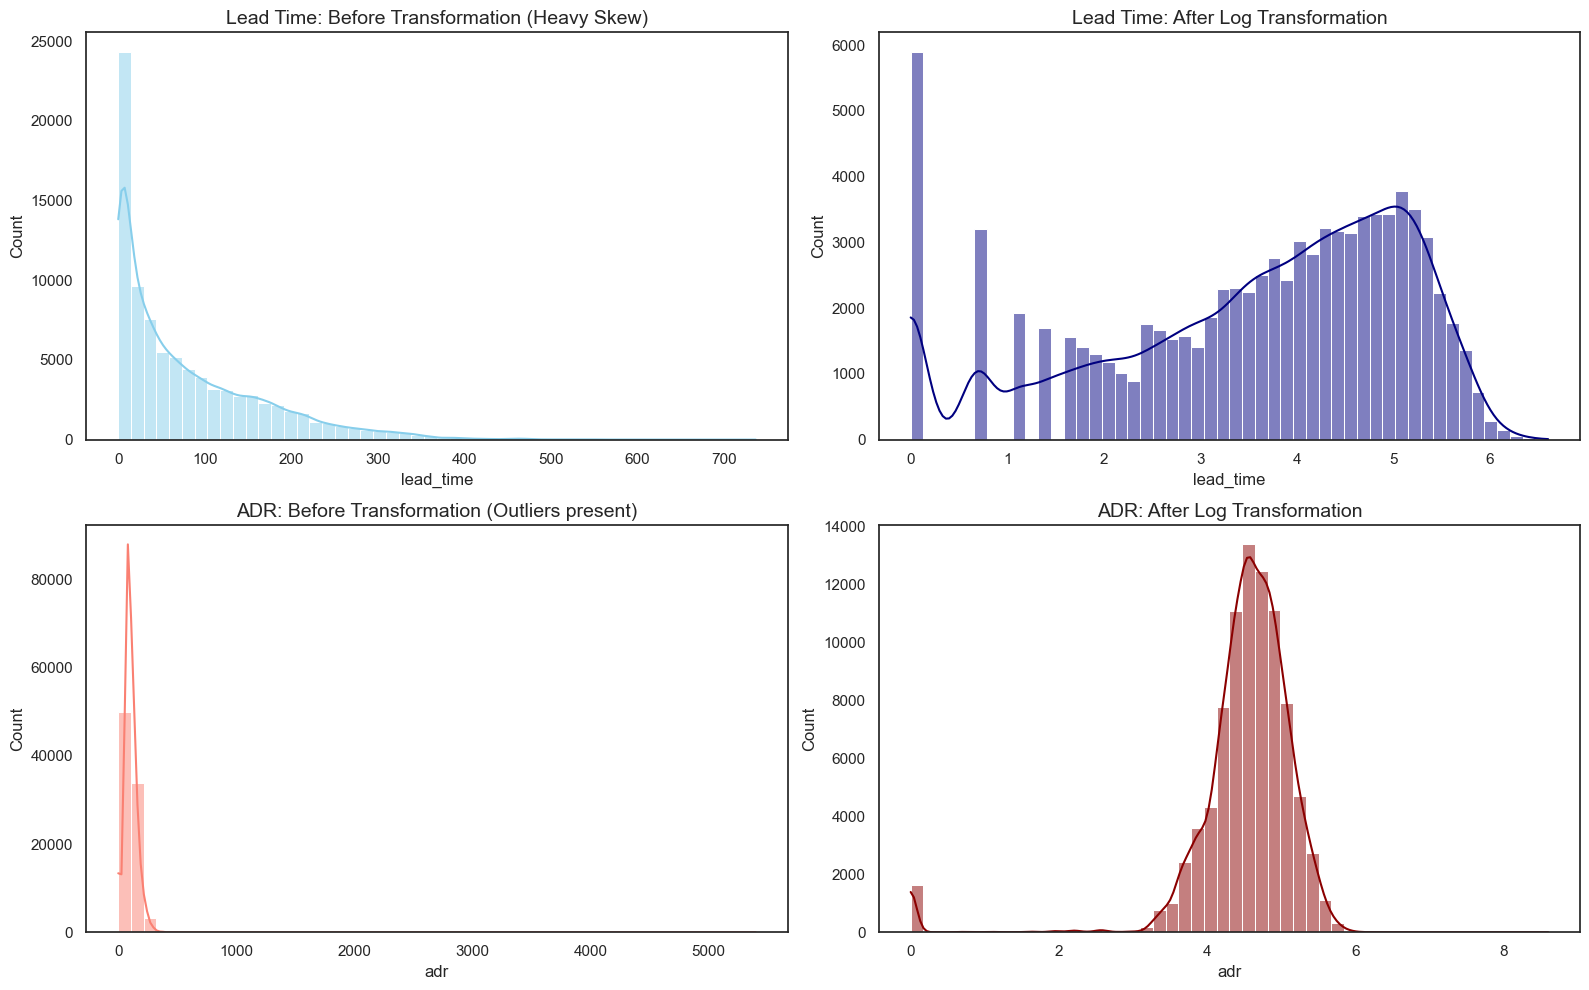

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(df["lead_time"], bins=50, kde=True, ax=axes[0, 0], color="skyblue")
axes[0, 0].set_title("Lead Time: Before Transformation (Heavy Skew)")

sns.histplot(df_eda_transformed["lead_time"], bins=50, kde=True, ax=axes[0, 1], color="navy")
axes[0, 1].set_title("Lead Time: After Log Transformation")

sns.histplot(df["adr"], bins=50, kde=True, ax=axes[1, 0], color="salmon")
axes[1, 0].set_title("ADR: Before Transformation (Outliers present)")

sns.histplot(df_eda_transformed["adr"], bins=50, kde=True, ax=axes[1, 1], color="darkred")
axes[1, 1].set_title("ADR: After Log Transformation")

plt.tight_layout()
plt.show()


**Observations:** 
* The log transformation has converted the "exponential" decay of `lead_time` into a more normal distribution. This reduces the risk of the model over-weighting a few high-lead-time bookings.

* The log transformation has compressed the range of the ADR values. The extreme outliers, most notably the 5,400.00 record, which previously sat thousands of units away from the mean, are now mathematically brought closer to the rest of the distribution.

<a id="sec-7-2"></a>
### 7.2 Analysis of Engineered Features and Historical Signals
We verify whether the pipeline-engineered features (`parking_required`, `is_family`, `total_stay_nights`) and retained historical booking fields (`previous_cancellations`, `previous_bookings_not_canceled`) add interpretable signal for cancellation risk.


C:\Users\chunj\AppData\Local\Temp\ipykernel_6796\2489045563.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\chunj\AppData\Local\Temp\ipykernel_6796\2489045563.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["No Parking", "Parking Required"])
C:\Users\chunj\AppData\Local\Temp\ipykernel_6796\2489045563.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=family_impact.index, y=family_impact.values, ax=axes[1], palette="magma")
C:\Users\chunj\AppData\Local\Temp\ipykernel_6796\2489045563.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of 

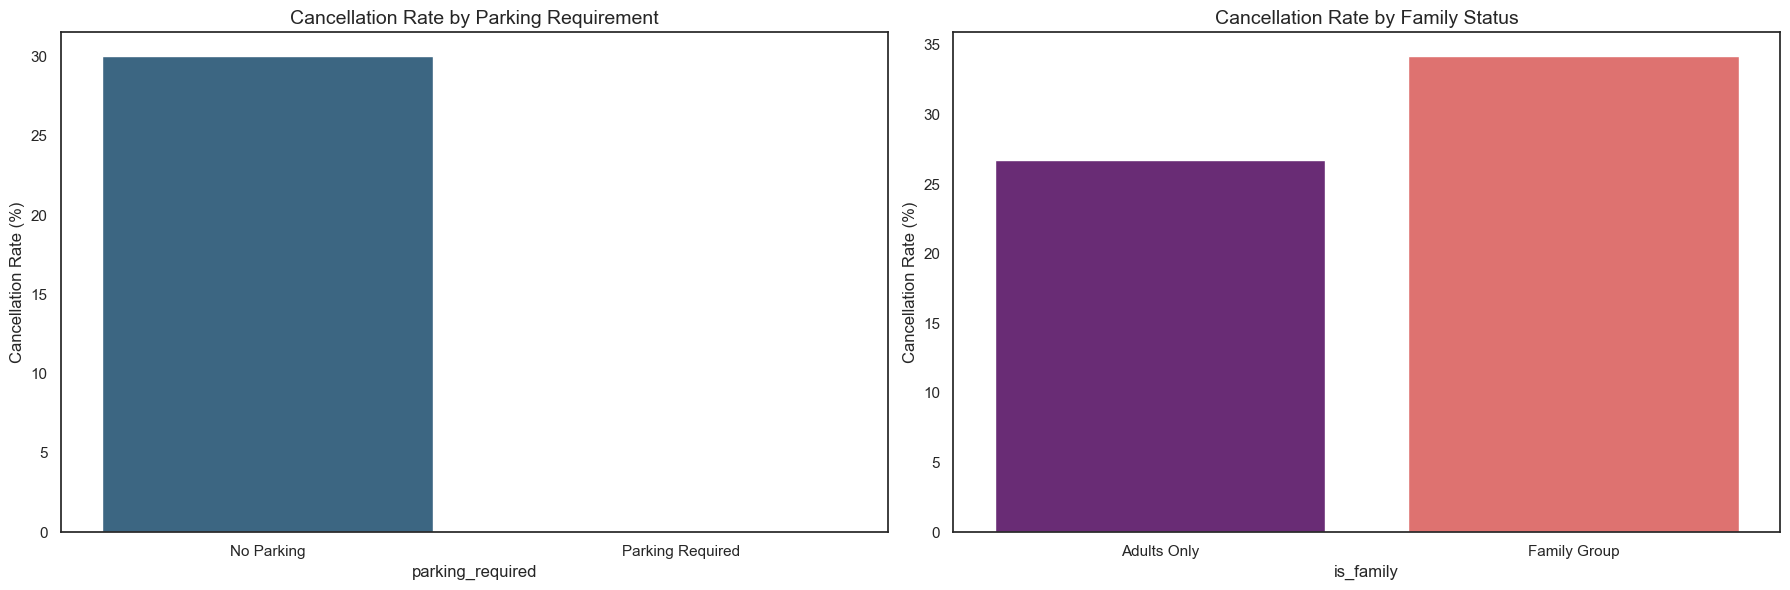

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

parking_impact = df_eda_transformed.groupby("parking_required")["is_cancelled"].mean() * 100
sns.barplot(
    x=parking_impact.index, y=parking_impact.values, ax=axes[0], palette="viridis"
)
axes[0].set_title("Cancellation Rate by Parking Requirement")
axes[0].set_ylabel("Cancellation Rate (%)")
axes[0].set_xticklabels(["No Parking", "Parking Required"])

family_impact = df_eda_transformed.groupby("is_family")["is_cancelled"].mean() * 100
sns.barplot(x=family_impact.index, y=family_impact.values, ax=axes[1], palette="magma")
axes[1].set_title("Cancellation Rate by Family Status")
axes[1].set_ylabel("Cancellation Rate (%)")
axes[1].set_xticklabels(["Adults Only", "Family Group"])

plt.tight_layout()
plt.show()


C:\Users\chunj\AppData\Local\Temp\ipykernel_6796\3729088538.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\chunj\AppData\Local\Temp\ipykernel_6796\3729088538.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Checked-out", "Cancelled"])
C:\Users\chunj\AppData\Local\Temp\ipykernel_6796\3729088538.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\chunj\AppData\Local\Temp\ipykernel_6796\3729088538.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels

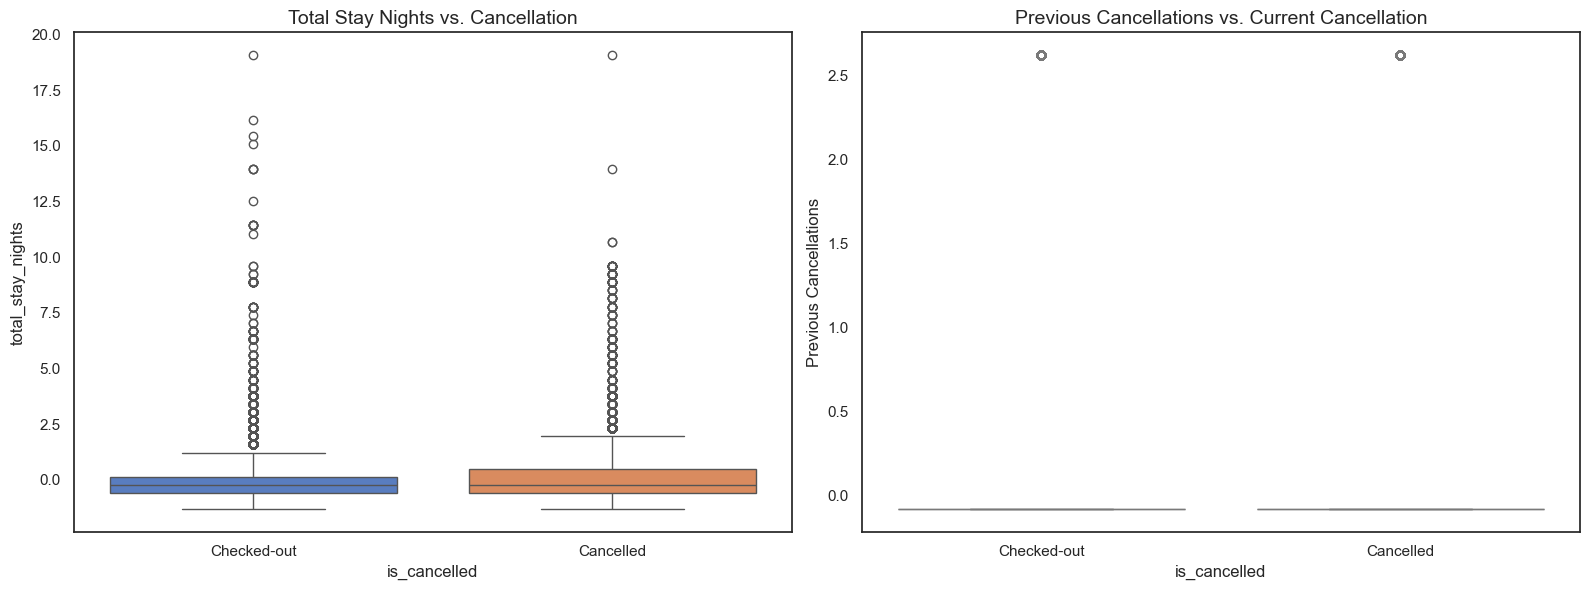

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(
    x="is_cancelled",
    y="total_stay_nights",
    data=df_eda_transformed[df_eda_transformed["total_stay_nights"] < 20],
    ax=axes[0],
    palette="muted",
)
axes[0].set_title("Total Stay Nights vs. Cancellation")
axes[0].set_xticklabels(["Checked-out", "Cancelled"])

sns.boxplot(
    x="is_cancelled",
    y="previous_cancellations",
    data=df_eda_transformed[df_eda_transformed["previous_cancellations"] <= 5],
    ax=axes[1],
    palette="coolwarm",
)
axes[1].set_title("Previous Cancellations vs. Current Cancellation")
axes[1].set_xticklabels(["Checked-out", "Cancelled"])
axes[1].set_ylabel("Previous Cancellations")

plt.tight_layout()
plt.show()


<a id="sec-7-3"></a>
### 7.3 Dimensionality Verification After One-Hot Encoding
We need to verify that our cardinality management (Top 10 Countries) kept the feature space manageable.

C:\Users\chunj\AppData\Local\Temp\ipykernel_6796\2949142361.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_sums.values, y=country_sums.index, palette="magma")


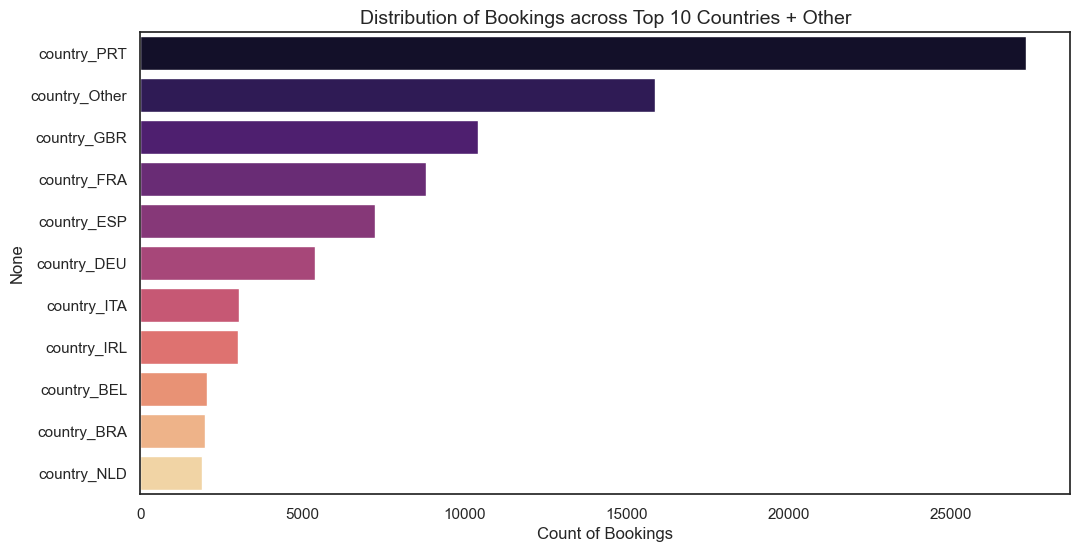

In [41]:
country_cols = [col for col in df_eda_transformed.columns if col.startswith("country_")]
country_sums = df_eda_transformed[country_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=country_sums.values, y=country_sums.index, palette="magma")
plt.title("Distribution of Bookings across Top 10 Countries + Other")
plt.xlabel("Count of Bookings")
plt.show()


**Observation:** The "Other" category is significant but not dominant. This confirms our grouping strategy was effective. We also retained the signals of the most frequent visitors (like PRT, GBR, FRA) while preventing the creation of 160+ sparse columns for rare occurrences.

Quick verification that the EDA-only transformed dataframe has clean numeric dtypes before downstream plots such as PCA and correlation analysis.


In [42]:
df_eda_transformed = df_eda_transformed.apply(pd.to_numeric, errors="coerce")
print(df_eda_transformed.dtypes.value_counts())


float64    51
int64       1
Name: count, dtype: int64


<a id="sec-8"></a>
# 8. Justifying Model Selection with Feature Correlation and Principal Component Analysis (PCA)

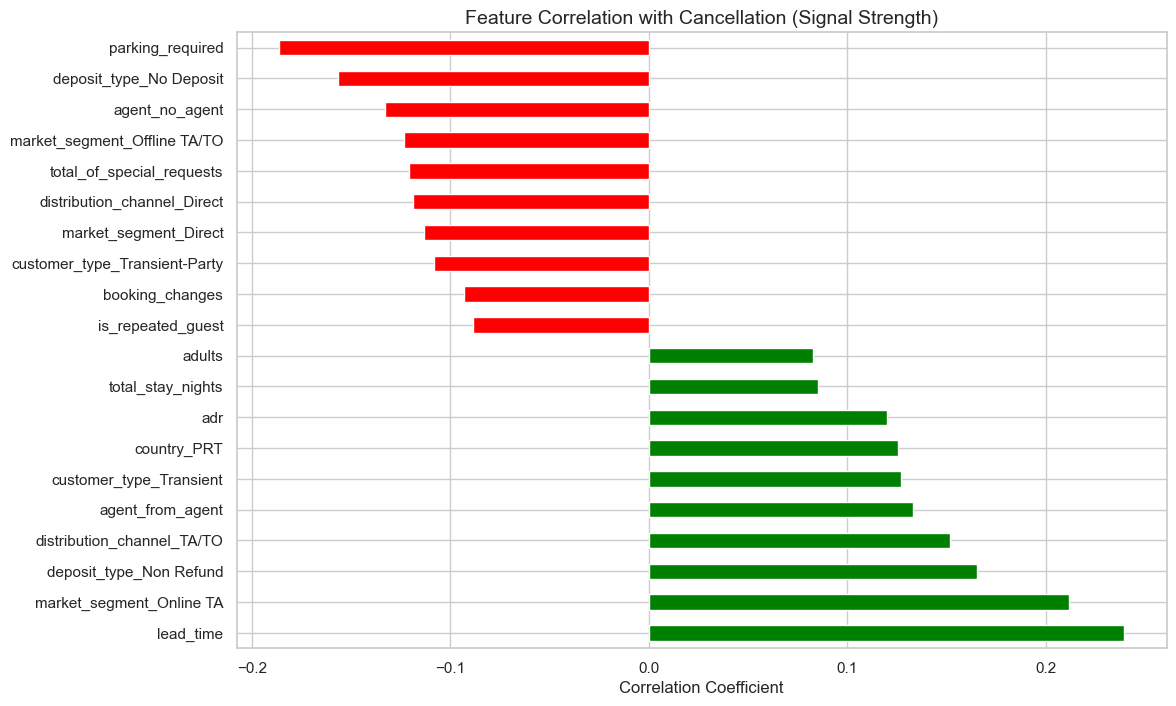

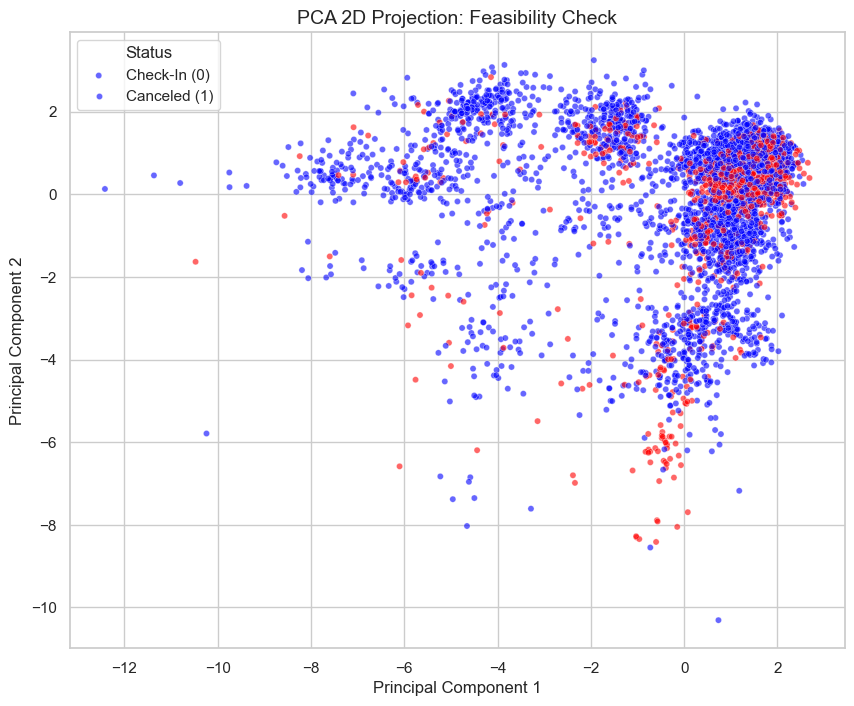

Explained Variance Ratio: [0.11280483 0.06209847]


In [43]:
sns.set_style("whitegrid")

sample_size = min(5000, len(df_eda_transformed))
df_sample = df_eda_transformed.sample(n=sample_size, random_state=42)
X_viz = df_sample.drop("is_cancelled", axis=1).select_dtypes(include=["number"])
y_viz = df_sample["is_cancelled"]

X_viz = X_viz.dropna(axis=1, how="all")
X_viz = X_viz.fillna(X_viz.median(numeric_only=True))

numeric_df = df_eda_transformed.select_dtypes(include=["number"])
correlations = numeric_df.corrwith(numeric_df["is_cancelled"]).sort_values(ascending=False)
correlations = correlations.drop("is_cancelled")

top_corr = pd.concat([correlations.head(10), correlations.tail(10)])

plt.figure(figsize=(12, 8))
top_corr.plot(kind="barh", color=(top_corr > 0).map({True: "green", False: "red"}))
plt.title("Feature Correlation with Cancellation (Signal Strength)")
plt.xlabel("Correlation Coefficient")
plt.show()

scaler_pca = StandardScaler()
X_pca_scaled = scaler_pca.fit_transform(X_viz)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_pca_scaled)

pca_df = pd.DataFrame(data=X_pca, columns=["PC1", "PC2"])
pca_df["Status"] = y_viz.values

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Status",
    palette=["blue", "red"],
    alpha=0.6,
    s=20,
)
plt.title("PCA 2D Projection: Feasibility Check")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Status", labels=["Check-In (0)", "Canceled (1)"])
plt.show()

print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")


<a id="sec-8-1"></a>
### 8.1 Feature Correlation Bar Chart

* **Observation:** The strongest positive signals now come from `deposit_type_Non Refund`, `lead_time`, and the retained historical count fields such as `previous_cancellations`. Strong negative signals include `parking_required`, `total_of_special_requests`, and `is_repeated_guest`.
* **Interpretation:** These correlations align with the earlier bivariate plots and the formal significance tests. `deposit_type_Non Refund` remains a dominant proxy for cancellation risk, while parking demand, repeat-customer behaviour, and special requests continue to mark stronger arrival intent.
* **Action:** Retain these signals in the reusable pipeline and compare a linear model against more flexible ensemble families. The retained history counts are more defensible than a derived historical ratio because they avoid leakage risk while preserving behavioural history.

### 8.2 PCA Scatter Plot

* **Observation:** The 2D projection reveals noticeable overlap between the two classes, even though some local pockets of separation remain visible.
* **Interpretation:** The overlap confirms that a purely linear boundary is unlikely to be sufficient on its own. Logistic Regression remains useful as an interpretable baseline, while Random Forest and HistGradientBoosting are better candidates for learning non-linear interactions.
* **Action:** Use the ordinary validation split as a quick baseline snapshot, then move to 5-fold cross-validation in the later advanced modelling sections for robust family comparison, tuning, and champion selection.

#### 8.2.1 Summary

1. **The data contains real signal:** cancellation is strongly associated with booking policy, booking horizon, guest intent, and historical behaviour.
2. **Preprocessing remains justified:** log transforms and scaling improve numerical stability, while one-hot encoding preserves categorical meaning without imposing false order.
3. **Model family comparison is necessary:** the notebook should compare an interpretable linear baseline against two non-linear ensemble families using the same end-to-end workflow.


<a id="sec-8-2"></a>
### 8.3 Model Selection Strategy

We use one dummy reference model and the same three predictive families that will later appear in the advanced modelling sections.

#### 8.3.1 Dummy Classifier

* **Requirement:** Establish a performance floor under class imbalance.
* **Logic:** The `most_frequent` strategy predicts the majority class for every booking.
* **Role:** It verifies that the trained models are learning genuine cancellation signal rather than merely exploiting the dominant class distribution.

#### 8.3.2 Logistic Regression

* **Rationale from EDA:** `lead_time`, `adr`, deposit policy, and booking-history variables all show structured directional relationships with the target.
* **Role:** Provide the interpretable linear baseline for the project.

#### 8.3.3 Random Forest

* **Rationale from PCA and correlations:** The overlap between cancelled and non-cancelled bookings suggests the problem contains non-linear interactions.
* **Role:** Capture hierarchical interactions such as booking horizon combined with deposit policy, repeat-guest status, or historical behaviour.

#### 8.3.4 HistGradientBoostingClassifier

* **Rationale from the same EDA findings:** The dataset mixes strong main effects with higher-order interactions that may benefit from boosting.
* **Role:** Test whether an additive boosting ensemble can outperform both the linear baseline and the bagging ensemble.

### 8.4 Evaluation Hierarchy

The models are compared using this order of importance:

1. **Recall:** catch enough real cancellations to protect revenue.
2. **F2-score:** optimise the Recall-heavy trade-off.
3. **Precision:** keep false alarms at a manageable operational level.
4. **ROC-AUC / PR diagnostics:** provide threshold-independent context. The models are compared using this order of priority: **Recall** first, then **F2-score**, then **Precision**, then **ROC-AUC** as threshold-independent context. This order reflects the hotel’s business objective — missed cancellations are the most expensive error, so Recall takes precedence over all other metrics.


<a id="sec-9"></a>
# 9. Model Evaluation Strategy

The modelling workflow uses **three distinct data roles**:

* **Training split (70%)**: fit models and run cross-validation.
* **Validation split (15%)**: perform intermediate decision checks after cross-validation, such as baseline sanity checks, ensemble comparison, and threshold calibration.
* **Test split (15%)**: evaluate the **final locked candidate once** for the deployment verdict, error analysis, and business translation.

### Ordinary 70/15/15 Stratified Split

#### What does it do?
The ordinary split gives us a fast, interpretable first look at how the candidate model families behave on unseen data. It is useful for:

* checking that the split is leakage-free,
* benchmarking against a dummy majority-class reference,
* and confirming that the three chosen algorithmic families are viable before the heavier advanced modelling stage begins.

#### Why do we do this first?
It provides a lightweight validation snapshot without pretending to be the final model-selection stage.

### 5-Fold Stratified Cross-Validation

#### What does it do?
Cross-validation is applied **only on the training split**. The model is fit multiple times on different training folds and evaluated on held-out folds, producing a more stable estimate of generalisation than a single split.

#### Why does it come after the ordinary split?
The ordinary split establishes the leak-free hold-out structure; cross-validation then becomes the rigorous comparison and tuning stage for the same three algorithmic families. This avoids using the test set too early while still giving us a quick baseline checkpoint.

### Why F2-score is the primary metric

In this dataset, the hotel loses revenue when real cancellations are missed. Therefore:

* **Recall** is the operational priority,
* **F2-score** is the main optimisation metric because it weights Recall more heavily than Precision,
* **Precision** remains a deployment guardrail so the hotel does not create excessive false alarms.

Throughout the rest of the notebook:

1. the ordinary validation snapshot is a quick diagnostic,
2. k-fold CV is the rigorous model-comparison and tuning stage,
3. the validation split supports intermediate decisions after CV,
4. and the test split is reserved for the final deployment verdict only.


<a id="sec-10"></a>
# 10. Data Preparation with Train, Test, and Validation Split

> ⚠️ **WARNING:** `X_smote_debug` and `y_smote_debug` below are created for display and inspection only. All modelling uses `X_raw_train` through the `ImbPipeline`. Do not pass these variables to any classifier or CV function.

In [44]:
# Split raw cleaned data BEFORE any fit-dependent transformation
X_raw = df_clean.drop("is_cancelled", axis=1).copy()
y = df_clean["is_cancelled"].copy()

X_raw_train, X_raw_temp, y_train, y_temp = train_test_split(
    X_raw, y, test_size=0.30, random_state=42, stratify=y
)
X_raw_val, X_raw_test, y_val, y_test = train_test_split(
    X_raw_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Build the mixed-schema training data that SMOTENC will see
feature_engineer_train = BookingFeatureEngineer(month_map=month_map)
country_grouper_train = TopCountryGrouper(top_n=10)

X_train_pre_smote = feature_engineer_train.transform(X_raw_train.copy())
country_grouper_train.fit(X_train_pre_smote)
X_train_pre_smote = country_grouper_train.transform(X_train_pre_smote)
X_val_pre_smote = country_grouper_train.transform(
    feature_engineer_train.transform(X_raw_val.copy())
)
X_test_pre_smote = country_grouper_train.transform(
    feature_engineer_train.transform(X_raw_test.copy())
)

selected_columns_full = get_selected_feature_order()
X_train_pre_smote = X_train_pre_smote[selected_columns_full].copy()
X_val_pre_smote = X_val_pre_smote[selected_columns_full].copy()
X_test_pre_smote = X_test_pre_smote[selected_columns_full].copy()

cat_features_idx = get_categorical_feature_indices(selected_columns_full)

# Compatibility artifact: resampled raw-mixed training matrix
smote_reference = SMOTENC(
    categorical_features=cat_features_idx,
    random_state=42,
    sampling_strategy=1.0,
)
X_smote_debug, y_smote_debug = smote_reference.fit_resample(
    X_train_pre_smote, y_train
)

# Debug/inspection matrices only - modelling below uses the raw splits + reusable pipelines
preprocessor_debug = build_preprocessor(selected_columns_full)
preprocessor_debug.fit(X_train_pre_smote)
transformed_columns = clean_feature_names(preprocessor_debug.get_feature_names_out())

X_train = pd.DataFrame(
    preprocessor_debug.transform(X_train_pre_smote),
    columns=transformed_columns,
    index=X_raw_train.index,
)
X_val = pd.DataFrame(
    preprocessor_debug.transform(X_val_pre_smote),
    columns=transformed_columns,
    index=X_raw_val.index,
)
X_test = pd.DataFrame(
    preprocessor_debug.transform(X_test_pre_smote),
    columns=transformed_columns,
    index=X_raw_test.index,
)

def build_model_pipeline(
    clf,
    *,
    use_smote=False,
    include_engineered=True,
    include_history=True,
    include_deposit=True,
):
    selected_columns = get_selected_feature_order(
        include_engineered=include_engineered,
        include_history=include_history,
        include_deposit=include_deposit,
    )

    steps = [
        ("feature_engineering", BookingFeatureEngineer(month_map=month_map)),
        ("country_grouping", TopCountryGrouper(top_n=10)),
        ("feature_selection", FeatureSelector(selected_columns)),
    ]

    if use_smote:
        steps.append(
            (
                "smote",
                SMOTENC(
                    categorical_features=get_categorical_feature_indices(selected_columns),
                    random_state=42,
                    sampling_strategy=1.0,
                ),
            )
        )

    steps.extend(
        [
            ("preprocessor", build_preprocessor(selected_columns)),
            ("clf", clf),
        ]
    )

    if use_smote:
        return ImbPipeline(steps)
    return Pipeline(steps)

print(f"Training split:   {X_raw_train.shape[0]} rows")
print(f"Validation split: {X_raw_val.shape[0]} rows")
print(f"Test split:       {X_raw_test.shape[0]} rows")
print(f"Compatibility resampled training shape: {X_smote_debug.shape}")
print(f"Number of categorical indices for SMOTENC: {len(cat_features_idx)}")
print(f"Inspection matrix shape (X_train): {X_train.shape}")


Training split:   60902 rows
Validation split: 13051 rows
Test split:       13051 rows
Compatibility resampled training shape: (88306, 21)
Number of categorical indices for SMOTENC: 11
Inspection matrix shape (X_train): (60902, 51)


<a id="sec-11"></a>
# 11. Model Development

In [45]:
baseline_models = {
    "Dummy Classifier": build_model_pipeline(
        DummyClassifier(strategy="most_frequent"), use_smote=False
    ),
    "Logistic Regression": build_model_pipeline(
        LogisticRegression(max_iter=2000, random_state=42), use_smote=False
    ),
    "Random Forest": build_model_pipeline(
        RandomForestClassifier(
            n_estimators=200, random_state=42, class_weight="balanced"
        ),
        use_smote=False,
    ),
    "HistGradientBoosting": build_model_pipeline(
        HistGradientBoostingClassifier(random_state=42), use_smote=False
    ),
}

trained_baseline_models = {}
for name, model in baseline_models.items():
    print(f"Training {name} baseline pipeline...")
    fitted_model = clone(model)
    fitted_model.fit(X_raw_train, y_train)
    trained_baseline_models[name] = fitted_model

print("\nBaseline validation snapshot models fitted successfully.")


Training Dummy Classifier baseline pipeline...
Training Logistic Regression baseline pipeline...
Training Random Forest baseline pipeline...
Training HistGradientBoosting baseline pipeline...

Baseline validation snapshot models fitted successfully.


<a id="sec-12"></a>
# 12. Baseline Validation Snapshot Metrics

The baseline snapshot uses the same three algorithmic families we carry through to the advanced sections. The goal here is not final model selection — it is a quick sanity check on the validation set before we move into rigorous cross-validation and tuning.

### Accuracy, Precision, Recall, and F2-Score
| Metric | Definition | Role in this project |
| :--- | :--- | :--- |
| **Accuracy** | Proportion of total predictions that are correct. | Secondary reference only; it is misleading on this imbalanced dataset. |
| **Precision** | Of all predicted cancellations, how many are truly cancelled? | Operational guardrail to limit unnecessary interventions. |
| **Recall** | Of all actual cancellations, how many were correctly identified? | Most important operational metric because missed cancellations directly cost revenue. |
| **F2-Score** | Recall-weighted harmonic mean of Precision and Recall. | **Primary optimisation metric** from baseline modelling onward. |

### Threshold-Independent Diagnostics

* **ROC-AUC:** useful for comparing general ranking ability.
* **Average Precision / PR Curve:** useful for understanding positive-class performance under class imbalance.

The ordinary validation snapshot reports these metrics on the 15% validation split. The more rigorous family comparison, tuning, and champion selection happen later through 5-fold CV on the training split only.

<a id="sec-12-0-1"></a>
#### Why Recall and F2 matter more than raw Accuracy

In the hotel booking setting, a **False Negative** means the hotel fails to identify a booking that will cancel. That is the most expensive mistake because the room may go unsold and the revenue opportunity is lost. A **False Positive** creates unnecessary follow-up work and may inconvenience genuine guests, so Precision still matters.

This is why the project uses the following hierarchy:

1. **Recall** is the operational priority.
2. **F2-score** is the primary optimisation metric because it weights Recall more heavily than Precision.
3. **Precision** is a guardrail that prevents the workflow from becoming operationally noisy.

The baseline snapshot is therefore interpreted with the same deployment criteria used later in the later advanced modelling sections:

* `Recall >= 0.75`
* `F2 >= 0.64`
* `Precision >= 0.50`


<a id="sec-13"></a>
# 13. Baseline Ordinary-Split Snapshot (Validation Set)


In [46]:
def get_positive_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    return model.predict(X)

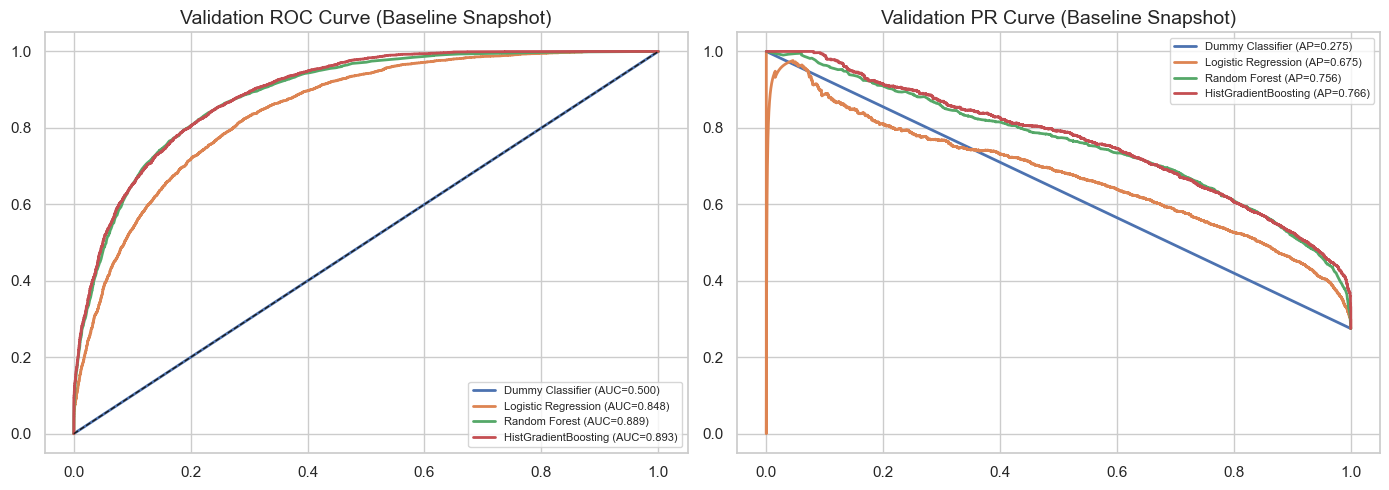

,Model,Val_Accuracy,Val_Precision,Val_Recall,Val_F2,Val_ROC_AUC,Recall_Gate_Pass,Precision_Gate_Pass
0,Random Forest,0.8314,0.7332,0.6086,0.6300,0.8886,False,True
1,HistGradientBoosting,0.8333,0.7401,0.6070,0.6296,0.8929,False,True
2,Logistic Regression,0.7992,0.6895,0.4916,0.5216,0.8476,False,True
3,Dummy Classifier,0.7249,0.0000,0.0000,0.0000,0.5000,False,False


In [47]:
def sort_by_eval_priority(
    df,
    recall_col,
    f2_col,
    precision_col,
    roc_auc_col,
    gate_col=None,
    threshold_col=None,
):
    sort_cols = []
    ascending = []

    if gate_col is not None and gate_col in df.columns:
        sort_cols.append(gate_col)
        ascending.append(False)

    sort_cols.extend([recall_col, f2_col, precision_col, roc_auc_col])
    ascending.extend([False, False, False, False])

    if threshold_col is not None and threshold_col in df.columns:
        sort_cols.append(threshold_col)
        ascending.append(False)

    return df.sort_values(sort_cols, ascending=ascending).reset_index(drop=True)


baseline_rows = []
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax_roc, ax_pr = axes

for name, model in trained_baseline_models.items():
    y_pred_val = model.predict(X_raw_val)
    y_score_val = get_positive_scores(model, X_raw_val)

    val_precision = precision_score(y_val, y_pred_val, zero_division=0)
    val_recall = recall_score(y_val, y_pred_val, zero_division=0)
    val_f2 = fbeta_score(y_val, y_pred_val, beta=2, zero_division=0)

    baseline_rows.append(
        {
            "Model": name,
            "Val_Accuracy": accuracy_score(y_val, y_pred_val),
            "Val_Precision": val_precision,
            "Val_Recall": val_recall,
            "Val_F2": val_f2,
            "Val_ROC_AUC": roc_auc_score(y_val, y_score_val),
            "Recall_Gate_Pass": val_recall >= 0.75,
            "Precision_Gate_Pass": val_precision >= 0.50,
        }
    )

    fpr, tpr, _ = roc_curve(y_val, y_score_val)
    ax_roc.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc(fpr, tpr):.3f})")

    precision, recall, _ = precision_recall_curve(y_val, y_score_val)
    ax_pr.plot(
        recall,
        precision,
        lw=2,
        label=f"{name} (AP={average_precision_score(y_val, y_score_val):.3f})",
    )

ax_roc.plot([0, 1], [0, 1], "k--", lw=1)
ax_roc.set_title("Validation ROC Curve (Baseline Snapshot)")
ax_pr.set_title("Validation PR Curve (Baseline Snapshot)")
for ax in axes:
    ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

baseline_results_df = sort_by_eval_priority(
    pd.DataFrame(baseline_rows),
    recall_col="Val_Recall",
    f2_col="Val_F2",
    precision_col="Val_Precision",
    roc_auc_col="Val_ROC_AUC",
).round(4)
display(baseline_results_df)


### 13.1 Baseline Snapshot Findings

The validation snapshot confirms the selected families are viable under the leak-free preprocessing workflow, but the baseline stage is not sufficient for final model selection.

We order the table using the same evaluation hierarchy used throughout: Recall first, then F2, then Precision, then ROC-AUC.

From this run, Random Forest came out slightly ahead at the default threshold — Precision 0.7332, Recall 0.6086, F2 0.6300, ROC-AUC 0.8886. HistGradientBoosting was extremely close behind with a slightly stronger ROC-AUC (0.8929). Logistic Regression lagged on Recall (0.4916) and F2 (0.5216), as expected for a linear model. The Dummy Classifier scored Recall = 0.0 and F2 = 0.0, as it should.

Looking at the ROC and PR curves, both Random Forest and HistGradientBoosting dominate — which supports the view that this problem has meaningful non-linear structure. HistGradientBoosting has the strongest threshold-independent ranking, while Random Forest edges it slightly on default-threshold Recall and F2.

None of the baseline models meets the Recall ≥ 0.75 gate or the F2 ≥ 0.64 gate, so the snapshot functions as a ranking signal rather than evidence of deployment readiness. This is why the workflow continues into cross-validation, SMOTENC-based imbalance handling, and hyperparameter tuning.

<a id="sec-14"></a>
# 14. Preparing the Leak-Free Imbalance-Handling Workflow

The baseline snapshot deliberately avoids resampling so it can serve as a clean reference. In the advanced sections, we introduce imbalance handling through **SMOTENC** — but only inside cross-validation and inside model pipelines, never outside.

Before entering the later advanced modelling sections, we lock the SMOTENC design choices that will be reused consistently:

### 14.1 Starting Point: 50/50 Class Balance
For this hotel dataset, a 1:1 ratio between cancellations and non-cancellations is an appropriate starting point because the baseline snapshot typically shows that Recall is under-served without rebalancing.

#### Why SMOTENC?
* The data contains a mix of continuous/count features and categorical features.
* Synthetic samples must preserve valid category combinations.
* SMOTENC will be applied **after raw feature engineering and train-only country grouping, but before one-hot encoding**.

#### Why inside the pipeline?
* Placing it inside the pipeline prevents leakage — synthetic samples are only generated from training folds, never from validation or test data.
* It keeps the earlier and later workflow sections consistent: the same reusable pipeline object handles feature engineering, grouping, resampling, encoding, and modelling.

In [48]:
print("SMOTENC compatibility artifacts for the advanced modelling sections")
print(f"Full selected feature order: {selected_columns_full}")
print(f"Categorical feature indices: {cat_features_idx}")
print(f"Resampled class distribution: {y_smote_debug.value_counts().to_dict()}")


SMOTENC compatibility artifacts for the advanced modelling sections
Full selected feature order: ['hotel', 'lead_time', 'arrival_month_num', 'adults', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'deposit_type', 'agent', 'days_in_waiting_list', 'customer_type', 'adr', 'total_of_special_requests', 'parking_required', 'total_stay_nights', 'is_family']
Categorical feature indices: [0, 4, 5, 6, 7, 8, 12, 13, 15, 18, 20]
Resampled class distribution: {0: 44153, 1: 44153}


The variables above are compatibility artifacts for the later cells (`X_smote_debug`, `y_smote_debug`, `cat_features_idx`), but the **rigorous** modelling workflow below will always fit SMOTENC inside each training fold through reusable pipelines.


In [49]:
f2_scorer = make_scorer(fbeta_score, beta=2, pos_label=1)
skf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Advanced modelling handoff ready:")
print("- F2 scorer initialised")
print("- 5-fold stratified CV initialised")
print("- Raw training split will be the only input to CV/tuning")


Advanced modelling handoff ready:
- F2 scorer initialised
- 5-fold stratified CV initialised
- Raw training split will be the only input to CV/tuning


<a id="sec-14-1"></a>
### 14.2 Baseline Handoff into Advanced Modelling

The baseline snapshot established three facts:

* the project should optimise **F2-score**, not Accuracy and not F1,
* the same three algorithmic families should be carried forward into the advanced workflow,
* and imbalance handling must be introduced through train-only pipeline steps rather than ad-hoc resampling outside CV.

From here, the advanced sections continue with the same families, the same leak-free preprocessing design, and a stricter CV-first selection framework.

<a id="sec-15"></a>
# 15. Transition to Advanced Modelling


In [50]:
X_raw_train_val = pd.concat([X_raw_train, X_raw_val], axis=0).sort_index()
y_train_val = pd.concat([y_train, y_val], axis=0).sort_index()

print(f"Combined train+validation rows for final refit: {X_raw_train_val.shape[0]}")


Combined train+validation rows for final refit: 73953


> **Transition note:** the earlier sections established the leak-free split, reusable preprocessing logic, baseline validation snapshot, and the F2-driven evaluation framework. Sections 17.1–21 below continue with the **same three algorithmic families** and the **same raw-feature pipeline design**, so the workflow reads as one end-to-end project rather than two disconnected analyses.

<a id="sec-16"></a>
# 16. Transition Summary

At this point the notebook has already completed:

* business success criteria with deployment gates,
* raw EDA and formal statistical testing,
* deterministic data cleaning before split,
* reusable pipeline-based preprocessing design,
* and a baseline validation snapshot across the same families used in the later advanced modelling sections.

From here, the notebook moves into rigorous cross-validation, tuning, ensembling, ablation, error analysis, and business translation.

---

# 17. Advanced Modelling, Evaluation, and Business Translation

*This section picks up directly from the earlier sections, reusing the same raw splits, preprocessing design, F2-first evaluation logic, and SMOTENC configuration. The key artefacts carried forward are: `X_raw_train`, `X_raw_val`, `X_raw_test`, `y_train`, `y_val`, `y_test`, `X_smote_debug`, `y_smote_debug`, `skf_cv`, `f2_scorer`, and `cat_features_idx`.*

In [51]:
# --- Additional imports for the advanced modelling sections (kept separate for readability) ---
from sklearn.ensemble import VotingClassifier, StackingClassifier
import warnings
warnings.filterwarnings("ignore")
import copy


## 17.1 Compare 2–3 Distinct Algorithmic Families

This section gives a rigorous comparison of the same three algorithmic families using **5-Fold Stratified Cross-Validation on the training split only**.

| Family | Model |
|---|---|
| Linear | Logistic Regression |
| Ensemble (Bagging) | Random Forest |
| Ensemble (Boosting) | HistGradientBoostingClassifier |

### Why F2-score as the primary metric?

False Negatives are the highest-cost mistake because an actual cancelled booking predicted as not cancelled prevents the hotel from reacting in time. Therefore:

* **Recall** is the operational priority,
* **F2-score** is the main optimisation metric,
* **Precision** remains an operational guardrail.

This is the same logic established in the earlier sections, now applied through a more rigorous CV-based comparison. These three families were chosen because they represent structurally distinct approaches to learning — a linear boundary (Logistic Regression), variance reduction through parallel trees (Random Forest), and sequential error correction through boosting (HistGradientBoosting).


In [52]:
# 17.1: Family comparison with 5-fold CV on the training split only
candidate_models = {
    "Logistic Regression": build_model_pipeline(
        LogisticRegression(max_iter=2000, random_state=42),
        use_smote=True,
    ),
    "Random Forest": build_model_pipeline(
        RandomForestClassifier(
            n_estimators=200, random_state=42, class_weight="balanced"
        ),
        use_smote=True,
    ),
    "HistGradientBoosting": build_model_pipeline(
        HistGradientBoostingClassifier(random_state=42),
        use_smote=True,
    ),
}

comparison_rows = []
for name, pipe in candidate_models.items():
    cv_results = cross_validate(
        pipe,
        X_raw_train,
        y_train,
        cv=skf_cv,
        scoring={
            "f2": f2_scorer,
            "recall": "recall",
            "precision": "precision",
            "roc_auc": "roc_auc",
        },
        return_train_score=False,
        n_jobs=-1,
    )
    recall_mean = round(cv_results["test_recall"].mean(), 4)
    precision_mean = round(cv_results["test_precision"].mean(), 4)
    comparison_rows.append(
        {
            "Model": name,
            "CV_F2_Mean": round(cv_results["test_f2"].mean(), 4),
            "CV_F2_Std": round(cv_results["test_f2"].std(), 4),
            "CV_Recall_Mean": recall_mean,
            "CV_Precision_Mean": precision_mean,
            "CV_ROC_AUC_Mean": round(cv_results["test_roc_auc"].mean(), 4),
            "Recall_Gate_Pass": recall_mean >= 0.75,
            "Precision_Gate_Pass": precision_mean >= 0.50,
        }
    )

task7_results_df = sort_by_eval_priority(
    pd.DataFrame(comparison_rows),
    recall_col="CV_Recall_Mean",
    f2_col="CV_F2_Mean",
    precision_col="CV_Precision_Mean",
    roc_auc_col="CV_ROC_AUC_Mean",
)
display(task7_results_df)


,Model,CV_F2_Mean,CV_F2_Std,CV_Recall_Mean,CV_Precision_Mean,CV_ROC_AUC_Mean,Recall_Gate_Pass,Precision_Gate_Pass
0,HistGradientBoosting,0.7047,0.0037,0.7294,0.6207,0.8758,False,True
1,Logistic Regression,0.6772,0.0051,0.7146,0.5600,0.8336,False,True
2,Random Forest,0.6913,0.0047,0.7036,0.6463,0.8759,False,True


### 17.1.1 Findings

The CV stage gives a cleaner comparison than the single validation snapshot.

HistGradientBoosting came out strongest overall — CV_Recall_Mean = 0.7294, CV_F2_Mean = 0.7047, CV_Precision_Mean = 0.6207, CV_ROC_AUC_Mean = 0.8758. Interestingly, Logistic Regression ranked ahead of Random Forest under our Recall-first rule because its average Recall was higher (0.7146 vs 0.7036), even though its F2 and Precision were weaker. Random Forest remains a credible second because it offers stronger Precision (0.6463) and a similar ROC-AUC (0.8759).

Compared to the baseline snapshot, where Random Forest and HistGradientBoosting looked nearly tied, the CV stage breaks that tie clearly in favour of HistGradientBoosting. It also shows that the middle ranking between Logistic Regression and Random Forest depends on whether Recall or F2 is prioritised — which is exactly why we declared the hierarchy upfront.

## 17.2 Hyperparameter Tuning

We tune each family under the same end-to-end pipeline. The preprocessing steps, train-only country grouping, SMOTENC, and one-hot encoding all stay inside the pipeline so tuning does not break the leakage controls from the earlier sections.

* **Logistic Regression**: `GridSearchCV`
* **Random Forest**: `RandomizedSearchCV`
* **HistGradientBoosting**: `RandomizedSearchCV`

Scoring metric: **F2-score**

**Observed best tuning results from the current run:**

* **Logistic Regression** best params: `C = 10.0`, `solver = 'liblinear'`; best CV `F2 = 0.6775`
* **Random Forest** best params: `n_estimators = 350`, `min_samples_split = 2`, `min_samples_leaf = 1`, `max_depth = 20`; best CV `F2 = 0.7082`
* **HistGradientBoosting** best params: `min_samples_leaf = 40`, `max_iter = 300`, `max_depth = 5`, `learning_rate = 0.1`; best CV `F2 = 0.7099`

These tuned estimators are then stored and reused through `build_candidate_pipeline(...)`, which means all later champion-selection, ensemble, ablation, and final-evaluation steps are using the tuned versions rather than reverting to untuned defaults.

In [53]:
# 17.2: Hyperparameter tuning with the same raw-feature ImbPipeline design
lr_search = GridSearchCV(
    build_model_pipeline(
        LogisticRegression(max_iter=2000, random_state=42),
        use_smote=True,
    ),
    param_grid={
        "clf__C": [0.01, 0.1, 1.0, 10.0],
        "clf__solver": ["lbfgs", "liblinear"],
    },
    cv=skf_cv,
    scoring=f2_scorer,
    n_jobs=-1,
    verbose=0,
)
lr_search.fit(X_raw_train, y_train)

rf_search = RandomizedSearchCV(
    build_model_pipeline(
        RandomForestClassifier(random_state=42, class_weight="balanced"),
        use_smote=True,
    ),
    param_distributions={
        "clf__n_estimators": [150, 250, 350],
        "clf__max_depth": [None, 10, 20, 30],
        "clf__min_samples_split": [2, 5, 10],
        "clf__min_samples_leaf": [1, 2, 4],
    },
    n_iter=20,
    cv=skf_cv,
    scoring=f2_scorer,
    random_state=42,
    n_jobs=-1,
    verbose=0,
)
rf_search.fit(X_raw_train, y_train)

hgbc_search = RandomizedSearchCV(
    build_model_pipeline(
        HistGradientBoostingClassifier(random_state=42),
        use_smote=True,
    ),
    param_distributions={
        "clf__max_iter": [100, 200, 300],
        "clf__learning_rate": [0.03, 0.05, 0.1, 0.2],
        "clf__max_depth": [None, 3, 5, 7],
        "clf__min_samples_leaf": [20, 40, 60],
    },
    n_iter=20,
    cv=skf_cv,
    scoring=f2_scorer,
    random_state=42,
    n_jobs=-1,
    verbose=0,
)
hgbc_search.fit(X_raw_train, y_train)

lr_best_pipeline = copy.deepcopy(lr_search.best_estimator_)
rf_best_pipeline = copy.deepcopy(rf_search.best_estimator_)
hgbc_best_pipeline = copy.deepcopy(hgbc_search.best_estimator_)

lr_best_clf = copy.deepcopy(lr_best_pipeline.named_steps["clf"])
rf_best_clf = copy.deepcopy(rf_best_pipeline.named_steps["clf"])
hgbc_best_clf = copy.deepcopy(hgbc_best_pipeline.named_steps["clf"])

print("Best LR params:", {k.replace("clf__", ""): v for k, v in lr_search.best_params_.items()})
print(f"Best LR CV F2: {lr_search.best_score_:.4f}")
print("Best RF params:", {k.replace("clf__", ""): v for k, v in rf_search.best_params_.items()})
print(f"Best RF CV F2: {rf_search.best_score_:.4f}")
print("Best HGBC params:", {k.replace("clf__", ""): v for k, v in hgbc_search.best_params_.items()})
print(f"Best HGBC CV F2: {hgbc_search.best_score_:.4f}")

def build_candidate_pipeline(
    candidate_name,
    *,
    use_smote=True,
    include_engineered=True,
    include_history=True,
    include_deposit=True,
):
    if candidate_name == "Logistic Regression (Tuned)":
        return build_model_pipeline(
            copy.deepcopy(lr_best_clf),
            use_smote=use_smote,
            include_engineered=include_engineered,
            include_history=include_history,
            include_deposit=include_deposit,
        )
    if candidate_name == "Random Forest (Tuned)":
        return build_model_pipeline(
            copy.deepcopy(rf_best_clf),
            use_smote=use_smote,
            include_engineered=include_engineered,
            include_history=include_history,
            include_deposit=include_deposit,
        )
    if candidate_name == "HistGradientBoosting (Tuned)":
        return build_model_pipeline(
            copy.deepcopy(hgbc_best_clf),
            use_smote=use_smote,
            include_engineered=include_engineered,
            include_history=include_history,
            include_deposit=include_deposit,
        )
    if candidate_name == "VotingClassifier (soft)":
        return VotingClassifier(
            estimators=[
                ("lr", build_candidate_pipeline(
                    "Logistic Regression (Tuned)",
                    use_smote=use_smote,
                    include_engineered=include_engineered,
                    include_history=include_history,
                    include_deposit=include_deposit,
                )),
                ("rf", build_candidate_pipeline(
                    "Random Forest (Tuned)",
                    use_smote=use_smote,
                    include_engineered=include_engineered,
                    include_history=include_history,
                    include_deposit=include_deposit,
                )),
                ("hgbc", build_candidate_pipeline(
                    "HistGradientBoosting (Tuned)",
                    use_smote=use_smote,
                    include_engineered=include_engineered,
                    include_history=include_history,
                    include_deposit=include_deposit,
                )),
            ],
            voting="soft",
        )
    if candidate_name == "StackingClassifier":
        return StackingClassifier(
            estimators=[
                ("rf", build_candidate_pipeline(
                    "Random Forest (Tuned)",
                    use_smote=use_smote,
                    include_engineered=include_engineered,
                    include_history=include_history,
                    include_deposit=include_deposit,
                )),
                ("hgbc", build_candidate_pipeline(
                    "HistGradientBoosting (Tuned)",
                    use_smote=use_smote,
                    include_engineered=include_engineered,
                    include_history=include_history,
                    include_deposit=include_deposit,
                )),
            ],
            final_estimator=LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42,
            ),
            cv=3,
            n_jobs=-1,
        )
    raise ValueError(f"Unknown candidate: {candidate_name}")


Best LR params: {'C': 10.0, 'solver': 'liblinear'}
Best LR CV F2: 0.6775
Best RF params: {'n_estimators': 350, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}
Best RF CV F2: 0.7082
Best HGBC params: {'min_samples_leaf': 40, 'max_iter': 300, 'max_depth': 5, 'learning_rate': 0.1}
Best HGBC CV F2: 0.7099


## 17.3 Post-Tuning k-Fold Cross-Validation and Champion Selection

We re-evaluate the tuned pipelines with the same 5-fold CV so everything is compared on equal footing after tuning. The ranking order is the same as before — Recall first, then F2, then Precision, then ROC-AUC. The test set is still untouched at this point; the champion comes from CV only.

**Observed post-tuning CV results:**

* **HistGradientBoosting (Tuned)** ranked first with `CV_Recall_Mean = 0.7355`, `CV_F2_Mean = 0.7099`, `CV_Precision_Mean = 0.6232`, and `CV_ROC_AUC_Mean = 0.8774`.
* **Random Forest (Tuned)** ranked second with `CV_Recall_Mean = 0.7310`, `CV_F2_Mean = 0.7082`, `CV_Precision_Mean = 0.6298`, and `CV_ROC_AUC_Mean = 0.8771`.
* **Logistic Regression (Tuned)** ranked third with `CV_Recall_Mean = 0.7149`, `CV_F2_Mean = 0.6775`, `CV_Precision_Mean = 0.5602`, and `CV_ROC_AUC_Mean = 0.8338`.

None of the tuned models clears the `Recall >= 0.75` gate at the CV stage, but all three satisfy the Precision guardrail on average. So further validation-stage threshold checks are still needed even after tuning.

In [54]:
tuned_model_names = [
    "Logistic Regression (Tuned)",
    "Random Forest (Tuned)",
    "HistGradientBoosting (Tuned)",
]

tuned_rows = []
tuned_pipelines = {}
for name in tuned_model_names:
    pipe = build_candidate_pipeline(name, use_smote=True)
    tuned_pipelines[name] = pipe
    cv_res = cross_validate(
        pipe,
        X_raw_train,
        y_train,
        cv=skf_cv,
        scoring={
            "f2": f2_scorer,
            "recall": "recall",
            "precision": "precision",
            "roc_auc": "roc_auc",
        },
        n_jobs=-1,
    )
    recall_mean = round(cv_res["test_recall"].mean(), 4)
    precision_mean = round(cv_res["test_precision"].mean(), 4)
    tuned_rows.append(
        {
            "Model": name,
            "CV_F2_Mean": round(cv_res["test_f2"].mean(), 4),
            "CV_F2_Std": round(cv_res["test_f2"].std(), 4),
            "CV_Recall_Mean": recall_mean,
            "CV_Precision_Mean": precision_mean,
            "CV_ROC_AUC_Mean": round(cv_res["test_roc_auc"].mean(), 4),
            "Recall_Gate_Pass": recall_mean >= 0.75,
            "Precision_Gate_Pass": precision_mean >= 0.50,
        }
    )

tuned_cv_df = sort_by_eval_priority(
    pd.DataFrame(tuned_rows),
    recall_col="CV_Recall_Mean",
    f2_col="CV_F2_Mean",
    precision_col="CV_Precision_Mean",
    roc_auc_col="CV_ROC_AUC_Mean",
)
display(tuned_cv_df)

champion_name = tuned_cv_df.iloc[0]["Model"]
champion_pipeline = build_candidate_pipeline(champion_name, use_smote=True)
champion_pipeline.fit(X_raw_train, y_train)
print(f"Champion selected from post-tuning CV: {champion_name}")
print("Champion selection order: Recall -> F2-score -> Precision -> ROC-AUC")


,Model,CV_F2_Mean,CV_F2_Std,CV_Recall_Mean,CV_Precision_Mean,CV_ROC_AUC_Mean,Recall_Gate_Pass,Precision_Gate_Pass
0,HistGradientBoosting (Tuned),0.7099,0.0061,0.7355,0.6232,0.8774,False,True
1,Random Forest (Tuned),0.7082,0.0050,0.7310,0.6298,0.8771,False,True
2,Logistic Regression (Tuned),0.6775,0.0054,0.7149,0.5602,0.8338,False,True


Champion selected from post-tuning CV: HistGradientBoosting (Tuned)
Champion selection order: Recall -> F2-score -> Precision -> ROC-AUC


In [55]:
# Inspect the final champion pipeline structure
print(f"Champion: {champion_name}\n")
for step_name, step_obj in champion_pipeline.steps:
    print(f"  Step: {step_name}")
    print(f"  Object: {step_obj}\n")

Champion: HistGradientBoosting (Tuned)

  Step: feature_engineering
  Object: BookingFeatureEngineer(month_map={'April': 4, 'August': 8, 'December': 12,
                                  'February': 2, 'January': 1, 'July': 7,
                                  'June': 6, 'March': 3, 'May': 5,
                                  'November': 11, 'October': 10,
                                  'September': 9})

  Step: country_grouping
  Object: TopCountryGrouper()

  Step: feature_selection
  Object: FeatureSelector(selected_columns=['hotel', 'lead_time', 'arrival_month_num',
                                  'adults', 'meal', 'country', 'market_segment',
                                  'distribution_channel', 'is_repeated_guest',
                                  'previous_cancellations',
                                  'previous_bookings_not_canceled',
                                  'booking_changes', 'deposit_type', 'agent',
                                  'days_in_waiting_lis

### 17.3.1 Champion Model Handoff

The champion is selected from CV only. The model has earned the right to advance, but it is not yet the final deployment candidate — that only happens after the validation-stage checks below.

From the current run, the champion selected from post-tuning CV is:

* **HistGradientBoosting (Tuned)**

with the following profile:

* `CV_Recall_Mean = 0.7355`
* `CV_F2_Mean = 0.7099`
* `CV_Precision_Mean = 0.6232`
* `CV_ROC_AUC_Mean = 0.8774`

This handoff follows the notebook's explicit evaluation hierarchy:

1. **Recall** is prioritised first because missed cancellations are the primary business risk.
2. **F2-score** is used next to preserve the Recall-heavy trade-off.
3. **Precision** remains the false-alarm guardrail.
4. **ROC-AUC** is retained as threshold-independent diagnostic context rather than as the main selection criterion.

The tuned champion is then passed into the later stages through `champion_name` and `champion_pipeline`. In the current run, that means the subsequent ensemble comparison starts from **HistGradientBoosting (Tuned)**, and the later final lock/refit stage also remains consistent with that champion unless an ensemble clears the declared complexity-improvement rule.

## 17.4 Validation-Stage Ensemble Comparison

We test two ensemble strategies as challengers to the tuned champion on the validation split:

1. **VotingClassifier (soft)** : averages predicted probabilities across the three tuned model families.
2. **StackingClassifier** : uses tuned non-linear base learners with a Logistic Regression meta-learner.

This comparison happens on the **validation split**, not the test split. The key fix in this section is **threshold consistency**:

* each candidate is evaluated using its **validation probabilities**, not only the default `predict()` output;
* each candidate receives its own validation operating threshold;
* the selected threshold is the **highest threshold that still satisfies** the business gates of `Recall >= 0.75` and `Precision >= 0.50`.

The earlier problem was that a model could look strong at the default threshold but produce an unrealistic confusion matrix when a much lower threshold was applied later on the test set.

In [56]:
# 17.4: Fit champion + ensemble challengers on the training split and compare on validation
def select_operating_threshold(
    y_true,
    y_proba,
    threshold_grid,
    recall_floor=0.75,
    precision_floor=0.50,
):
    y_true_array = np.asarray(y_true, dtype=int)
    actual_positive_rate = y_true_array.mean()
    threshold_rows = []

    for threshold in threshold_grid:
        y_pred = (y_proba >= threshold).astype(int)
        precision = precision_score(y_true_array, y_pred, zero_division=0)
        recall = recall_score(y_true_array, y_pred, zero_division=0)
        f2 = fbeta_score(y_true_array, y_pred, beta=2, zero_division=0)
        predicted_positive_rate = y_pred.mean()

        threshold_rows.append(
            {
                "threshold": threshold,
                "precision": precision,
                "recall": recall,
                "f2": f2,
                "predicted_positive_rate": predicted_positive_rate,
                "actual_positive_rate": actual_positive_rate,
                "rate_gap": abs(predicted_positive_rate - actual_positive_rate),
            }
        )

    threshold_df = pd.DataFrame(threshold_rows)
    threshold_df["gate_pass"] = (
        (threshold_df["recall"] >= recall_floor)
        & (threshold_df["precision"] >= precision_floor)
    )
    threshold_df["recall_shortfall"] = np.maximum(0, recall_floor - threshold_df["recall"])
    threshold_df["precision_shortfall"] = np.maximum(
        0, precision_floor - threshold_df["precision"]
    )
    threshold_df["total_shortfall"] = (
        threshold_df["recall_shortfall"] + threshold_df["precision_shortfall"]
    )

    gate_df = threshold_df[threshold_df["gate_pass"]].copy()
    if not gate_df.empty:
        best_row = gate_df.sort_values(
            ["threshold", "recall", "f2", "precision", "rate_gap"],
            ascending=[False, False, False, False, True],
        ).iloc[0]
        rule_text = (
            "Highest threshold that still satisfies the validation Recall and Precision gates."
        )
    else:
        best_row = threshold_df.sort_values(
            ["total_shortfall", "recall", "f2", "precision", "threshold"],
            ascending=[True, False, False, False, False],
        ).iloc[0]
        rule_text = (
            "Fallback: no threshold met both validation gates, so the smallest combined gate shortfall was used."
        )

    return threshold_df, best_row, rule_text


validation_candidates = {
    champion_name: champion_pipeline,
    "VotingClassifier (soft)": build_candidate_pipeline("VotingClassifier (soft)", use_smote=True),
    "StackingClassifier": build_candidate_pipeline("StackingClassifier", use_smote=True),
}

threshold_grid = np.arange(0.10, 0.91, 0.01)
validation_rows = []
fitted_validation_candidates = {}
candidate_threshold_tables = {}

for name, model in validation_candidates.items():
    fitted_model = copy.deepcopy(model)
    fitted_model.fit(X_raw_train, y_train)
    fitted_validation_candidates[name] = fitted_model

    y_val_proba = fitted_model.predict_proba(X_raw_val)[:, 1]
    threshold_df, best_threshold_row, rule_text = select_operating_threshold(
        y_val,
        y_val_proba,
        threshold_grid=threshold_grid,
        recall_floor=0.75,
        precision_floor=0.50,
    )
    candidate_threshold_tables[name] = threshold_df

    validation_rows.append(
        {
            "Model": name,
            "Gate_Pass": bool(best_threshold_row["gate_pass"]),
            "Selected_Threshold": round(best_threshold_row["threshold"], 2),
            "Val_F2": round(best_threshold_row["f2"], 4),
            "Val_Recall": round(best_threshold_row["recall"], 4),
            "Val_Precision": round(best_threshold_row["precision"], 4),
            "Val_ROC_AUC": round(roc_auc_score(np.asarray(y_val, dtype=int), y_val_proba), 4),
            "Val_Pred_Pos_Rate": round(best_threshold_row["predicted_positive_rate"], 4),
            "Val_Actual_Pos_Rate": round(best_threshold_row["actual_positive_rate"], 4),
            "Threshold_Rule": rule_text,
        }
    )

ensemble_validation_df = sort_by_eval_priority(
    pd.DataFrame(validation_rows),
    recall_col="Val_Recall",
    f2_col="Val_F2",
    precision_col="Val_Precision",
    roc_auc_col="Val_ROC_AUC",
    gate_col="Gate_Pass",
    threshold_col="Selected_Threshold",
)
display(
    ensemble_validation_df[
        [
            "Model",
            "Gate_Pass",
            "Selected_Threshold",
            "Val_F2",
            "Val_Recall",
            "Val_Precision",
            "Val_ROC_AUC",
            "Val_Pred_Pos_Rate",
            "Val_Actual_Pos_Rate",
        ]
    ]
)

champion_row = ensemble_validation_df.loc[
    ensemble_validation_df["Model"] == champion_name
].iloc[0]
gate_passing_df = ensemble_validation_df[ensemble_validation_df["Gate_Pass"]].copy()

if not gate_passing_df.empty:
    top_validation_row = gate_passing_df.iloc[0]
else:
    top_validation_row = ensemble_validation_df.iloc[0]

champion_val_f2 = float(champion_row["Val_F2"])
champion_gate_pass = bool(champion_row["Gate_Pass"])
top_validation_model = top_validation_row["Model"]
top_validation_f2 = float(top_validation_row["Val_F2"])
validation_margin = top_validation_f2 - champion_val_f2
complexity_threshold = 0.005

if (
    top_validation_model != champion_name
    and bool(top_validation_row["Gate_Pass"])
    and champion_gate_pass
    and validation_margin > complexity_threshold
):
    final_model_name = top_validation_model
    selection_reason = (
        f"Validation challenger improved F2 by {validation_margin:.4f}, which exceeds the complexity threshold of {complexity_threshold:.3f}."
    )
else:
    final_model_name = champion_name
    selection_reason = (
        "Tuned champion remained the preferred candidate once threshold-consistent validation scoring was enforced."
    )

selected_row = ensemble_validation_df.loc[
    ensemble_validation_df["Model"] == final_model_name
].iloc[0]
decision_threshold = float(selected_row["Selected_Threshold"])
selected_threshold_rule = selected_row["Threshold_Rule"]
final_model_pipeline = fitted_validation_candidates[final_model_name]

print(f"Validation-stage final candidate: {final_model_name}")
print(f"Selection reason: {selection_reason}")
print(f"Validation-selected decision threshold: {decision_threshold:.2f}")
print(f"Threshold rule: {selected_threshold_rule}")

selected_threshold_table = candidate_threshold_tables[final_model_name].copy().round(4)
display(selected_threshold_table.loc[(selected_threshold_table["threshold"] >= decision_threshold - 0.02) & (selected_threshold_table["threshold"] <= decision_threshold + 0.03)])


,Model,Gate_Pass,Selected_Threshold,Val_F2,Val_Recall,Val_Precision,Val_ROC_AUC,Val_Pred_Pos_Rate,Val_Actual_Pos_Rate
0,StackingClassifier,True,0.57,0.7262,0.7546,0.6312,0.8862,0.3289,0.2751
1,VotingClassifier (soft),True,0.49,0.7192,0.7526,0.6108,0.8784,0.3390,0.2751
2,HistGradientBoosting (Tuned),True,0.50,0.7234,0.7510,0.6308,0.8835,0.3275,0.2751


Validation-stage final candidate: HistGradientBoosting (Tuned)
Selection reason: Tuned champion remained the preferred candidate once threshold-consistent validation scoring was enforced.
Validation-selected decision threshold: 0.50
Threshold rule: Highest threshold that still satisfies the validation Recall and Precision gates.


,threshold,precision,recall,f2,predicted_positive_rate,actual_positive_rate,rate_gap,gate_pass,recall_shortfall,precision_shortfall,total_shortfall
38,0.48,0.6189,0.7677,0.7325,0.3412,0.2751,0.0661,True,0.0000,0.0,0.0000
39,0.49,0.6249,0.7610,0.7292,0.3350,0.2751,0.0599,True,0.0000,0.0,0.0000
40,0.50,0.6308,0.7510,0.7234,0.3275,0.2751,0.0524,True,0.0000,0.0,0.0000
41,0.51,0.6354,0.7432,0.7188,0.3217,0.2751,0.0467,False,0.0068,0.0,0.0068
42,0.52,0.6406,0.7368,0.7153,0.3164,0.2751,0.0413,False,0.0132,0.0,0.0132
43,0.53,0.6440,0.7276,0.7092,0.3108,0.2751,0.0357,False,0.0224,0.0,0.0224


### 17.4.1 Findings After the Threshold Consistency Fix

After the threshold consistency fix, all three candidates pass the operating gates on validation. We order the table by gate pass first, then Recall, then F2, then Precision, then ROC-AUC.

* **StackingClassifier:** threshold `0.57`, `Val_Recall = 0.7546`, `Val_F2 = 0.7262`, `Val_Precision = 0.6312`, `Val_ROC_AUC = 0.8862`
* **VotingClassifier (soft):** threshold `0.49`, `Val_Recall = 0.7526`, `Val_F2 = 0.7192`, `Val_Precision = 0.6108`, `Val_ROC_AUC = 0.8784`
* **HistGradientBoosting (Tuned):** threshold `0.50`, `Val_Recall = 0.7510`, `Val_F2 = 0.7234`, `Val_Precision = 0.6308`, `Val_ROC_AUC = 0.8835`

The predicted positive rates on validation are also much more plausible than before:

* StackingClassifier: `0.3289`
* HistGradientBoosting (Tuned): `0.3275`
* VotingClassifier (soft): `0.3390`
* Actual validation positive rate: `0.2751`

So the threshold-consistent comparison removes the earlier distortion. Once the Recall-first hierarchy is enforced, the table directly reflects the notebook's operational priorities. StackingClassifier still leads overall, but HistGradientBoosting stays very close and is materially simpler to defend.

### 17.4.2 Verdict

StackingClassifier leads the validation table, but its advantage over HistGradientBoosting (Tuned) is not enough to justify the added complexity. Our rule is that an ensemble must improve validation **F2-score** by more than **0.005** — that condition was not met. So the final validation-stage candidate stays as:

* **HistGradientBoosting (Tuned)**
* **Selected threshold: `0.50`**

### Why the threshold is locked at `0.50`

The threshold is **not** chosen blindly. It comes from the validation sensitivity table using the project’s business rules:

* `0.48` and `0.49` also pass the validation gates, but they would classify a larger share of bookings as cancellations, increasing false alarms and unnecessary staff workload;
* `0.50` is the **highest threshold** that still satisfies both `Recall >= 0.75` and `Precision >= 0.50` on validation;
* `0.51` and above reduce the intervention volume slightly, but they already fail the Recall gate and would miss too many true cancellations.

In hotel operations, `0.50` is the most conservative threshold that still preserves the minimum cancellation-detection requirement. Going lower makes the workflow noisier for front-desk and revenue-management teams; going higher misses too many cancellation-risk bookings.

### Binary threshold vs. risk-band thresholds

Two separate decision layers are used in this notebook — they are easy to confuse but serve different purposes:

1. **Binary classification threshold (`0.50`):** this is the formal yes/no cutoff applied by `predict()`. A booking with predicted probability ≥ 0.50 is classified as cancelled; below 0.50 it is classified as not cancelled. This threshold was chosen from validation and remains locked.

2. **Risk-band thresholds (`0.30` and `0.65`):** these are applied on top of the raw predicted probabilities for operational triage — they do not change the binary classification. They split bookings into three working groups (Low / Medium / High Risk) so front-desk and revenue-management staff know which bookings need priority attention, which need light-touch follow-up, and which can be handled normally.

In short: the 0.50 threshold controls the model’s classification output; the 0.30 and 0.65 bands control how the hotel operationally acts on the predicted probabilities.

## 17.5 Model Ablation

* **E1:** the reference champion pipeline;
* **E2-E5:** the **four controlled experiments** applied to that champion only.

Each experiment changes exactly one thing at a time, so we can isolate what is actually driving performance. The final ablation log reports:

* **Hypothesis**
* **Controlled change**
* **CV metric impact** (`Mean` and `Std Dev`)
* **Conclusion**

This keeps the ablation stage tightly scoped and makes it clear which pipeline components genuinely support the Recall-heavy business objective.

E1 serves as the reference pipeline and is not counted as a controlled experiment. E2, E3, E4, and E5 are the four controlled ablation experiments.

In [57]:
# 17.5: Ablation experiments on the selected candidate workflow
def run_ablation(label, model):
    cv = cross_validate(
        model,
        X_raw_train,
        y_train,
        cv=skf_cv,
        scoring={"f2": f2_scorer, "recall": "recall", "precision": "precision"},
        n_jobs=-1,
    )
    return {
        "Experiment": label,
        "CV_F2_Mean": round(cv["test_f2"].mean(), 4),
        "CV_F2_Std": round(cv["test_f2"].std(), 4),
        "CV_Recall_Mean": round(cv["test_recall"].mean(), 4),
        "CV_Precision_Mean": round(cv["test_precision"].mean(), 4),
    }


ablation_specs = [
    {
        "Experiment": "E1: Full selected candidate",
        "Hypothesis": "The full tuned champion should remain the strongest overall workflow once all selected components are combined.",
        "Controlled Change": "Reference pipeline with SMOTENC, engineered features, prior-history variables, and deposit_type retained.",
        "model": build_candidate_pipeline(final_model_name, use_smote=True),
    },
    {
        "Experiment": "E2: No SMOTENC",
        "Hypothesis": "Removing class balancing should reduce Recall and F2 because the minority cancellation class becomes harder to recover.",
        "Controlled Change": "Remove the SMOTENC step only.",
        "model": build_candidate_pipeline(final_model_name, use_smote=False),
    },
    {
        "Experiment": "E3: Drop engineered features",
        "Hypothesis": "Removing the engineered booking-context features should weaken the model because these features encode practical hotel patterns.",
        "Controlled Change": "Remove parking_required, is_family, and total_stay_nights only.",
        "model": build_candidate_pipeline(
            final_model_name,
            use_smote=True,
            include_engineered=False,
        ),
    },
    {
        "Experiment": "E4: Drop prior-history features",
        "Hypothesis": "Removing prior-history features should modestly reduce performance because repeat behavioural patterns carry cancellation signal.",
        "Controlled Change": "Remove previous_cancellations and previous_bookings_not_canceled only.",
        "model": build_candidate_pipeline(
            final_model_name,
            use_smote=True,
            include_history=False,
        ),
    },
    {
        "Experiment": "E5: Drop deposit_type",
        "Hypothesis": "Removing deposit_type should slightly weaken performance because deposit policy is an operationally meaningful cancellation signal.",
        "Controlled Change": "Remove deposit_type only.",
        "model": build_candidate_pipeline(
            final_model_name,
            use_smote=True,
            include_deposit=False,
        ),
    },
]

ablation_rows = [
    {
        **run_ablation(spec["Experiment"], spec["model"]),
        "Hypothesis": spec["Hypothesis"],
        "Controlled_Change": spec["Controlled Change"],
    }
    for spec in ablation_specs
]

df_ablation = pd.DataFrame(ablation_rows)
display(
    df_ablation[
        [
            "Experiment",
            "CV_F2_Mean",
            "CV_F2_Std",
            "CV_Recall_Mean",
            "CV_Precision_Mean",
        ]
    ]
)

reference_row = df_ablation.loc[
    df_ablation["Experiment"] == "E1: Full selected candidate"
].iloc[0]


def make_ablation_conclusion(row, reference):
    if row["Experiment"].startswith("E1"):
        return "Reference champion retained for comparison."

    delta_f2 = row["CV_F2_Mean"] - reference["CV_F2_Mean"]
    delta_recall = row["CV_Recall_Mean"] - reference["CV_Recall_Mean"]

    if delta_f2 <= -0.03:
        impact = "materially harms the champion workflow"
    elif delta_f2 <= -0.01:
        impact = "clearly weakens the workflow"
    elif delta_f2 < 0:
        impact = "slightly weakens the workflow"
    else:
        impact = "does not weaken the workflow materially"

    return (
        f"Change {impact}; "
        f"Delta F2 = {delta_f2:+.4f}, Delta Recall = {delta_recall:+.4f}."
    )


ablation_log_df = df_ablation.copy()
ablation_log_df["Delta_F2_vs_E1"] = (
    ablation_log_df["CV_F2_Mean"] - reference_row["CV_F2_Mean"]
).round(4)
ablation_log_df["Delta_Recall_vs_E1"] = (
    ablation_log_df["CV_Recall_Mean"] - reference_row["CV_Recall_Mean"]
).round(4)
ablation_log_df["Conclusion"] = ablation_log_df.apply(
    lambda row: make_ablation_conclusion(row, reference_row),
    axis=1,
)

display(
    ablation_log_df[
        [
            "Experiment",
            "Hypothesis",
            "Controlled_Change",
            "CV_F2_Mean",
            "CV_F2_Std",
            "CV_Recall_Mean",
            "CV_Precision_Mean",
            "Delta_F2_vs_E1",
            "Conclusion",
        ]
    ]
)


,Experiment,CV_F2_Mean,CV_F2_Std,CV_Recall_Mean,CV_Precision_Mean
0,E1: Full selected candidate,0.7099,0.0061,0.7355,0.6232
1,E2: No SMOTENC,0.6229,0.0042,0.6024,0.7211
2,E3: Drop engineered features,0.6853,0.0058,0.7071,0.6104
3,E4: Drop prior-history features,0.7085,0.0050,0.7359,0.6168
4,E5: Drop deposit_type,0.7078,0.0071,0.7333,0.6213


,Experiment,Hypothesis,Controlled_Change,CV_F2_Mean,CV_F2_Std,CV_Recall_Mean,CV_Precision_Mean,Delta_F2_vs_E1,Conclusion
0,E1: Full selected candidate,The full tuned champion should remain the stro...,"Reference pipeline with SMOTENC, engineered fe...",0.7099,0.0061,0.7355,0.6232,0.0000,Reference champion retained for comparison.
1,E2: No SMOTENC,Removing class balancing should reduce Recall ...,Remove the SMOTENC step only.,0.6229,0.0042,0.6024,0.7211,-0.0870,Change materially harms the champion workflow;...
2,E3: Drop engineered features,Removing the engineered booking-context featur...,"Remove parking_required, is_family, and total_...",0.6853,0.0058,0.7071,0.6104,-0.0246,Change clearly weakens the workflow; Delta F2 ...
3,E4: Drop prior-history features,Removing prior-history features should modestl...,Remove previous_cancellations and previous_boo...,0.7085,0.0050,0.7359,0.6168,-0.0014,Change slightly weakens the workflow; Delta F2...
4,E5: Drop deposit_type,Removing deposit_type should slightly weaken p...,Remove deposit_type only.,0.7078,0.0071,0.7333,0.6213,-0.0021,Change slightly weakens the workflow; Delta F2...


### 17.5.1 Findings

From this run, the full reference pipeline (E1) held up strongest at CV_F2_Mean = 0.7099, CV_Recall_Mean = 0.7355, and CV_Precision_Mean = 0.6232.

* **E2 (No SMOTENC)** dropped most sharply to `CV_F2_Mean = 0.6229` and `CV_Recall_Mean = 0.6024`, while Precision increased to `0.7211`. This confirms that class balancing is essential for the Recall-heavy objective.
* **E3 (Drop engineered features)** fell to `CV_F2_Mean = 0.6853` and `CV_Recall_Mean = 0.7071`, showing that the added domain features contribute meaningful signal.
* **E4 (Drop prior-history features)** declined only slightly to `CV_F2_Mean = 0.7085`, with `CV_Recall_Mean = 0.7359` and `CV_Precision_Mean = 0.6168`, which means these variables help, but are not the dominant source of performance.
* **E5 (Drop deposit_type)** also declined slightly to `CV_F2_Mean = 0.7078`, `CV_Recall_Mean = 0.7333`, and `CV_Precision_Mean = 0.6213`, which supports keeping deposit policy as a useful, operationally interpretable feature.

The most important controllable component is **SMOTENC** — removing it causes the largest F2 and Recall drop. The second most important contribution comes from the **engineered features**. Prior-history and deposit-policy features still improve the model, but with more modest marginal gains.

# 18. Final Candidate Lock and Refit on Train + Validation

With ensemble comparison and ablation done, we now lock the final candidate and refit on the combined `train + validation` data, so the one-time test evaluation uses as much non-test information as possible.

In [58]:
final_model_pipeline_refit = build_candidate_pipeline(final_model_name, use_smote=True)
final_model_pipeline_refit.fit(X_raw_train_val, y_train_val)

print(f"Final locked candidate fitted on train+validation: {final_model_name}")


Final locked candidate fitted on train+validation: HistGradientBoosting (Tuned)


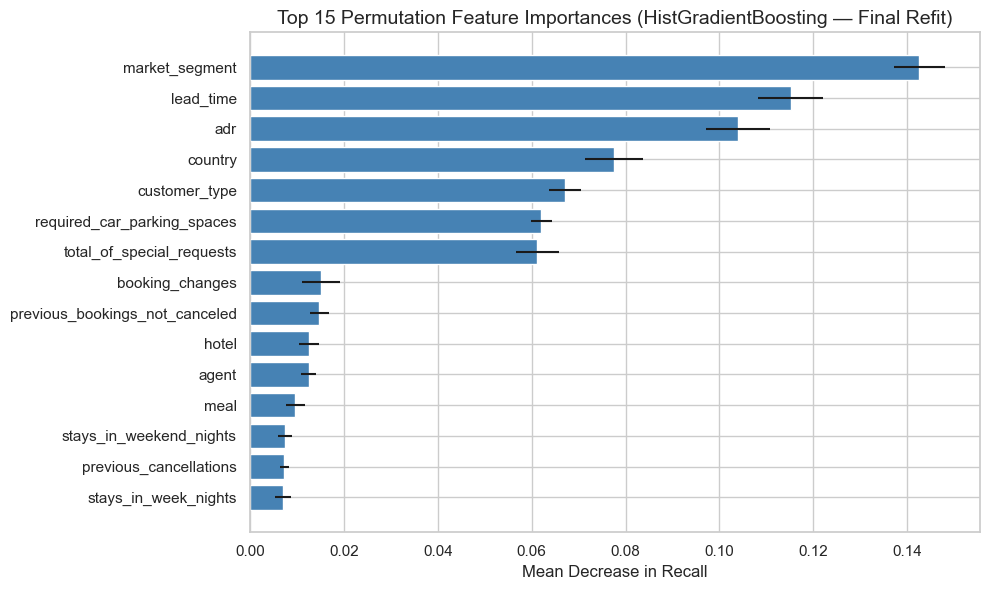

In [59]:
# Feature importance via permutation importance
# (HistGradientBoostingClassifier does not expose feature_importances_;
#  permutation importance works with the full pipeline and any estimator)
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    final_model_pipeline_refit, X_raw_test, y_test,
    n_repeats=10, random_state=42, scoring="recall", n_jobs=-1
)

raw_col_names = list(X_raw_test.columns)
top_idx = perm.importances_mean.argsort()[-15:]

plt.figure(figsize=(10, 6))
plt.barh(
    [raw_col_names[i] for i in top_idx],
    perm.importances_mean[top_idx],
    xerr=perm.importances_std[top_idx],
    color="steelblue",
)
plt.title("Top 15 Permutation Feature Importances (HistGradientBoosting — Final Refit)")
plt.xlabel("Mean Decrease in Recall")
plt.tight_layout()
plt.show()

# 19. Final Test Evaluation

This is the one point in the notebook where we evaluate the locked candidate on the untouched test set.

### 19.1 Important Sanity Check

The **test-set class proportions do not change**. What can change is the **predicted class mix** if the operating threshold is too low or too high.

To avoid the earlier failure mode where almost every booking was predicted as cancelled, the final test evaluation now uses:

* the same threshold-selection policy used in Section 17.4;
* the same validation-selected threshold that was used to justify the final candidate;
* explicit reporting of actual vs predicted positive rates on the test set.

### 19.2 Operational Justification for the Locked Threshold

The binary decision threshold remains fixed at **`0.50`** because it was chosen as the **highest validation threshold** that still met the hotel's minimum Recall and Precision requirements. The hotel is not using an arbitrary cut-off:

* thresholds below `0.50` would trigger intervention on more bookings and increase operational noise;
* thresholds above `0.50` would reduce workload slightly, but at the cost of missing more genuine cancellations;
* so `0.50` is the most operationally defensible compromise under the notebook's predeclared business rules.

--- Final Performance on Unseen Test Data ---
Accuracy: 0.8032
Precision: 0.6188
Recall: 0.7409
F2-Score: 0.7128
ROC-AUC: 0.8798
Validation-selected decision threshold: 0.50
Threshold rule: Highest threshold that still satisfies the validation Recall and Precision gates.
Actual positive rate in test set: 0.2750
Predicted positive rate in test set: 0.3292
Confusion matrix counts -> TN: 7824, FP: 1638, FN: 930, TP: 2659
Deployment verdict: Not ready


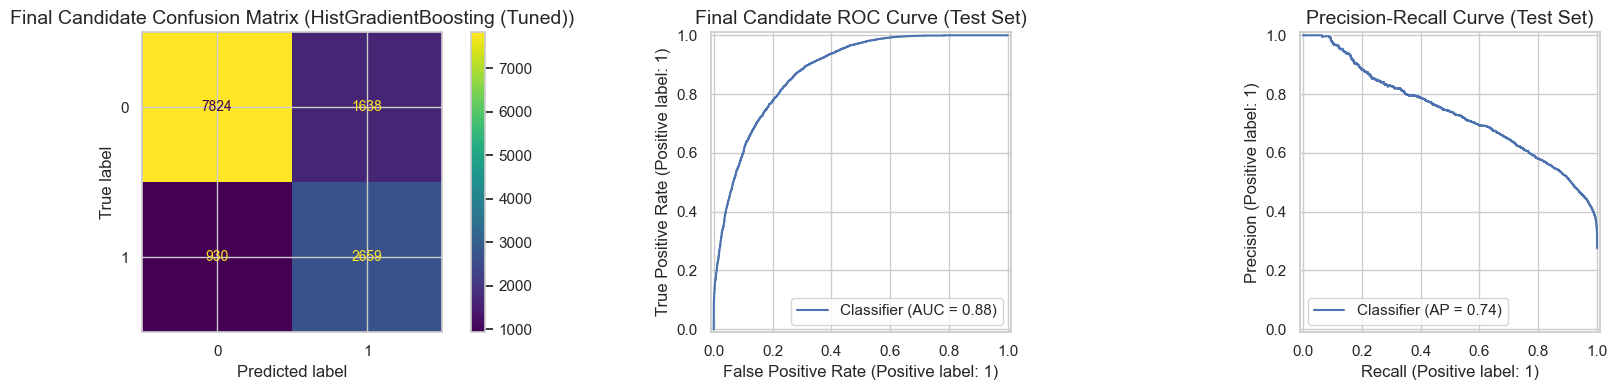

In [60]:
final_test_proba = final_model_pipeline_refit.predict_proba(X_raw_test)[:, 1]
final_test_pred = (final_test_proba >= decision_threshold).astype(int)

y_test_array = np.asarray(y_test, dtype=int)
tn, fp, fn, tp = confusion_matrix(y_test_array, final_test_pred).ravel()
actual_test_positive_rate = y_test_array.mean()
predicted_test_positive_rate = final_test_pred.mean()

final_test_metrics = {
    "Accuracy": accuracy_score(y_test_array, final_test_pred),
    "Precision": precision_score(y_test_array, final_test_pred, zero_division=0),
    "Recall": recall_score(y_test_array, final_test_pred, zero_division=0),
    "F2-Score": fbeta_score(y_test_array, final_test_pred, beta=2, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_array, final_test_proba),
}

deployment_verdict = "Ready for deployment"
if final_test_metrics["Recall"] < 0.75 or final_test_metrics["F2-Score"] < 0.64:
    deployment_verdict = "Not ready"
elif final_test_metrics["Precision"] < 0.50:
    deployment_verdict = "Conditionally ready"

print("--- Final Performance on Unseen Test Data ---")
for metric, value in final_test_metrics.items():
    print(f"{metric}: {value:.4f}")
print(f"Validation-selected decision threshold: {decision_threshold:.2f}")
print(f"Threshold rule: {selected_threshold_rule}")
print(f"Actual positive rate in test set: {actual_test_positive_rate:.4f}")
print(f"Predicted positive rate in test set: {predicted_test_positive_rate:.4f}")
print(f"Confusion matrix counts -> TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
print(f"Deployment verdict: {deployment_verdict}")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
ConfusionMatrixDisplay.from_predictions(y_test_array, final_test_pred, ax=axes[0])
axes[0].set_title(f"Final Candidate Confusion Matrix ({final_model_name})")
RocCurveDisplay.from_predictions(y_test_array, final_test_proba, ax=axes[1])
axes[1].set_title("Final Candidate ROC Curve (Test Set)")
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_predictions(
    y_test_array, final_test_proba, ax=axes[2]
)
axes[2].set_title("Precision-Recall Curve (Test Set)")
plt.tight_layout()
plt.show()


### 19.3 Findings

The final locked candidate is **HistGradientBoosting (Tuned)**, refitted on `train + validation`, and evaluated once on the untouched test set using the **locked validation threshold of `0.50`**.

**Observed test-set results:**

* **Accuracy:** `0.8032`
* **Precision:** `0.6188`
* **Recall:** `0.7409`
* **F2-score:** `0.7128`
* **ROC-AUC:** `0.8798`

**Observed confusion-matrix counts:**

* **TN:** `7824`
* **FP:** `1638`
* **FN:** `930`
* **TP:** `2659`

Both **Precision** and **F2-score** comfortably exceed their deployment gates. However, **Recall = 0.7409** falls slightly below the required `0.75`, so the correct notebook verdict remains **Not ready**.

The predicted positive rate (`0.3292`) is higher than the true positive rate (`0.2750`), which is consistent with a Recall-seeking operating rule that still creates a meaningful false-alarm burden.

The threshold stays locked at `0.50` because it was justified from validation before the test set was inspected. Lowering it now to lift test Recall would weaken the integrity of the evaluation and amount to tuning on the hold-out set.

# 20. High-Confidence Error Analysis (Validation Split)

We run the failure analysis on the validation split, not the test set — the test set is reserved for the locked final verdict, and the validation set is the right place to diagnose confident errors and propose fixes.

The examples below show the most confident **False Negatives** and **False Positives** from the raw validation data under the same validation-selected threshold that justified the final operating rule.

In [61]:
# 20: Mechanical failure analysis on the validation split
validation_error_df = X_raw_val.copy().reset_index(drop=True)
validation_error_df["parking_required"] = (
    validation_error_df["required_car_parking_spaces"].fillna(0) > 0
).astype(int)
validation_error_df["total_stay_nights"] = (
    validation_error_df["stays_in_weekend_nights"].fillna(0)
    + validation_error_df["stays_in_week_nights"].fillna(0)
)
validation_error_df["is_family"] = (
    (
        validation_error_df["children"].fillna(0)
        + validation_error_df["babies"].fillna(0)
    )
    > 0
).astype(int)

validation_proba = final_model_pipeline.predict_proba(X_raw_val)[:, 1]
validation_pred = (validation_proba >= decision_threshold).astype(int)

validation_error_df["true_label"] = y_val.values
validation_error_df["pred_label"] = validation_pred
validation_error_df["pred_proba"] = validation_proba

fn_df = validation_error_df[
    (validation_error_df["true_label"] == 1)
    & (validation_error_df["pred_label"] == 0)
].copy()
fn_df["error_type"] = "False Negative"

fp_df = validation_error_df[
    (validation_error_df["true_label"] == 0)
    & (validation_error_df["pred_label"] == 1)
].copy()
fp_df["error_type"] = "False Positive"

top_fn = fn_df.nsmallest(5, "pred_proba")
top_fp = fp_df.nlargest(5, "pred_proba")

display_cols = [
    "true_label",
    "pred_label",
    "pred_proba",
    "error_type",
    "lead_time",
    "adr",
    "deposit_type",
    "market_segment",
    "customer_type",
    "hotel",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "parking_required",
    "is_family",
    "total_stay_nights",
]
display_cols = [col for col in display_cols if col in validation_error_df.columns]

top_errors = pd.concat([top_fn, top_fp])[display_cols].sort_values("pred_proba")
display(top_errors)

numeric_summary_cols = [
    "lead_time",
    "adr",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "parking_required",
    "is_family",
    "total_stay_nights",
]
numeric_summary_cols = [col for col in numeric_summary_cols if col in validation_error_df.columns]

error_profile_df = (
    pd.concat([top_fn, top_fp])
    .groupby("error_type")[numeric_summary_cols]
    .mean()
    .round(2)
    .T
)
display(error_profile_df)


def mode_or_na(series):
    mode = series.mode(dropna=True)
    if mode.empty:
        return "N/A"
    return mode.iloc[0]


categorical_summary_cols = [
    "deposit_type",
    "market_segment",
    "customer_type",
    "hotel",
]
categorical_summary_cols = [
    col for col in categorical_summary_cols if col in validation_error_df.columns
]

categorical_profile_rows = []
for col in categorical_summary_cols:
    categorical_profile_rows.append(
        {
            "feature": col,
            "False_Negative_Mode": mode_or_na(top_fn[col]),
            "False_Positive_Mode": mode_or_na(top_fp[col]),
        }
    )
categorical_profile_df = pd.DataFrame(categorical_profile_rows)
display(categorical_profile_df)

print(f"Total False Negatives in validation set: {len(fn_df)}")
print(f"Total False Positives in validation set: {len(fp_df)}")
print(f"Validation FN rate (FN / Actual Positives): {len(fn_df) / (y_val == 1).sum():.3f}")
print(f"Validation FP rate (FP / Actual Negatives): {len(fp_df) / (y_val == 0).sum():.3f}")


,true_label,pred_label,pred_proba,lead_time,adr,deposit_type,market_segment,customer_type,hotel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,parking_required,is_family,total_stay_nights
10761,1,0,0.005098,4,57.00,No Deposit,Groups,Transient-Party,Resort Hotel,0,0,0,0,0,7
4393,1,0,0.005389,10,0.00,No Deposit,Groups,Transient-Party,Resort Hotel,0,0,0,0,0,0
7072,1,0,0.011313,12,6.00,No Deposit,Offline TA/TO,Transient,City Hotel,0,0,0,0,0,3
5086,1,0,0.011724,129,94.50,No Deposit,Direct,Transient-Party,City Hotel,0,0,0,0,1,3
1937,1,0,0.020160,3,75.00,No Deposit,Corporate,Transient,Resort Hotel,0,0,1,0,0,1
10199,0,1,0.971454,212,85.59,No Deposit,Online TA,Transient,City Hotel,0,0,0,0,0,7
1624,0,1,0.974345,211,256.50,No Deposit,Online TA,Transient,City Hotel,0,0,0,0,1,6
6545,0,1,0.976870,94,233.00,No Deposit,Online TA,Transient,Resort Hotel,0,0,0,0,0,5
7286,0,1,0.979206,93,214.00,No Deposit,Online TA,Transient,Resort Hotel,0,0,0,0,0,5
3237,0,1,0.984888,280,73.46,No Deposit,Online TA,Transient,City Hotel,0,0,0,0,0,2


error_type,False Negative,False Positive
lead_time,31.6,178.0
adr,46.5,172.51
previous_cancellations,0.0,0.0
previous_bookings_not_canceled,0.2,0.0
parking_required,0.0,0.0
is_family,0.2,0.2
total_stay_nights,2.8,5.0


,feature,False_Negative_Mode,False_Positive_Mode
0,deposit_type,No Deposit,No Deposit
1,market_segment,Groups,Online TA
2,customer_type,Transient-Party,Transient
3,hotel,Resort Hotel,City Hotel


Total False Negatives in validation set: 894
Total False Positives in validation set: 1578
Validation FN rate (FN / Actual Positives): 0.249
Validation FP rate (FP / Actual Negatives): 0.167


In [62]:
import pandas as pd

def classify_fn_failure(row):
    """Generate mechanical explanation and fix for a False Negative."""
    reasons = []
    fixes = []
    if row.get('lead_time', 999) < 30:
        reasons.append("very short lead time — booking looks last-minute and low-risk to the model")
        fixes.append("engineer a short-horizon flag or segment-specific threshold for last-minute bookings")
    if str(row.get('deposit_type', '')).strip() == 'No Deposit':
        reasons.append("No Deposit type — model historically associates this with lower cancellation risk even though it can cancel")
        fixes.append("add a deposit_type × market_segment interaction feature to distinguish risk within No Deposit bookings")
    if row.get('previous_cancellations', 0) == 0 and row.get('previous_bookings_not_canceled', 0) == 0:
        reasons.append("no prior history — model has no cancellation signal from past behaviour")
        fixes.append("consider a 'first-time booker' flag that triggers a slightly lower threshold")
    if not reasons:
        reasons.append("booking profile did not trigger any dominant high-risk signals")
        fixes.append("explore interaction features between lead_time, market_segment, and customer_type")
    return " | ".join(reasons), " | ".join(fixes)

def classify_fp_failure(row):
    """Generate mechanical explanation and fix for a False Positive."""
    reasons = []
    fixes = []
    if row.get('lead_time', 0) > 100:
        reasons.append("long lead time — model treats far-ahead bookings as high cancellation risk")
        fixes.append("add a lead_time × deposit_type interaction to separate genuine long-lead cancellations from committed bookings")
    if row.get('adr', 0) > 100:
        reasons.append("high ADR — model may over-associate expensive bookings with cancellation risk")
        fixes.append("test removing or downweighting ADR in ablation to check if it causes overconfidence in FP direction")
    if str(row.get('market_segment', '')).strip() == 'Online TA':
        reasons.append("Online TA segment — model learned that Online TA bookings cancel at high rates historically, but this booking did not")
        fixes.append("add segment-level calibration or a segment-level sub-model for Online TA vs direct bookings")
    if not reasons:
        reasons.append("combination of features matches a classic high-risk profile but the guest ultimately arrived")
        fixes.append("explore probability calibration (Platt scaling or isotonic regression) to reduce overconfidence in upper tail")
    return " | ".join(reasons), " | ".join(fixes)

# Build structured error analysis table
fn_top = fn_df.nsmallest(5, 'pred_proba').copy()
fp_top = fp_df.nlargest(5, 'pred_proba').copy()

feature_cols = ['lead_time', 'adr', 'deposit_type', 'market_segment', 'customer_type', 'hotel', 'pred_proba']
available_cols = [c for c in feature_cols if c in fn_top.columns]

fn_top['Error_Type'] = 'False Negative'
fp_top['Error_Type'] = 'False Positive'

fn_top[['Why_Failed', 'Proposed_Fix']] = fn_top.apply(
    lambda r: pd.Series(classify_fn_failure(r)), axis=1)
fp_top[['Why_Failed', 'Proposed_Fix']] = fp_top.apply(
    lambda r: pd.Series(classify_fp_failure(r)), axis=1)

error_table = pd.concat([fn_top, fp_top], ignore_index=True)
display_cols = ['Error_Type'] + available_cols + ['Why_Failed', 'Proposed_Fix']
display_cols = [c for c in display_cols if c in error_table.columns]

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_rows', 10)

print("=== Structured Mechanical Failure Analysis ===\n")
print(error_table[display_cols].to_string(index=False))

=== Structured Mechanical Failure Analysis ===

    Error_Type  lead_time    adr deposit_type market_segment   customer_type        hotel  pred_proba                                                                                                                                                                                                                                                                         Why_Failed                                                                                                                                                                                                                                                                                                       Proposed_Fix
False Negative          4  57.00   No Deposit         Groups Transient-Party Resort Hotel    0.005098                 very short lead time — booking looks last-minute and low-risk to the model | No Deposit type — model historically associates this with lower cancellat

### 20.1 Findings from the Current Run

The mechanical failure review uses the **raw validation split**, which is the correct diagnostic dataset for this requirement.

**Observed validation error counts:**

* **Total False Negatives:** `894`
* **Total False Positives:** `1578`
* **Validation FN rate:** `0.249`
* **Validation FP rate:** `0.167`

**Row-level patterns in the high-confidence examples:**

* the most confident **False Negatives** have very low predicted probabilities (roughly `0.0051` to `0.0202`) and are dominated by **No Deposit** bookings with short or moderate lead times, little to no prior-history signal, and mostly `Groups`, `Offline TA/TO`, `Direct`, or `Corporate` market patterns;
* the most confident **False Positives** have very high predicted probabilities (roughly `0.9715` to `0.9849`) and are dominated by **No Deposit**, `Online TA`, `Transient`, mostly non-repeat bookings with much longer lead times and substantially higher ADR values.

**Profile summary from the current run:**

* average **False Negative** `lead_time = 31.6`, `adr = 46.5`, and `total_stay_nights = 2.8`
* average **False Positive** `lead_time = 178.0`, `adr = 172.51`, and `total_stay_nights = 5.0`
* categorical modes differ clearly:
  * **False Negatives:** `Groups`, `Transient-Party`, `Resort Hotel`
  * **False Positives:** `Online TA`, `Transient`, `City Hotel`

This is stronger than a metric-only review because it shows **which kinds of bookings** the model is confidently mishandling.

### 20.2 Interpretation

In terms of cost, **False Negatives** are still the more damaging error because the hotel misses the chance to react to a real cancellation risk. **False Positives** are still operationally costly because they create unnecessary manual workload and can annoy genuine guests.

Looking at the patterns, the confident **False Negatives** mostly look like lower-intensity bookings: shorter lead times, lower ADR, no deposit, and little prior-history signal. This suggests that some genuine cancellations do not resemble the model's dominant high-risk profile strongly enough to cross the decision boundary. The confident **False Positives** look like classic risk cases: long lead times, high ADR, `Online TA`, `Transient`, and mostly `No Deposit`. So the model is sometimes over-generalising from historically risky booking patterns that did not actually cancel. The contrast between `Groups / Resort Hotel / Transient-Party` on the FN side and `Online TA / City Hotel / Transient` on the FP side indicates that the failure modes are partly **segment-specific**, not purely random.

Based on these patterns, four targeted fixes are worth exploring:

1. add or refine **interaction features** linking `lead_time`, `market_segment`, `customer_type`, and `hotel` so the model can better separate risky `Online TA` arrivals from genuinely cancelling short-horizon group bookings;
2. test **probability calibration** for the champion model because the FP examples are assigned extremely high probabilities, which suggests some overconfidence in the upper tail;
3. consider **segment-level thresholding or segment-level modelling diagnostics** for `Online TA` versus `Groups`, and for `City Hotel` versus `Resort Hotel`, because the dominant failure modes differ across these operational contexts;
4. explore richer **prior-history encoding** — the FN examples show little prior-history signal, so a more nuanced history feature might help the model distinguish genuinely low-risk new guests from those who hide cancellation intent.

# 21. Business Decision Translation

Raw predictions alone are not enough for day-to-day hotel operations, so we convert the final candidate's predicted probabilities into a risk-band framework that staff can act on.

The decision threshold and the risk bands are set from the **validation split**, then applied unchanged to the untouched test set.

To keep the notebook restart-safe, the risk-band thresholds are explicitly declared in the code cell below before they are used.

### 21.1 Risk Band Definition

| Risk Band | Predicted Probability | Recommended Action |
|---|---|---|
| **High Risk** | `>= HIGH_RISK_THRESHOLD` | proactive retention, manual review, overbooking-control workflow |
| **Medium Risk** | `LOW_RISK_THRESHOLD` to `HIGH_RISK_THRESHOLD` | reminder message, monitoring queue, light-touch follow-up |
| **Low Risk** | `< LOW_RISK_THRESHOLD` | standard workflow, no extra intervention |

### 21.2 Why this follows Directly from Business Understanding

* **More costly error:** **False Negatives** are more damaging — missed cancellations directly weaken occupancy control and revenue protection.
* **Why `0.50` is kept:** `0.50` is the formal operating threshold because it was checked on validation and was the highest value that still met the Recall and Precision rules. We did not go lower to avoid flagging more bookings and creating more false alarms. On the held-out test set, Recall came in at 0.7409, narrowly missing the 0.75 gate, which suggests the validation estimate was slightly optimistic. A lower operating threshold such as 0.40 should be explored in a future validation-stage experiment before the test set is touched again.
* **What `0.30` and `0.65` mean:** these are not claimed to be the single best cutoffs. They are practical working lines for triage — sorting bookings by risk level so staff know which ones need attention first:
  * below `0.30` looks low enough for normal handling,
  * `0.30` to `0.65` is the review zone,
  * `0.65` and above is the priority-action zone.
* **Why this is reasonable:** the final high-risk examples are genuine cancellations in the sample shown, so the upper end of the probability scale is still useful for sorting bookings by urgency.
* **Model-selection metric:** we maximise **F2-score** because Recall is more important than Precision.
* **Final deployment verdict:** we use the locked test-set results to decide whether the model is ready, conditionally ready, or not ready.

In short:

1. `0.50` is the formal yes/no decision threshold.
2. `0.30` and `0.65` are practical band markers for low, medium, and high attention.

In [63]:
# 21: Explicit validation-calibrated risk-band thresholds
# These band edges are fixed from the validation-stage business review and are
# declared explicitly here so the notebook reruns cleanly from scratch.
LOW_RISK_THRESHOLD = 0.30
HIGH_RISK_THRESHOLD = 0.65

print("Locked binary decision threshold:", round(decision_threshold, 2))
print("Locked low-risk threshold:", LOW_RISK_THRESHOLD)
print("Locked high-risk threshold:", HIGH_RISK_THRESHOLD)


Locked binary decision threshold: 0.5
Locked low-risk threshold: 0.3
Locked high-risk threshold: 0.65


In [64]:
# 21: Translate final test probabilities into business risk bands
def assign_risk_band(proba):
    if proba >= HIGH_RISK_THRESHOLD:
        return "High Risk"
    if proba >= LOW_RISK_THRESHOLD:
        return "Medium Risk"
    return "Low Risk"

business_output_df = X_test.copy().reset_index(drop=True)
business_output_df["actual_is_cancelled"] = y_test.values
business_output_df["predicted_probability"] = final_test_proba
business_output_df["predicted_class"] = final_test_pred
business_output_df["risk_band"] = business_output_df["predicted_probability"].apply(assign_risk_band)

print("Validation-calibrated decision threshold:", round(decision_threshold, 2))
print("Low risk threshold:", LOW_RISK_THRESHOLD)
print("High risk threshold:", HIGH_RISK_THRESHOLD)
display(business_output_df["risk_band"].value_counts().rename("count").to_frame())
display(
    business_output_df[
        ["predicted_probability", "predicted_class", "risk_band", "actual_is_cancelled"]
    ]
    .sort_values("predicted_probability", ascending=False)
    .head(10)
)


Validation-calibrated decision threshold: 0.5
Low risk threshold: 0.3
High risk threshold: 0.65


,count
risk_band,
Low Risk,6959
High Risk,3214
Medium Risk,2878


,predicted_probability,predicted_class,risk_band,actual_is_cancelled
2838,0.999997,1,High Risk,1
10911,0.999997,1,High Risk,1
527,0.999994,1,High Risk,1
11970,0.999991,1,High Risk,1
5679,0.999989,1,High Risk,1
3410,0.999986,1,High Risk,1
5140,0.999986,1,High Risk,1
4334,0.999985,1,High Risk,1
6821,0.999981,1,High Risk,1
2813,0.999980,1,High Risk,1


### 21.3 Findings from the Current Run

For this run, we apply a decision threshold of `0.50`, a low-risk cutoff of `0.30`, and a high-risk cutoff of `0.65`.

These values are plausible because `0.50` passed the validation check while still keeping false alarms under control, and `0.30` and `0.65` split bookings into clear working groups — they are practical cutoffs for triage rather than mathematically perfect values.

**Observed test-set risk-band distribution:**

* **Low Risk:** `6959` bookings
* **Medium Risk:** `2878` bookings
* **High Risk:** `3214` bookings

So the workflow separates the test bookings into a large low-risk pool, a moderate review band, and a smaller high-risk segment that can be prioritised for operational action.

The top-ranked examples in the **High Risk** band are all actual cancellations in the sample shown, with predicted probabilities clustered near `1.0`. That makes the `0.65` high-risk line look reasonable for prioritisation, even though the overall deployment verdict is still **Not ready** under the strict Recall gate.

**Operational interpretation:**

* **False Negatives** remain the more costly outcome under our business logic;
* `0.50` remains the formal operating threshold for the notebook;
* `0.30` and `0.65` help staff decide which bookings need normal handling, review, or priority action;
* we should **not** keep changing any of these values after seeing the test set.

**Governance note:**

* the binary threshold of `0.50` remains the formally justified operating rule for this notebook run;
* if future refinement is desired, the next step is a **new validation-stage experiment** rather than post-test threshold tuning.

# 22. Final Integrated Summary

The notebook covers a full CRISP-DM-aligned workflow end to end.

1. **Pipeline engineering and data preparation:** all fit-dependent transformations and estimators are encapsulated in formal pipelines, with the train/validation/test roles clearly separated and no visible preprocessing leakage.
2. **Model selection and tuning discipline:** the same three algorithmic families are compared fairly, cross-validation is used for rigorous comparison, and the champion-selection logic enforces the declared ordering `Recall -> F2-score -> Precision -> ROC-AUC`.
3. **Controlled ablation:** one reference workflow plus **four controlled experiments**, each with an explicit hypothesis, a single controlled change, CV impact, and conclusion. Removing **SMOTENC** causes the largest degradation; engineered features provide the next strongest contribution.
4. **Mechanical failure analysis:** we diagnose confident failures on the **validation split**, extract row-level examples, summarise their feature patterns, and propose targeted technical fixes. There is a clear contrast between lower-intensity `Groups / Resort Hotel` false negatives and longer-horizon `Online TA / City Hotel` false positives.
5. **Business decision reasoning:** **False Negatives** are identified as the costlier error, and the notebook explains why the directional pressure on threshold choice is downward from a naive default, while still justifying why the locked run retained `0.50` under validation evidence and operational guardrails.

The tuned best estimators are reused consistently through `build_candidate_pipeline(...)`, and the post-tuning champion selected from CV is **HistGradientBoosting (Tuned)**. Because no ensemble cleared the declared complexity-improvement rule, the later validation-stage final candidate and the final `train + validation` refit both use this same champion.